In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm

# =============================================================================
# 1. LECTURE ET FUSION DES FICHIERS CSV
# =============================================================================
input_dir = './outputs/pseudo-earl/'

search_pattern = os.path.join(input_dir, "**", "*radiomics.csv")
csv_files = glob.glob(search_pattern, recursive=True)

assert csv_files, "Aucun fichier CSV de radiomiques trouvé dans le répertoire spécifié."
    
print(f"📄 {len(csv_files)} fichiers trouvés. Début de la lecture...")

df_list = []
for file_path in tqdm(csv_files, desc="Lecture des CSV"):
    df = pd.read_csv(file_path)
    
    if df.empty: 
        continue
    
    # --- INJECTION DE LA COLONNE COMPONENT SI MANQUANTE ---
    if 'Component' not in df.columns:
        # On l'insère juste après 'VOI' si elle existe, sinon à l'index 2 par défaut
        idx = df.columns.get_loc('VOI') + 1 if 'VOI' in df.columns else 2
        df.insert(idx, 'Component', np.nan)
    
    parts = os.path.normpath(file_path).split(os.sep)
    
    # On vérifie qu'on a assez de profondeur
    if len(parts) >= 4:
        domain = parts[-4]
        
        # Déduction de la Source et de la Target selon le nom du domaine
        if "_to_" in domain:
            domain_source, domain_target = domain.split("_to_", 1)
        else:
            domain_source = domain
            domain_target = ""
            
        # Insertion des métadonnées contextuelles au début du DataFrame
        df.insert(0, 'Domain_Target', domain_target)
        df.insert(0, 'Domain_Source', domain_source)
        df.insert(0, 'Domain', domain)
    else:
        df.insert(0, 'Source_Path', os.path.dirname(file_path))
    
    df_list.append(df)
        
assert df_list, "Aucun DataFrame valide n'a été créé à partir des fichiers CSV"

print("🔗 Concaténation des DataFrames...")
master_df = pd.concat(df_list, ignore_index=True)

print(f"-> Taille avant filtrage : {len(master_df)} lignes.")


# =============================================================================
# 2. NETTOYAGE ET FILTRAGE STRICT (Matching GT / Prédiction)
# =============================================================================
print("🧹 Filtrage des patients sans prédiction Pseudo-EARL correspondante...")

dom_col = master_df['Domain'].astype(str).str.lower()
mod_col = master_df['Modality'].astype(str).str.lower()

# Identification des patients ayant des prédictions générées
ids_pseudo1 = master_df[mod_col == 'pseudo-earl1']['Subject_ID'].unique()
ids_pseudo2 = master_df[mod_col == 'pseudo-earl2']['Subject_ID'].unique()

# Masques de filtrage selon les règles des domaines
mask_rennes_chb = dom_col.isin(['rennes', 'chb', 'domain_rennes', 'domain_chb']) & master_df['Subject_ID'].isin(ids_pseudo1)
mask_nantes = dom_col.isin(['nantes', 'domain_nantes']) & master_df['Subject_ID'].isin(ids_pseudo2)

is_a100 = dom_col.isin(['a100', 'domain_a100'])
mask_a100_std1 = is_a100 & mod_col.isin(['earl1', 'gaussian-earl1', 'pseudo-earl1']) & master_df['Subject_ID'].isin(ids_pseudo1)
mask_a100_std2 = is_a100 & mod_col.isin(['earl2', 'gaussian-earl2', 'pseudo-earl2']) & master_df['Subject_ID'].isin(ids_pseudo2)
mask_a100_standard = is_a100 & (mod_col == 'standard') & (master_df['Subject_ID'].isin(ids_pseudo1) | master_df['Subject_ID'].isin(ids_pseudo2))

# Application du filtrage combiné
master_df = master_df[mask_rennes_chb | mask_nantes | mask_a100_std1 | mask_a100_std2 | mask_a100_standard].copy()

# Reset index propre
master_df.reset_index(drop=True, inplace=True)


# =============================================================================
# 3. SAUVEGARDE ET RÉSUMÉ
# =============================================================================
output_csv_path = os.path.join('master_radiomics_filtered.csv')
master_df.to_csv(output_csv_path, index=False)

print("\n" + "="*55)
print("✅ FUSION ET FILTRAGE TERMINÉS AVEC SUCCÈS")
print("="*55)
print(f"Total des lignes restantes : {len(master_df)}")
print(f"Total des colonnes       : {len(master_df.columns)}")
print("="*55)

master_df

📄 1796 fichiers trouvés. Début de la lecture...


Lecture des CSV: 100%|██████████| 1796/1796 [00:05<00:00, 344.68it/s]


🔗 Concaténation des DataFrames...
-> Taille avant filtrage : 7992 lignes.
🧹 Filtrage des patients sans prédiction Pseudo-EARL correspondante...

✅ FUSION ET FILTRAGE TERMINÉS AVEC SUCCÈS
Total des lignes restantes : 7815
Total des colonnes       : 102


,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,a100,a100,,A100560539,brain,NaN,earl2,earl2.nii.gz,Sphere_20.0mm,1.581399,...,5.297199,0.053913,0.177751,70.895755,0.001913,0.458346,0.009841,453.143385,0.116670,6.632284
1,a100,a100,,A100560539,brain,NaN,gaussian-earl1,gaussian-earl1.nii.gz,Sphere_20.0mm,2.219535,...,3.862306,0.032782,0.091040,22.977546,0.001089,0.571064,0.013646,192.641084,0.052496,6.612473
2,a100,a100,,A100560539,brain,NaN,gaussian-earl2,gaussian-earl2.nii.gz,Sphere_20.0mm,1.640838,...,5.037893,0.041658,0.166649,61.885455,0.001654,0.440051,0.010722,381.373314,0.102323,6.866131
3,a100,a100,,A100560539,brain,NaN,earl1,earl1.nii.gz,Sphere_20.0mm,1.791329,...,9.872376,0.064066,0.135961,41.090057,0.001760,0.537439,0.012735,255.454258,0.082767,6.877206
4,a100,a100,,A100560539,brain,NaN,standard,pet.nii.gz,Sphere_20.0mm,1.533380,...,8.848656,0.063475,0.179631,74.809824,0.001902,0.398932,0.009621,531.890987,0.114563,7.597881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7810,rennes,rennes,,Zp6n3YLNQfdVr8s4qPvs5D,spleen,NaN,pseudo-earl1,pseudo-earl1.nii.gz,Original,1.126299,...,3.425341,0.031012,0.022227,1.467440,0.000887,6.678380,0.001164,42.128796,0.026602,0.102494
7811,rennes,rennes,,Zp6n3YLNQfdVr8s4qPvs5D,urinary_bladder,NaN,gaussian-earl1,gaussian-earl1.nii.gz,Original,3.363587,...,1.061240,0.009755,0.022516,2.197373,0.000549,3.638074,0.001078,54.464684,0.016893,0.150684
7812,rennes,rennes,,Zp6n3YLNQfdVr8s4qPvs5D,urinary_bladder,NaN,earl1,earl1.nii.gz,Original,3.315136,...,0.349087,0.006725,0.047728,8.707494,0.000476,3.159916,0.000764,161.279336,0.021691,0.184674
7813,rennes,rennes,,Zp6n3YLNQfdVr8s4qPvs5D,urinary_bladder,NaN,standard,pet.nii.gz,Original,3.256343,...,0.197696,0.005774,0.084507,20.973452,0.000591,3.008568,0.000635,305.523491,0.030120,0.201234


: 

In [100]:
# load
import pandas as pd
import numpy as np

def compute_cov_metrics(df):
    df_out = df.copy()
    eps = 1e-8
    
    # 1. Calcul du COV (Écart-type / |Moyenne|)
    std_dev = np.sqrt(df_out['original_firstorder_Variance'].clip(lower=0))
    df_out['COV'] = std_dev / (df_out['original_firstorder_Mean'].abs() + eps)
    
    # 2. Calcul du Robust COV ( (IQR / 1.349) / |Médiane| )
    robust_std = df_out['original_firstorder_InterquartileRange'] / 1.349
    df_out['RobustCOV'] = robust_std / (df_out['original_firstorder_Median'].abs() + eps)
    
    return df_out

master_df = pd.read_csv('master_radiomics_filtered.csv')
# master_df = compute_cov_metrics(master_df)
master_df

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,nantes,nantes,NaN,15080000,spleen,NaN,earl2,earl2.nii.gz,Original,1.372068,...,11.969992,0.044853,0.009562,0.251885,0.000763,32.632969,0.000363,16.882386,0.004629,0.026981
1,nantes,nantes,NaN,15080000,spleen,NaN,gaussian-earl2,gaussian-earl2.nii.gz,Original,1.368678,...,10.961436,0.045164,0.010320,0.276046,0.000827,33.553235,0.000356,17.778666,0.005163,0.025550
2,nantes,nantes,NaN,15080000,spleen,NaN,pet,pet.nii.gz,Original,1.333326,...,7.311743,0.047045,0.016302,0.481772,0.001227,33.411213,0.000335,27.895862,0.007276,0.027515
3,nantes,nantes,NaN,15080000,spleen,NaN,pseudo-earl2,pseudo-earl2.nii.gz,Original,1.371308,...,11.910279,0.044909,0.009604,0.248926,0.000802,32.753831,0.000362,16.963075,0.004646,0.026868
4,nantes,nantes,NaN,15080000,brain,NaN,earl2,earl2.nii.gz,Sphere_20.0mm,3.058370,...,2.065838,0.032133,0.256412,172.043503,0.002071,0.185523,0.007615,1525.310888,0.172210,9.819384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12544,chb,chb,NaN,9401170709m,lesion,10.0,pseudo-earl1,pseudo-earl1.nii.gz,Component,3.762264,...,1.405389,0.209472,0.148611,1.302778,0.042594,0.365634,0.279079,7.242121,0.136043,1.992989
12545,chb,chb,NaN,9401170709m,liver,NaN,gaussian-earl1,gaussian-earl1.nii.gz,Sphere_20.0mm,2.306157,...,11.870263,0.075559,0.013472,0.325546,0.001093,5.183352,0.003787,15.056461,0.013944,0.158732
12546,chb,chb,NaN,9401170709m,liver,NaN,earl1,earl1.nii.gz,Sphere_20.0mm,2.303875,...,10.564589,0.078925,0.014816,0.353488,0.001318,5.731140,0.003460,16.865573,0.016666,0.139914
12547,chb,chb,NaN,9401170709m,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.268348,...,5.872264,0.045352,0.017495,0.654120,0.000881,3.330373,0.003810,24.460774,0.012947,0.232929


In [92]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import logging
import warnings

from skimage.metrics import structural_similarity as ssim
from scipy.stats import wilcoxon, spearmanr
from scipy.ndimage import distance_transform_edt

# Désactiver les warnings
sitk.ProcessObject.SetGlobalWarningDisplay(False)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def generate_centered_sphere(sitk_mask, radius_mm=20.0, use_barycenter=False, margin_mm=1.0, shift_mm=(0.0, 0.0, 0.0)):
    spacing = sitk_mask.GetSpacing() 
    size = sitk_mask.GetSize()
    
    stats = sitk.LabelShapeStatisticsImageFilter()
    sitk_mask_uint8 = sitk.Cast(sitk_mask, sitk.sitkUInt8)
    stats.Execute(sitk_mask_uint8)
    
    if not stats.HasLabel(1):
        return None, "Masque vide"
        
    if use_barycenter:
        c_phys = list(stats.GetCentroid(1))
    else:
        mask_arr = sitk.GetArrayFromImage(sitk_mask_uint8)
        edt_map = distance_transform_edt(mask_arr, sampling=spacing[ ::-1 ])
        max_idx_flat = edt_map.argmax()
        cz, cy, cx = np.unravel_index(max_idx_flat, mask_arr.shape)
        c_phys = list(sitk_mask.TransformIndexToPhysicalPoint((int(cx), int(cy), int(cz))))

    c_phys[ 0 ] += shift_mm[ 0 ]
    c_phys[ 1 ] += shift_mm[ 1 ]
    c_phys[ 2 ] += shift_mm[ 2 ]
    
    c_idx = sitk_mask.TransformPhysicalPointToContinuousIndex(c_phys)
    
    nz, ny, nx = size[ 2 ], size[ 1 ], size[ 0 ]
    zz, yy, xx = np.ogrid[ :nz, :ny, :nx ]
    
    dist2 = (
        ((xx - c_idx[ 0 ]) * spacing[ 0 ])**2 + 
        ((yy - c_idx[ 1 ]) * spacing[ 1 ])**2 + 
        ((zz - c_idx[ 2 ]) * spacing[ 2 ])**2
    )
    
    sphere_arr = (dist2 <= radius_mm**2)
    safety_radius_sq = (radius_mm + margin_mm)**2
    safety_arr = (dist2 <= safety_radius_sq)

    if not np.any(sphere_arr):
        return None, "Sphère vide"

    mask_arr_bool = sitk.GetArrayFromImage(sitk_mask_uint8).astype(bool)

    if not np.all(mask_arr_bool[ safety_arr ]):
        return None, "Débordement"

    out_sitk = sitk.GetImageFromArray(sphere_arr.astype(np.uint8))
    out_sitk.CopyInformation(sitk_mask)
    return out_sitk, "Succès"

def calculate_metrics(gt_arr, pred_arr, mask_arr):
    voxels_gt = gt_arr[ mask_arr > 0 ]
    voxels_pred = pred_arr[ mask_arr > 0 ]
    
    if len(voxels_gt) == 0:
        return None
        
    # --- aRE ---
    voxels_gt_safe = np.where(voxels_gt == 0, 1e-8, voxels_gt)
    are_val = np.mean(np.abs((voxels_pred - voxels_gt_safe) / voxels_gt_safe)) * 100
    
    # --- PSNR ---
    mse = np.mean((voxels_gt - voxels_pred) ** 2)
    max_val = np.max(voxels_gt)
    psnr_val = 10 * np.log10((max_val ** 2) / mse) if mse > 1e-8 else np.inf
    
    # --- COV (Coefficient of Variation) ---
    mean_gt, mean_pred = np.mean(voxels_gt), np.mean(voxels_pred)
    cov_gt = (np.std(voxels_gt) / mean_gt) if mean_gt > 1e-8 else 0
    cov_pred = (np.std(voxels_pred) / mean_pred) if mean_pred > 1e-8 else 0
    
    # --- SSIM (3D) ---
    # Crop sur la Bounding Box du masque pour éviter l'influence massive du fond
    z, y, x = np.where(mask_arr > 0)
    z_min, z_max = np.min(z), np.max(z)
    y_min, y_max = np.min(y), np.max(y)
    x_min, x_max = np.min(x), np.max(x)
    
    gt_box = gt_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ].copy()
    pred_box = pred_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ].copy()
    mask_box = mask_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ]
    
    # On met strictement à zéro ce qui est hors du masque dans la bounding box
    gt_box[ mask_box == 0 ] = 0
    pred_box[ mask_box == 0 ] = 0
    
    data_range = float(np.max(gt_box) - np.min(gt_box))
    win_size = min(7, min(gt_box.shape))
    if win_size % 2 == 0: 
        win_size -= 1
        
    if win_size >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ssim_val = ssim(gt_box, pred_box, data_range=data_range, win_size=win_size)
    else:
        ssim_val = np.nan # La zone est trop petite pour calculer une texture SSIM
        
    return {
        "aRE": are_val,
        "PSNR": psnr_val,
        "SSIM": ssim_val,
        "COV_GT": cov_gt,
        "COV_Pred": cov_pred,
        "Mean_GT": mean_gt,
        "Mean_Pred": mean_pred
    }

def process_single_subject(args):
    subject_id, subject_path, gt_filename, pred_filename, mask_filename, sphere_vois, sphere_radius = args
    results_dict = {}
    
    if not os.path.isdir(subject_path):
        return subject_id, None, "Invalid path"
        
    # Les dossiers VOI sont situés directement dans le dossier du patient
    voi_folders = [f for f in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, f))]
    
    for voi in voi_folders:
        voi_path = os.path.join(subject_path, voi)
        files = os.listdir(voi_path)
        
        gt_file = gt_filename if gt_filename.endswith('nii.gz') else gt_filename + ".nii.gz"
        pred_file = pred_filename if pred_filename.endswith('nii.gz') else pred_filename + ".nii.gz"
        
        if not gt_file or not pred_file or mask_filename not in files:
            continue
            
        try:
            gt_img = sitk.ReadImage(os.path.join(voi_path, gt_file))
            pred_img = sitk.ReadImage(os.path.join(voi_path, pred_file))
            mask_img = sitk.ReadImage(os.path.join(voi_path, mask_filename))
            
            # --- Condition Sphère vs Organe entier ---
            if voi in sphere_vois:
                sphere_img, msg = generate_centered_sphere(mask_img, radius_mm=sphere_radius)
                if sphere_img is not None:
                    mask_img = sphere_img
                else:
                    continue # La sphère est invalide (déborde ou vide), on ignore ce VOI
                    
            gt_arr = sitk.GetArrayFromImage(gt_img)
            pred_arr = sitk.GetArrayFromImage(pred_img)
            mask_arr = sitk.GetArrayFromImage(mask_img)
            
            metrics = calculate_metrics(gt_arr, pred_arr, mask_arr)
            if metrics:
                results_dict[ voi ] = metrics
                
        except Exception as e:
            pass # Poursuite silencieuse pour ne pas crasher le pool entier
            
    return subject_id, results_dict, "Success"


def evaluate(
    root_dir, include_only=None, sphere_vois=None, sphere_radius=20.0, 
    mask_filename="mask.nii.gz", gt_filename="EARL", pred_filename="predicted", num_workers=None
    ):
    if sphere_vois is None:
        sphere_vois = []
        
    if not os.path.exists(root_dir):
        logging.error(f"Le dossier {root_dir} n'existe pas.")
        return {}

    subjects = [s for s in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, s))]
    if include_only:
        subjects = [s for s in subjects if s in include_only]
    
    tasks = [
        (subj, os.path.join(root_dir, subj), gt_filename, pred_filename, mask_filename, sphere_vois, sphere_radius) 
        for subj in subjects
    ]
    
    center_results = {}
    print(f"\n🚀 Lancement de l'évaluation sur : {os.path.basename(root_dir)} ({len(subjects)} patients)")
    print(f"🎯 Organes évalués par sphère ({sphere_radius}mm) : {sphere_vois}")
    
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_single_subject, task): task for task in tasks}
        
        for future in tqdm(as_completed(futures), total=len(tasks), desc="Calcul des Métriques"):
            subject_id, subj_results, status = future.result()
            
            if subj_results:
                center_results[ subject_id ] = subj_results

    return center_results

def display_statistics(res):
    """
    Parcourt les résultats par patient, regroupe par VOI et affiche les statistiques + p-values.
    """
    # 1. Regrouper les résultats par VOI
    vois_trouvees = set()
    for subj in res.values():
        vois_trouvees.update(subj.keys())
        
    for voi in sorted(vois_trouvees):
        print("\n" + "="*60)
        print(f"📊 RÉSULTATS POUR LA VOI : {voi.upper()}")
        print("="*60)
        
        are_list, psnr_list, ssim_list = [], [], []
        cov_gt_list, cov_pred_list = [], []
        mean_gt_list, mean_pred_list = [], []
        
        for subj_id, subj_data in res.items():
            if voi in subj_data:
                m = subj_data[ voi ]
                if not np.isnan(m[ "aRE" ]): are_list.append(m[ "aRE" ])
                if not np.isnan(m[ "PSNR" ]) and m[ "PSNR" ] != np.inf: psnr_list.append(m[ "PSNR" ])
                if not np.isnan(m[ "SSIM" ]): ssim_list.append(m[ "SSIM" ])
                
                cov_gt_list.append(m[ "COV_GT" ])
                cov_pred_list.append(m[ "COV_Pred" ])
                mean_gt_list.append(m[ "Mean_GT" ])
                mean_pred_list.append(m[ "Mean_Pred" ])
        
        n = len(are_list)
        if n == 0:
            print("Aucune donnée valide pour ce calcul.")
            continue
            
        print(f"🔹 aRE  : {np.mean(are_list):.2f}% ± {np.std(are_list):.2f}%")
        print(f"🔹 PSNR : {np.mean(psnr_list):.2f} ± {np.std(psnr_list):.2f} dB")
        print(f"🔹 SSIM : {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
        print(f"🔹 COV  : GT = {np.mean(cov_gt_list):.3f} | Pred = {np.mean(cov_pred_list):.3f}")
        
        # --- Tests Statistiques ---
        try:
            _, p_mean = wilcoxon(mean_gt_list, mean_pred_list)
        except ValueError:
            p_mean = np.nan # Échoue si les arrays sont strictement identiques
            
        try:
            _, p_cov = wilcoxon(cov_gt_list, cov_pred_list)
        except ValueError:
            p_cov = np.nan
            
        corr, p_corr = spearmanr(mean_gt_list, mean_pred_list)
        
        print(f"\n🧪 Tests Statistiques (N = {n} patients valides)")
        print(f"  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = {p_mean:.4e}")
        print(f"  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = {p_cov:.4e}")
        print(f"  - Préservation du rang patient (Spearman ρ)         : ρ = {corr:.3f} (p = {p_corr:.4e})")

### Radiomics evaluation

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm, ttest_1samp
import warnings

# =============================================================================
# 1. FONCTIONS MATHÉMATIQUES (AVEC P-VALUES INTÉGRÉES)
# =============================================================================

def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    
    if N < 3: 
        return np.nan, np.nan, np.nan, np.nan
    
    if np.var(y_true) == 0 and np.var(y_pred) == 0:
        return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): 
        return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc):
        return np.nan, np.nan, np.nan, np.nan
        
    ccc = np.clip(ccc, -1.0, 1.0)
    
    if ccc == 1.0:
        return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    lower_ci = np.tanh(z - z_critical * se)
    upper_ci = np.tanh(z + z_critical * se)
    
    z_stat = z / se
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))
    
    return ccc, lower_ci, upper_ci, p_value

def format_p_value(p):
    """Formate la p-value pour la publication."""
    if np.isnan(p):
        return "NaN"
    elif p < 0.001:
        return "< 0.001"
    elif p < 0.01:
        return "< 0.01"
    elif p < 0.05:
        return "< 0.05"
    else:
        return f"{p:.3f}"

def calculate_relative_bland_altman(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    
    denominator = (y_true + y_pred) / 2.0
    safe_mask = denominator != 0
    
    if not np.any(safe_mask):
        return 0.0, 0.0, 0.0, 0.0, np.nan

    # Calcul en pourcentage dès le départ
    relative_diffs_pct = ((y_pred[safe_mask] - y_true[safe_mask]) / denominator[safe_mask]) * 100.0
    
    bias_relative_pct = np.mean(relative_diffs_pct)
    std_relative_pct = np.std(relative_diffs_pct, ddof=1) if len(relative_diffs_pct) > 1 else 0

    loa_lower_pct = bias_relative_pct - (1.96 * std_relative_pct)
    loa_upper_pct = bias_relative_pct + (1.96 * std_relative_pct)
    
    if len(relative_diffs_pct) > 1 and std_relative_pct > 0:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, p_value = ttest_1samp(relative_diffs_pct, 0.0)
    else:
        p_value = np.nan
        
    return bias_relative_pct, std_relative_pct, loa_lower_pct, loa_upper_pct, p_value

# =============================================================================
# 2. ÉVALUATION PAR VOI DEPUIS LE MASTER DATAFRAME
# =============================================================================

def evaluate_radiomics_from_master(df, gt_mod='standard', pred_mod='harmonized'):
    df_gt = df[ df[ 'Modality' ] == gt_mod ].copy()
    df_pred = df[ df[ 'Modality' ] == pred_mod ].copy()
    
    merged = pd.merge(
        df_gt, df_pred, 
        on=[ 'Subject_ID', 'VOI', 'Domain_Source' ], 
        suffixes=('_gt', '_pred')
    )
    
    if merged.empty:
        print("⚠️ Aucune donnée appariée trouvée.")
        return None
        
    features = [c for c in df.columns if c.startswith('original_') and not c.startswith('original_shape_')]
    vois_list = merged[ 'VOI' ].unique()
    
    results_by_voi = {}
    
    for voi in vois_list:
        df_voi = merged[ merged[ 'VOI' ] == voi ]
        metrics_list = []
        
        for feat in features:
            gt_vals = df_voi[ f"{feat}_gt" ].dropna().values
            pred_vals = df_voi[ f"{feat}_pred" ].dropna().values
            
            if len(gt_vals) < 3:
                continue
                
            ccc, ccc_ci_low, ccc_ci_up, p_ccc = calculate_ccc_and_ci(gt_vals, pred_vals)
            bias_pct, std_diff_pct, loa_inf_pct, loa_sup_pct, p_bias = calculate_relative_bland_altman(gt_vals, pred_vals)
            
            family = feat.split('_')[ 1 ]
            
            metrics_list.append({
                'Feature': feat,
                'Family': family,
                'CCC': ccc,
                'CCC_95CI_Lower': ccc_ci_low,
                'CCC_95CI_Upper': ccc_ci_up,
                'p_val_CCC': p_ccc,
                'Bias_%': bias_pct,          
                'Bias_STD_%': std_diff_pct,    
                'LoA_Lower_%': loa_inf_pct,    
                'LoA_Upper_%': loa_sup_pct,
                'p_val_Bias': p_bias
            })
            
        if not metrics_list:
            continue
            
        df_metrics = pd.DataFrame(metrics_list).dropna(subset=['CCC'])
        
        family_summary = df_metrics.groupby('Family').agg({
            'CCC': 'mean',
            'CCC_95CI_Lower': 'mean',
            'CCC_95CI_Upper': 'mean',
            'Bias_%': 'mean',
            'Bias_STD_%': 'mean', # Agrégation de l'écart type
            'LoA_Lower_%': 'mean',
            'LoA_Upper_%': 'mean',
        })
        
        # --- NOUVEAU FORMATAGE DU TABLEAU ---
        family_summary[ 'CCC [95% CI]' ] = family_summary.apply(
            lambda x: f"{x[ 'CCC' ]:.3f} [{x[ 'CCC_95CI_Lower' ]:.3f}, {x[ 'CCC_95CI_Upper' ]:.3f}]", axis=1
        )
        family_summary[ 'Bias (%)' ] = family_summary[ 'Bias_%' ].apply(lambda x: f"{x:.2f}%")
        family_summary[ 'SD (%)' ] = family_summary[ 'Bias_STD_%' ].apply(lambda x: f"{x:.2f}%")
        family_summary[ '95% LoA (%)' ] = family_summary.apply(
            lambda x: f"[{x[ 'LoA_Lower_%' ]:.2f}%, {x[ 'LoA_Upper_%' ]:.2f}%]", axis=1
        )
        
        # Résumé Global pour la VOI
        voi_global = {
            'N_Pairs': len(df_voi),
            'CCC_Mean': df_metrics[ 'CCC' ].mean(),
            'p_val_CCC_Median': df_metrics[ 'p_val_CCC' ].median(),
            'Bias_Mean': df_metrics[ 'Bias_%' ].mean(),
            'Bias_STD': df_metrics[ 'Bias_STD_%' ].mean(),
            'p_val_Bias_Median': df_metrics[ 'p_val_Bias' ].median(),
        }
        
        results_by_voi[ voi ] = {
            'df_details': df_metrics,
            'df_family': family_summary,
            'global': voi_global
        }
        
    return results_by_voi

# =============================================================================
# 3. AFFICHAGE (STYLE VOXEL-WISE + MOYENNE GLOBALE)
# =============================================================================

def display_radiomics_statistics(results_by_voi):
    if not results_by_voi:
        return
        
    grand_ccc = []
    grand_pval_ccc = []
    grand_bias = []
    grand_pval_bias = []
    
    for voi in sorted(results_by_voi.keys()):
        data = results_by_voi[ voi ]
        g = data[ 'global' ]
        fam = data[ 'df_family' ]
        
        print("\n" + "="*80)
        print(f"📊 RÉSULTATS POUR LA VOI : {voi.upper()}")
        print("="*80)
        
        p_ccc_str = format_p_value(g['p_val_CCC_Median'])
        p_bias_str = format_p_value(g['p_val_Bias_Median'])
        
        print(f"🔹 CCC Moyen Global   : {g['CCC_Mean']:.3f} (p {p_ccc_str})")
        print(f"🔹 Biais Relatif      : {g['Bias_Mean']:.2f}% ± {g['Bias_STD']:.2f}% (p {p_bias_str})")
        print(f"   (Testé sur N = {g['N_Pairs']} paires)")
        
        print("\n  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :")
        
        # Nouvelles colonnes pour un affichage propre
        cols_to_show = [ 'CCC [95% CI]', 'Bias (%)', 'SD (%)', '95% LoA (%)' ]
        print(fam[ cols_to_show ].to_markdown())
        
        grand_ccc.append(g[ 'CCC_Mean' ])
        grand_pval_ccc.append(g[ 'p_val_CCC_Median' ])
        grand_bias.append(g[ 'Bias_Mean' ])
        grand_pval_bias.append(g[ 'p_val_Bias_Median' ])

    print("\n" + "="*80)
    print("🌐 RÉSULTAT GLOBAL (Toutes VOIs confondues)")
    print("="*80)
    
    global_p_ccc_str = format_p_value(np.nanmedian(grand_pval_ccc))
    global_p_bias_str = format_p_value(np.nanmedian(grand_pval_bias))
    
    print(f"🔹 CCC Moyen        : {np.nanmean(grand_ccc):.3f} (p {global_p_ccc_str})")
    print(f"🔹 Biais Relatif    : {np.nanmean(grand_bias):.2f}% (p {global_p_bias_str})")
    print("="*80)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm, wilcoxon
import warnings

# Désactive les warnings mineurs de Scipy si certaines features ont des différences nulles
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. FONCTIONS STATISTIQUES ET MATHÉMATIQUES
# ==============================================================================
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None

def get_wilcoxon_pval(dist1, dist2):
    # Test de Wilcoxon pour séries appariées (Comparaison Pseudo vs Gaussian)
    pairs = [(x, y) for x, y in zip(dist1, dist2) if not np.isnan(x) and not np.isnan(y)]
    if len(pairs) < 5: return "-"
    d1, d2 = [x for x, y in pairs], [y for x, y in pairs]
    try:
        _, p = wilcoxon(d1, d2)
        return "< 0.001" if p < 0.001 else f"{p:.3f}"
    except:
        return "-"

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES
# ==============================================================================
df_work = master_df.copy()
df_work['Domain'] = df_work['Domain'].astype(str).str.lower()
df_work['VOI'] = df_work['VOI'].astype(str).str.lower()

valid_domains = ['rennes', 'nantes', 'chb', 'a100']
valid_vois = ['liver', 'lesion']

df_filtered = df_work[(df_work['Domain'].isin(valid_domains)) & (df_work['VOI'].isin(valid_vois))]

numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
metadata_to_exclude = ['Subject_ID', 'Domain', 'VOI', 'Modality', 'Image_Filename', 'component', 'Component']
feature_cols = [col for col in numeric_cols if col not in metadata_to_exclude and 'cov' not in col.lower()]

def get_aggregated_pairs(df, pairs_to_merge):
    merged_list = []
    merge_keys = [col for col in ['Subject_ID', 'Domain', 'VOI', 'component', 'Component'] if col in df.columns]
    
    for tgt_mod, ref_mod in pairs_to_merge:
        df_tgt, df_ref = df[df['Modality'] == tgt_mod], df[df['Modality'] == ref_mod]
        m = pd.merge(df_ref[merge_keys + feature_cols], df_tgt[merge_keys + feature_cols], on=merge_keys, suffixes=('_ref', '_tgt'))
        merged_list.append(m)
    return pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame()

df_pseudo = get_aggregated_pairs(df_filtered, [('pseudo-earl1', 'earl1'), ('pseudo-earl2', 'earl2')])
df_gauss = get_aggregated_pairs(df_filtered, [('gaussian-earl1', 'earl1'), ('gaussian-earl2', 'earl2')])


def process_voi(voi_name, df_agg_pseudo, df_agg_gauss):
    def process_method(df_agg):
        df_voi = df_agg[df_agg['VOI'] == voi_name]
        metrics = {'min_ccc': [], 'min_low_ci': [], 'median_are': []}
        
        for col in feature_cols:
            cccs, low_cis, all_true, all_pred = [], [], [], []
            
            for domain in valid_domains:
                df_dom = df_voi[df_voi['Domain'] == domain]
                if df_dom.empty:
                    cccs.append(np.nan)
                    continue
                    
                y_true, y_pred = df_dom[f"{col}_ref"].values, df_dom[f"{col}_tgt"].values
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                y_true, y_pred = y_true[mask], y_pred[mask]
                
                if len(y_true) > 0:
                    all_true.extend(y_true)
                    all_pred.extend(y_pred)
                    
                ccc, lo, _, _ = calculate_ccc_and_ci(y_true, y_pred)
                cccs.append(ccc)
                low_cis.append(lo)
                
            # Règle absolue des 4 centres : on prend la pire valeur (minimum)
            # Si un centre manque (NaN), np.min retourne implicitement NaN avec cette syntaxe
            metrics['min_ccc'].append(np.min(cccs) if not pd.isna(cccs).any() else np.nan)
            metrics['min_low_ci'].append(np.min(low_cis) if not pd.isna(low_cis).any() else np.nan)
            
            # Calcul aRE poolé sur tous les patients valides
            f_true, f_pred = np.array(all_true), np.array(all_pred)
            mask_nz = np.abs(f_true) > 1e-5
            if np.any(mask_nz):
                are_array = np.abs((f_pred[mask_nz] - f_true[mask_nz]) / np.abs(f_true[mask_nz])) * 100
                metrics['median_are'].append(np.median(are_array))
            else:
                metrics['median_are'].append(np.nan)
                
        return metrics

    return process_method(df_agg_pseudo), process_method(df_agg_gauss)

# Extraction des données
pseudo_liv, gauss_liv = process_voi('liver', df_pseudo, df_gauss)
pseudo_les, gauss_les = process_voi('lesion', df_pseudo, df_gauss)

# ==============================================================================
# 4. CONSTRUCTION DU TABLEAU (DATAFRAME)
# ==============================================================================
def format_class(ccc_list):
    arr = np.array([x for x in ccc_list if not np.isnan(x)])
    tot = len(arr)
    if tot == 0: return "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"
    
    e = np.sum(arr >= 0.90)
    g = np.sum((arr >= 0.75) & (arr < 0.90))
    m = np.sum((arr >= 0.60) & (arr < 0.75))
    p = np.sum(arr < 0.60)
    
    return f"{e} ({(e/tot)*100:.1f}%)", f"{g} ({(g/tot)*100:.1f}%)", f"{m} ({(m/tot)*100:.1f}%)", f"{p} ({(p/tot)*100:.1f}%)"

def format_ci(dist):
    arr = [x for x in dist if not np.isnan(x)]
    return f"{np.median(arr):.3f} [{np.percentile(arr, 25):.3f} - {np.percentile(arr, 75):.3f}]" if arr else "NaN"

def format_bias(dist):
    arr = [x for x in dist if not np.isnan(x)]
    if not arr: return "NaN", "NaN"
    return f"{np.median(arr):.1f}", f"[{np.percentile(arr, 25):.1f} - {np.percentile(arr, 75):.1f}]"

# --- Remplissage des cellules par VOI ---
def build_column_data(pseudo, gauss):
    p_e, p_g, p_m, p_p = format_class(pseudo['min_ccc'])
    g_e, g_g, g_m, g_p = format_class(gauss['min_ccc'])
    
    p_ci, g_ci = format_ci(pseudo['min_low_ci']), format_ci(gauss['min_low_ci'])
    pval_ci = get_wilcoxon_pval(pseudo['min_low_ci'], gauss['min_low_ci']) # Test d'amélioration de robustesse
    
    p_b_med, p_b_iqr = format_bias(pseudo['median_are'])
    g_b_med, g_b_iqr = format_bias(gauss['median_are'])
    pval_bias = get_wilcoxon_pval(pseudo['median_are'], gauss['median_are']) # Test de réduction d'erreur
    
    return [
        [p_e, g_e, "-"],
        [p_g, g_g, "-"],
        [p_m, g_m, "-"],
        [p_p, g_p, "-"],
        [p_ci, g_ci, pval_ci],
        [p_b_med, g_b_med, pval_bias],
        [p_b_iqr, g_b_iqr, "-"]
    ]

data_liv = build_column_data(pseudo_liv, gauss_liv)
data_les = build_column_data(pseudo_les, gauss_les)

# Fusion LIVER + LESION horizontalement
final_data = [liv + les for liv, les in zip(data_liv, data_les)]

# Index et MultiColonnes
row_labels = [
    "Features: Excellent (CCC ≥ 0.90)",
    "Features: Good (0.75 ≤ CCC < 0.90)",
    "Features: Moderate (0.60 ≤ CCC < 0.75)",
    "Features: Poor (CCC < 0.60)",
    "Lower 95% CI (Median [IQR])",
    "Absolute Rel. Bias % (Median)",
    "Absolute Rel. Bias % (IQR [Q1-Q3])"
]

multi_columns = pd.MultiIndex.from_tuples([
    ('Liver', 'PseudoEARL-Net'), ('Liver', 'Gaussian-EARL'), ('Liver', 'p-value'),
    ('Lesion', 'PseudoEARL-Net'), ('Lesion', 'Gaussian-EARL'), ('Lesion', 'p-value')
])

df_summary_table = pd.DataFrame(final_data, index=row_labels, columns=multi_columns)

# Affichage direct dans le notebook
display(df_summary_table)

Liver  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   71 (76.3%)   
Features: Good (0.75 ≤ CCC < 0.90)                 15 (16.1%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               4 (4.3%)   
Features: Poor (CCC < 0.60)                          3 (3.2%)   
Lower 95% CI (Median [IQR])             0.960 [0.855 - 0.982]   
Absolute Rel. Bias % (Median)                             0.8   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.4 - 1.5]   

                                                                          \
                                                  Gaussian-EARL  p-value   
Features: Excellent (CCC ≥ 0.90)                       7 (7.5%)        -   
Features: Good (0.75 ≤ CCC < 0.90)                     2 (2.2%)        -   
Features: Moderate (0.60 ≤ CCC < 0.75)                 5 (5.4%)        -   
Features: Poor (CCC < 0.60)                          79 (84.9%)        -   
Lower 95% CI (Median [IQR])             -0.040 [-0.148 - 0.143]  < 0.001   
Absolute Rel. Bias % (Median)                              48.6  < 0.001   
Absolute Rel. Bias % (IQR [Q1-Q3])                [24.3 - 67.5]        -   

                                                       Lesion  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   78 (83.9%)   
Features: Good (0.75 ≤ CCC < 0.90)                 11 (11.8%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               3 (3.2%)   
Features: Poor (CCC < 0.60)                          1 (1.1%)   
Lower 95% CI (Median [IQR])             0.982 [0.931 - 0.995]   
Absolute Rel. Bias % (Median)                             1.9   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.9 - 4.1]   

                                                                        
                                                Gaussian-EARL  p-value  
Features: Excellent (CCC ≥ 0.90)                     7 (7.5%)        -  
Features: Good (0.75 ≤ CCC < 0.90)                 27 (29.0%)        -  
Features: Moderate (0.60 ≤ CCC < 0.75)             17 (18.3%)        -  
Features: Poor (CCC < 0.60)                        42 (45.2%)        -  
Lower 95% CI (Median [IQR])             0.562 [0.406 - 0.762]  < 0.001  
Absolute Rel. Bias % (Median)                            36.7  < 0.001  
Absolute Rel. Bias % (IQR [Q1-Q3])              [21.4 - 53.5]        -

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import norm, wilcoxon
import warnings

# Désactive les warnings mineurs de Scipy si certaines features ont des différences nulles
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. FONCTIONS STATISTIQUES ET MATHÉMATIQUES
# ==============================================================================
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None

def get_wilcoxon_pval(dist1, dist2):
    # Test de Wilcoxon pour séries appariées (Comparaison Pseudo vs Gaussian)
    pairs = [(x, y) for x, y in zip(dist1, dist2) if not np.isnan(x) and not np.isnan(y)]
    if len(pairs) < 5: return "-"
    d1, d2 = [x for x, y in pairs], [y for x, y in pairs]
    try:
        _, p = wilcoxon(d1, d2)
        return "< 0.001" if p < 0.001 else f"{p:.3f}"
    except:
        return "-"

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES
# ==============================================================================
df_work = master_df.copy()
df_work['Domain'] = df_work['Domain'].astype(str).str.lower()
df_work['VOI'] = df_work['VOI'].astype(str).str.lower()

valid_domains = ['rennes', 'nantes', 'chb', 'a100']
valid_vois = ['liver', 'lesion']

df_filtered = df_work[(df_work['Domain'].isin(valid_domains)) & (df_work['VOI'].isin(valid_vois))]

# Exclusion dynamique stricte des COV et sélection des 93 features
# numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
# metadata_to_exclude = ['Subject_ID', 'Domain', 'VOI', 'Modality', 'Image_Filename']
# feature_cols = [col for col in numeric_cols if col not in metadata_to_exclude and 'cov' not in col.lower()]

numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
metadata_to_exclude = ['Subject_ID', 'Domain', 'VOI', 'Modality', 'Image_Filename', 'component', 'Component']
feature_cols = [col for col in numeric_cols if col not in metadata_to_exclude and 'cov' not in col.lower()]

def get_aggregated_pairs(df, pairs_to_merge):
    merged_list = []
    merge_keys = [col for col in ['Subject_ID', 'Domain', 'VOI', 'component', 'Component'] if col in df.columns]
    
    for tgt_mod, ref_mod in pairs_to_merge:
        df_tgt, df_ref = df[df['Modality'] == tgt_mod], df[df['Modality'] == ref_mod]
        m = pd.merge(df_ref[merge_keys + feature_cols], df_tgt[merge_keys + feature_cols], on=merge_keys, suffixes=('_ref', '_tgt'))
        merged_list.append(m)
    return pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame()

df_pseudo = get_aggregated_pairs(df_filtered, [('pseudo-earl1', 'earl1'), ('pseudo-earl2', 'earl2')])
df_gauss = get_aggregated_pairs(df_filtered, [('gaussian-earl1', 'earl1'), ('gaussian-earl2', 'earl2')])

# ==============================================================================
# 3. EXTRACTION ROBUSTE PAR VOI (Validation 4 centres)
# ==============================================================================
def process_voi(voi_name, df_agg_pseudo, df_agg_gauss):
    def process_method(df_agg):
        df_voi = df_agg[df_agg['VOI'] == voi_name]
        metrics = {'min_ccc': [], 'min_low_ci': [], 'median_are': []}
        
        for col in feature_cols:
            cccs, low_cis, all_true, all_pred = [], [], [], []
            
            for domain in valid_domains:
                df_dom = df_voi[df_voi['Domain'] == domain]
                if df_dom.empty:
                    cccs.append(np.nan)
                    continue
                    
                y_true, y_pred = df_dom[f"{col}_ref"].values, df_dom[f"{col}_tgt"].values
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                y_true, y_pred = y_true[mask], y_pred[mask]
                
                if len(y_true) > 0:
                    all_true.extend(y_true)
                    all_pred.extend(y_pred)
                    
                ccc, lo, _, _ = calculate_ccc_and_ci(y_true, y_pred)
                cccs.append(ccc)
                low_cis.append(lo)
                
            # Règle absolue des 4 centres : on prend la pire valeur (minimum)
            # Si un centre manque (NaN), np.min retourne implicitement NaN avec cette syntaxe
            metrics['min_ccc'].append(np.min(cccs) if not pd.isna(cccs).any() else np.nan)
            metrics['min_low_ci'].append(np.min(low_cis) if not pd.isna(low_cis).any() else np.nan)
            
            # Calcul aRE poolé sur tous les patients valides
            f_true, f_pred = np.array(all_true), np.array(all_pred)
            mask_nz = np.abs(f_true) > 1e-5
            if np.any(mask_nz):
                are_array = np.abs((f_pred[mask_nz] - f_true[mask_nz]) / np.abs(f_true[mask_nz])) * 100
                metrics['median_are'].append(np.median(are_array))
            else:
                metrics['median_are'].append(np.nan)
                
        return metrics

    return process_method(df_agg_pseudo), process_method(df_agg_gauss)

# Extraction des données
pseudo_liv, gauss_liv = process_voi('liver', df_pseudo, df_gauss)
pseudo_les, gauss_les = process_voi('lesion', df_pseudo, df_gauss)

# ==============================================================================
# 4. CONSTRUCTION DU TABLEAU (DATAFRAME)
# ==============================================================================
def format_class(ccc_list):
    arr = np.array([x for x in ccc_list if not np.isnan(x)])
    tot = len(arr)
    if tot == 0: return "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"
    
    e = np.sum(arr >= 0.90)
    g = np.sum((arr >= 0.75) & (arr < 0.90))
    m = np.sum((arr >= 0.60) & (arr < 0.75))
    p = np.sum(arr < 0.60)
    
    return f"{e} ({(e/tot)*100:.1f}%)", f"{g} ({(g/tot)*100:.1f}%)", f"{m} ({(m/tot)*100:.1f}%)", f"{p} ({(p/tot)*100:.1f}%)"

def format_ci(dist):
    arr = [x for x in dist if not np.isnan(x)]
    return f"{np.median(arr):.3f} [{np.percentile(arr, 25):.3f} - {np.percentile(arr, 75):.3f}]" if arr else "NaN"

def format_bias(dist):
    arr = [x for x in dist if not np.isnan(x)]
    if not arr: return "NaN", "NaN"
    return f"{np.median(arr):.1f}", f"[{np.percentile(arr, 25):.1f} - {np.percentile(arr, 75):.1f}]"

# --- Remplissage des cellules par VOI ---
def build_column_data(pseudo, gauss):
    p_e, p_g, p_m, p_p = format_class(pseudo['min_ccc'])
    g_e, g_g, g_m, g_p = format_class(gauss['min_ccc'])
    
    p_ci, g_ci = format_ci(pseudo['min_low_ci']), format_ci(gauss['min_low_ci'])
    pval_ci = get_wilcoxon_pval(pseudo['min_low_ci'], gauss['min_low_ci']) # Test d'amélioration de robustesse
    
    p_b_med, p_b_iqr = format_bias(pseudo['median_are'])
    g_b_med, g_b_iqr = format_bias(gauss['median_are'])
    pval_bias = get_wilcoxon_pval(pseudo['median_are'], gauss['median_are']) # Test de réduction d'erreur
    
    return [
        [p_e, g_e, "-"],
        [p_g, g_g, "-"],
        [p_m, g_m, "-"],
        [p_p, g_p, "-"],
        [p_ci, g_ci, pval_ci],
        [p_b_med, g_b_med, pval_bias],
        [p_b_iqr, g_b_iqr, "-"]
    ]

data_liv = build_column_data(pseudo_liv, gauss_liv)
data_les = build_column_data(pseudo_les, gauss_les)

# Fusion LIVER + LESION horizontalement
final_data = [liv + les for liv, les in zip(data_liv, data_les)]

# Index et MultiColonnes
row_labels = [
    "Features: Excellent (CCC ≥ 0.90)",
    "Features: Good (0.75 ≤ CCC < 0.90)",
    "Features: Moderate (0.60 ≤ CCC < 0.75)",
    "Features: Poor (CCC < 0.60)",
    "Lower 95% CI (Median [IQR])",
    "Absolute Rel. Bias % (Median)",
    "Absolute Rel. Bias % (IQR [Q1-Q3])"
]

multi_columns = pd.MultiIndex.from_tuples([
    ('Liver', 'PseudoEARL-Net'), ('Liver', 'Gaussian-EARL'), ('Liver', 'p-value'),
    ('Lesion', 'PseudoEARL-Net'), ('Lesion', 'Gaussian-EARL'), ('Lesion', 'p-value')
])

df_summary_table = pd.DataFrame(final_data, index=row_labels, columns=multi_columns)

# Affichage direct dans le notebook
display(df_summary_table)

Liver  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   71 (76.3%)   
Features: Good (0.75 ≤ CCC < 0.90)                 15 (16.1%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               4 (4.3%)   
Features: Poor (CCC < 0.60)                          3 (3.2%)   
Lower 95% CI (Median [IQR])             0.960 [0.855 - 0.982]   
Absolute Rel. Bias % (Median)                             0.8   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.4 - 1.5]   

                                                                        \
                                                Gaussian-EARL  p-value   
Features: Excellent (CCC ≥ 0.90)                     9 (9.7%)        -   
Features: Good (0.75 ≤ CCC < 0.90)                   5 (5.4%)        -   
Features: Moderate (0.60 ≤ CCC < 0.75)             25 (26.9%)        -   
Features: Poor (CCC < 0.60)                        54 (58.1%)        -   
Lower 95% CI (Median [IQR])             0.331 [0.094 - 0.529]  < 0.001   
Absolute Rel. Bias % (Median)                            12.1  < 0.001   
Absolute Rel. Bias % (IQR [Q1-Q3])               [3.5 - 19.3]        -   

                                                       Lesion  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   78 (83.9%)   
Features: Good (0.75 ≤ CCC < 0.90)                 11 (11.8%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               3 (3.2%)   
Features: Poor (CCC < 0.60)                          1 (1.1%)   
Lower 95% CI (Median [IQR])             0.982 [0.931 - 0.995]   
Absolute Rel. Bias % (Median)                             1.9   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.9 - 4.1]   

                                                                        
                                                Gaussian-EARL  p-value  
Features: Excellent (CCC ≥ 0.90)                   59 (63.4%)        -  
Features: Good (0.75 ≤ CCC < 0.90)                 27 (29.0%)        -  
Features: Moderate (0.60 ≤ CCC < 0.75)               2 (2.2%)        -  
Features: Poor (CCC < 0.60)                          5 (5.4%)        -  
Lower 95% CI (Median [IQR])             0.920 [0.842 - 0.980]  < 0.001  
Absolute Rel. Bias % (Median)                             7.1  < 0.001  
Absolute Rel. Bias % (IQR [Q1-Q3])               [2.4 - 10.7]        -

In [101]:
import numpy as np
import pandas as pd
from scipy.stats import norm, wilcoxon
import warnings

# Désactive les warnings mineurs de Scipy si certaines features ont des différences nulles
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. FONCTIONS STATISTIQUES ET MATHÉMATIQUES
# ==============================================================================
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None

def get_wilcoxon_pval(dist1, dist2):
    # Test de Wilcoxon pour séries appariées (Comparaison Pseudo vs Gaussian)
    pairs = [(x, y) for x, y in zip(dist1, dist2) if not np.isnan(x) and not np.isnan(y)]
    if len(pairs) < 5: return "-"
    d1, d2 = [x for x, y in pairs], [y for x, y in pairs]
    try:
        _, p = wilcoxon(d1, d2)
        return "< 0.001" if p < 0.001 else f"{p:.3f}"
    except:
        return "-"

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES
# ==============================================================================
df_work = master_df.copy()
df_work['Domain'] = df_work['Domain'].astype(str).str.lower()
df_work['VOI'] = df_work['VOI'].astype(str).str.lower()

valid_domains = ['rennes', 'nantes', 'chb', 'a100']
valid_vois = ['liver', 'lesion']

df_filtered = df_work[(df_work['Domain'].isin(valid_domains)) & (df_work['VOI'].isin(valid_vois))]

numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
metadata_to_exclude = ['Subject_ID', 'Domain', 'VOI', 'Modality', 'Image_Filename', 'component', 'Component']
feature_cols = [col for col in numeric_cols if col not in metadata_to_exclude and 'cov' not in col.lower()]

def get_aggregated_pairs(df, pairs_to_merge):
    merged_list = []
    merge_keys = [col for col in ['Subject_ID', 'Domain', 'VOI', 'component', 'Component'] if col in df.columns]
    
    for tgt_mod, ref_mod in pairs_to_merge:
        df_tgt, df_ref = df[df['Modality'] == tgt_mod], df[df['Modality'] == ref_mod]
        m = pd.merge(df_ref[merge_keys + feature_cols], df_tgt[merge_keys + feature_cols], on=merge_keys, suffixes=('_ref', '_tgt'))
        merged_list.append(m)
    return pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame()

df_pseudo = get_aggregated_pairs(df_filtered, [('pseudo-earl1', 'earl1'), ('pseudo-earl2', 'earl2')])
df_gauss = get_aggregated_pairs(df_filtered, [('gaussian-earl1', 'earl1'), ('gaussian-earl2', 'earl2')])


def process_voi(voi_name, df_agg_pseudo, df_agg_gauss):
    def process_method(df_agg):
        df_voi = df_agg[df_agg['VOI'] == voi_name]
        metrics = {'min_ccc': [], 'min_low_ci': [], 'median_are': []}
        
        for col in feature_cols:
            cccs, low_cis, all_true, all_pred = [], [], [], []
            
            for domain in valid_domains:
                df_dom = df_voi[df_voi['Domain'] == domain]
                if df_dom.empty:
                    cccs.append(np.nan)
                    continue
                    
                y_true, y_pred = df_dom[f"{col}_ref"].values, df_dom[f"{col}_tgt"].values
                mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
                y_true, y_pred = y_true[mask], y_pred[mask]
                
                if len(y_true) > 0:
                    all_true.extend(y_true)
                    all_pred.extend(y_pred)
                    
                ccc, lo, _, _ = calculate_ccc_and_ci(y_true, y_pred)
                cccs.append(ccc)
                low_cis.append(lo)
                
            # Règle absolue des 4 centres : on prend la pire valeur (minimum)
            # Si un centre manque (NaN), np.min retourne implicitement NaN avec cette syntaxe
            metrics['min_ccc'].append(np.min(cccs) if not pd.isna(cccs).any() else np.nan)
            metrics['min_low_ci'].append(np.min(low_cis) if not pd.isna(low_cis).any() else np.nan)
            
            # Calcul aRE poolé sur tous les patients valides
            f_true, f_pred = np.array(all_true), np.array(all_pred)
            mask_nz = np.abs(f_true) > 1e-5
            if np.any(mask_nz):
                are_array = np.abs((f_pred[mask_nz] - f_true[mask_nz]) / np.abs(f_true[mask_nz])) * 100
                metrics['median_are'].append(np.median(are_array))
            else:
                metrics['median_are'].append(np.nan)
                
        return metrics

    return process_method(df_agg_pseudo), process_method(df_agg_gauss)

# Extraction des données
pseudo_liv, gauss_liv = process_voi('liver', df_pseudo, df_gauss)
pseudo_les, gauss_les = process_voi('lesion', df_pseudo, df_gauss)

# ==============================================================================
# 4. CONSTRUCTION DU TABLEAU (DATAFRAME)
# ==============================================================================
def format_class(ccc_list):
    arr = np.array([x for x in ccc_list if not np.isnan(x)])
    tot = len(arr)
    if tot == 0: return "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"
    
    e = np.sum(arr >= 0.90)
    g = np.sum((arr >= 0.75) & (arr < 0.90))
    m = np.sum((arr >= 0.60) & (arr < 0.75))
    p = np.sum(arr < 0.60)
    
    return f"{e} ({(e/tot)*100:.1f}%)", f"{g} ({(g/tot)*100:.1f}%)", f"{m} ({(m/tot)*100:.1f}%)", f"{p} ({(p/tot)*100:.1f}%)"

def format_ci(dist):
    arr = [x for x in dist if not np.isnan(x)]
    return f"{np.median(arr):.3f} [{np.percentile(arr, 25):.3f} - {np.percentile(arr, 75):.3f}]" if arr else "NaN"

def format_bias(dist):
    arr = [x for x in dist if not np.isnan(x)]
    if not arr: return "NaN", "NaN"
    return f"{np.median(arr):.1f}", f"[{np.percentile(arr, 25):.1f} - {np.percentile(arr, 75):.1f}]"

# --- Remplissage des cellules par VOI ---
def build_column_data(pseudo, gauss):
    p_e, p_g, p_m, p_p = format_class(pseudo['min_ccc'])
    g_e, g_g, g_m, g_p = format_class(gauss['min_ccc'])
    
    p_ci, g_ci = format_ci(pseudo['min_low_ci']), format_ci(gauss['min_low_ci'])
    pval_ci = get_wilcoxon_pval(pseudo['min_low_ci'], gauss['min_low_ci']) # Test d'amélioration de robustesse
    
    p_b_med, p_b_iqr = format_bias(pseudo['median_are'])
    g_b_med, g_b_iqr = format_bias(gauss['median_are'])
    pval_bias = get_wilcoxon_pval(pseudo['median_are'], gauss['median_are']) # Test de réduction d'erreur
    
    return [
        [p_e, g_e, "-"],
        [p_g, g_g, "-"],
        [p_m, g_m, "-"],
        [p_p, g_p, "-"],
        [p_ci, g_ci, pval_ci],
        [p_b_med, g_b_med, pval_bias],
        [p_b_iqr, g_b_iqr, "-"]
    ]

data_liv = build_column_data(pseudo_liv, gauss_liv)
data_les = build_column_data(pseudo_les, gauss_les)

# Fusion LIVER + LESION horizontalement
final_data = [liv + les for liv, les in zip(data_liv, data_les)]

# Index et MultiColonnes
row_labels = [
    "Features: Excellent (CCC ≥ 0.90)",
    "Features: Good (0.75 ≤ CCC < 0.90)",
    "Features: Moderate (0.60 ≤ CCC < 0.75)",
    "Features: Poor (CCC < 0.60)",
    "Lower 95% CI (Median [IQR])",
    "Absolute Rel. Bias % (Median)",
    "Absolute Rel. Bias % (IQR [Q1-Q3])"
]

multi_columns = pd.MultiIndex.from_tuples([
    ('Liver', 'PseudoEARL-Net'), ('Liver', 'Gaussian-EARL'), ('Liver', 'p-value'),
    ('Lesion', 'PseudoEARL-Net'), ('Lesion', 'Gaussian-EARL'), ('Lesion', 'p-value')
])

df_summary_table = pd.DataFrame(final_data, index=row_labels, columns=multi_columns)

# Affichage direct dans le notebook
display(df_summary_table)

Liver  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   71 (76.3%)   
Features: Good (0.75 ≤ CCC < 0.90)                 15 (16.1%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               4 (4.3%)   
Features: Poor (CCC < 0.60)                          3 (3.2%)   
Lower 95% CI (Median [IQR])             0.960 [0.855 - 0.982]   
Absolute Rel. Bias % (Median)                             0.8   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.4 - 1.5]   

                                                                        \
                                                Gaussian-EARL  p-value   
Features: Excellent (CCC ≥ 0.90)                     9 (9.7%)        -   
Features: Good (0.75 ≤ CCC < 0.90)                   5 (5.4%)        -   
Features: Moderate (0.60 ≤ CCC < 0.75)             25 (26.9%)        -   
Features: Poor (CCC < 0.60)                        54 (58.1%)        -   
Lower 95% CI (Median [IQR])             0.331 [0.094 - 0.529]  < 0.001   
Absolute Rel. Bias % (Median)                             9.6  < 0.001   
Absolute Rel. Bias % (IQR [Q1-Q3])               [3.2 - 17.1]        -   

                                                       Lesion  \
                                               PseudoEARL-Net   
Features: Excellent (CCC ≥ 0.90)                   78 (83.9%)   
Features: Good (0.75 ≤ CCC < 0.90)                 11 (11.8%)   
Features: Moderate (0.60 ≤ CCC < 0.75)               3 (3.2%)   
Features: Poor (CCC < 0.60)                          1 (1.1%)   
Lower 95% CI (Median [IQR])             0.982 [0.931 - 0.995]   
Absolute Rel. Bias % (Median)                             1.9   
Absolute Rel. Bias % (IQR [Q1-Q3])                [0.9 - 4.1]   

                                                                        
                                                Gaussian-EARL  p-value  
Features: Excellent (CCC ≥ 0.90)                   59 (63.4%)        -  
Features: Good (0.75 ≤ CCC < 0.90)                 27 (29.0%)        -  
Features: Moderate (0.60 ≤ CCC < 0.75)               2 (2.2%)        -  
Features: Poor (CCC < 0.60)                          5 (5.4%)        -  
Lower 95% CI (Median [IQR])             0.920 [0.846 - 0.983]  < 0.001  
Absolute Rel. Bias % (Median)                             8.7  < 0.001  
Absolute Rel. Bias % (IQR [Q1-Q3])               [3.2 - 13.1]        -

### Quantitative evaluation

In [ ]:
import os
import numpy as np
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# Désactiver les warnings SimpleITK
sitk.ProcessObject.SetGlobalWarningDisplay(False)


def calculate_suv_peak(image_arr, mask_arr, spacing, radius_mm=6.2035):
    """Calcule le SUV Peak (sphère de ~1 mL autour du voxel le plus chaud du masque)."""
    masked_img = np.where(mask_arr > 0, image_arr, -np.inf)
    if np.all(masked_img == -np.inf): 
        return np.nan
        
    # Voxel le plus chaud dans la VOI
    idx_z, idx_y, idx_x = np.unravel_index(np.argmax(masked_img), masked_img.shape)
    sp_x, sp_y, sp_z = spacing
    
    # Bounding box pour la sphère de 1 cm3
    rad_z, rad_y, rad_x = int(np.ceil(radius_mm / sp_z)), int(np.ceil(radius_mm / sp_y)), int(np.ceil(radius_mm / sp_x))
    
    z_min, z_max = max(0, idx_z - rad_z), min(image_arr.shape[0], idx_z + rad_z + 1)
    y_min, y_max = max(0, idx_y - rad_y), min(image_arr.shape[1], idx_y + rad_y + 1)
    x_min, x_max = max(0, idx_x - rad_x), min(image_arr.shape[2], idx_x + rad_x + 1)
    
    box_arr = image_arr[z_min:z_max, y_min:y_max, x_min:x_max]
    zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]
    
    dist2 = ((zz - idx_z) * sp_z)**2 + ((yy - idx_y) * sp_y)**2 + ((xx - idx_x) * sp_x)**2
    sphere_mask = dist2 <= (radius_mm**2)
    
    return np.mean(box_arr[sphere_mask])

def extract_suv_metrics(gt_arr, pred_arr, mask_arr, spacing):
    """Extrait directement les SUV Mean, Max et Peak."""
    voxels_gt = gt_arr[mask_arr > 0]
    voxels_pred = pred_arr[mask_arr > 0]
    
    if len(voxels_gt) == 0: 
        return None

    return {
        "SUV_Mean_GT": np.mean(voxels_gt), 
        "SUV_Mean_Pred": np.mean(voxels_pred),
        "SUV_Max_GT": np.max(voxels_gt), 
        "SUV_Max_Pred": np.max(voxels_pred),
        "SUV_Peak_GT": calculate_suv_peak(gt_arr, mask_arr, spacing),
        "SUV_Peak_Pred": calculate_suv_peak(pred_arr, mask_arr, spacing)
    }


def process_single_subject(args):
    subject_id, subject_path, gt_filename, pred_filename, mask_filename = args
    results_dict = {}
    
    if not os.path.isdir(subject_path): 
        return subject_id, None
        
    voi_folders = [f for f in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, f))]
    
    for voi in voi_folders:
        voi_path = os.path.join(subject_path, voi)
        files = os.listdir(voi_path)
        
        # Sécurisation des extensions
        gt_file = gt_filename if gt_filename.endswith('.nii.gz') else f"{gt_filename}.nii.gz"
        pred_file = pred_filename if pred_filename.endswith('.nii.gz') else f"{pred_filename}.nii.gz"
        
        if gt_file not in files or pred_file not in files or mask_filename not in files: 
            continue
            
        try:
            # Chargement des images
            gt_img = sitk.ReadImage(os.path.join(voi_path, gt_file))
            pred_img = sitk.ReadImage(os.path.join(voi_path, pred_file))
            mask_img = sitk.ReadImage(os.path.join(voi_path, mask_filename))
                    
            gt_arr = sitk.GetArrayFromImage(gt_img)
            pred_arr = sitk.GetArrayFromImage(pred_img)
            mask_arr = sitk.GetArrayFromImage(mask_img)
            spacing = gt_img.GetSpacing()
            
            # Extraction
            metrics = extract_suv_metrics(gt_arr, pred_arr, mask_arr, spacing)
            if metrics: 
                results_dict[voi] = metrics
        except Exception:
            pass 
            
    return subject_id, results_dict

def evaluate_suv_pipeline(root_dir, include_only=None, gt_filename="EARL", pred_filename="predicted", mask_filename="mask.nii.gz", num_workers=None):
    if not os.path.exists(root_dir): 
        return {}

    subjects = [s for s in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, s))]
    if include_only: 
        subjects = [s for s in subjects if s in include_only]
    
    tasks = [(subj, os.path.join(root_dir, subj), gt_filename, pred_filename, mask_filename) for subj in subjects]
    center_results = {}
    
    print(f"🚀 Lancement de l'évaluation SUV sur : {os.path.basename(root_dir)} ({len(subjects)} patients)")
    
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_single_subject, task): task for task in tasks}
        for future in tqdm(as_completed(futures), total=len(tasks), desc="Extraction NIfTI"):
            subject_id, subj_results = future.result()
            if subj_results: 
                center_results[subject_id] = subj_results

    return center_results


def print_quantitative_stats(metric_name, gt_list, pred_list):
    gt, pred = np.array(gt_list), np.array(pred_list)
    valid_mask = ~(np.isnan(gt) | np.isnan(pred))
    gt, pred = gt[valid_mask], pred[valid_mask]
    
    if len(gt) == 0:
        print(f"🔹 {metric_name.ljust(10)}: Pas de données valides")
        return

    # Brut
    delta = pred - gt
    bias_raw = np.mean(delta)
    std_raw = np.std(delta, ddof=1) if len(delta) > 1 else 0
    loa_inf_raw, loa_sup_raw = bias_raw - 1.96 * std_raw, bias_raw + 1.96 * std_raw
    
    # Pourcentage (%)
    safe_gt = np.where(gt == 0, 1e-8, gt)
    delta_pct = (delta / safe_gt) * 100.0
    bias_pct = np.mean(delta_pct)
    std_pct = np.std(delta_pct, ddof=1) if len(delta_pct) > 1 else 0
    loa_inf_pct, loa_sup_pct = bias_pct - 1.96 * std_pct, bias_pct + 1.96 * std_pct
    
    print(f"🔹 {metric_name.ljust(10)}:")
    print(f"   ↳ Valeurs Brutes : Delta = {bias_raw:+.3f} | SD = {std_raw:.3f} | 95% LoA = [{loa_inf_raw:+.3f}, {loa_sup_raw:+.3f}]")
    print(f"   ↳ Relatif (%)    : Delta = {bias_pct:+.2f}% | SD = {std_pct:.2f}% | 95% LoA = [{loa_inf_pct:+.2f}%, {loa_sup_pct:+.2f}%]")

def display_suv_statistics(res):
    if not res:
        print("⚠️ Aucun résultat à afficher.")
        return
        
    vois_trouvees = set()
    for subj in res.values(): 
        vois_trouvees.update(subj.keys())
        
    for voi in sorted(vois_trouvees):
        print("\n" + "="*80)
        print(f"📊 ANALYSE QUANTITATIVE : {voi.upper()}")
        print("="*80)
        
        mean_gt, mean_pred, max_gt, max_pred, peak_gt, peak_pred = [], [], [], [], [], []
        
        for subj_data in res.values():
            if voi in subj_data:
                m = subj_data[voi]
                mean_gt.append(m["SUV_Mean_GT"])
                mean_pred.append(m["SUV_Mean_Pred"])
                max_gt.append(m["SUV_Max_GT"])
                max_pred.append(m["SUV_Max_Pred"])
                peak_gt.append(m["SUV_Peak_GT"])
                peak_pred.append(m["SUV_Peak_Pred"])
        
        print(f"Nombre de patients valides : {len(mean_gt)}\n")
        print_quantitative_stats("SUV Mean", mean_gt, mean_pred)
        print_quantitative_stats("SUV Max", max_gt, max_pred)
        print_quantitative_stats("SUV Peak", peak_gt, peak_pred)


In [12]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

sitk.ProcessObject.SetGlobalWarningDisplay(False)

def calculate_suv_peak(image_arr, mask_arr, spacing, radius_mm=6.2035):
    """Calcule le SUV Peak (sphère de ~1 mL autour du voxel le plus chaud du masque)."""
    masked_img = np.where(mask_arr > 0, image_arr, -np.inf)
    if np.all(masked_img == -np.inf): 
        return np.nan
        
    idx_z, idx_y, idx_x = np.unravel_index(np.argmax(masked_img), masked_img.shape)
    sp_x, sp_y, sp_z = spacing
    
    rad_z, rad_y, rad_x = int(np.ceil(radius_mm / sp_z)), int(np.ceil(radius_mm / sp_y)), int(np.ceil(radius_mm / sp_x))
    
    z_min, z_max = max(0, idx_z - rad_z), min(image_arr.shape[0], idx_z + rad_z + 1)
    y_min, y_max = max(0, idx_y - rad_y), min(image_arr.shape[1], idx_y + rad_y + 1)
    x_min, x_max = max(0, idx_x - rad_x), min(image_arr.shape[2], idx_x + rad_x + 1)
    
    box_arr = image_arr[z_min:z_max, y_min:y_max, x_min:x_max]
    zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]
    
    dist2 = ((zz - idx_z) * sp_z)**2 + ((yy - idx_y) * sp_y)**2 + ((xx - idx_x) * sp_x)**2
    sphere_mask = dist2 <= (radius_mm**2)
    
    return np.mean(box_arr[sphere_mask])


def process_dataframe_voi_group(args):
    """Fonction Worker : Traite toutes les lignes associées à un même masque (I/O optimisé)."""
    base_path, mask_filename, row_tasks = args
    results = {}
    
    mask_path = os.path.join(base_path, mask_filename)
    if not os.path.exists(mask_path):
        return results
        
    try:
        mask_img = sitk.ReadImage(mask_path)
        mask_arr = sitk.GetArrayFromImage(mask_img)
        spacing = mask_img.GetSpacing()
        
        for task in row_tasks:
            idx = task['idx']
            mod_path = task['mod_path']
            
            if not os.path.exists(mod_path):
                continue
                
            img = sitk.ReadImage(mod_path)
            img_arr = sitk.GetArrayFromImage(img)
            
            voxels = img_arr[mask_arr > 0]
            if len(voxels) == 0:
                continue
                
            results[idx] = {
                'SUV_Mean': np.mean(voxels),
                'SUV_Max': np.max(voxels),
                'SUV_Peak': calculate_suv_peak(img_arr, mask_arr, spacing)
            }
            
    except Exception as e:
        print(f"Erreur lors du traitement de {mask_path} : {e}")
        pass 
        
    return results


def append_suv_metrics_to_dataframe(df, root_dir='../outputs/pseudo-earl', mask_filename='mask.nii.gz', num_workers=4):
    print("🔍 Préparation des tâches à partir de la colonne 'Image_Filename'...")
    grouped_tasks = {}
    
    for idx, row in df.iterrows():
        domain = str(row['Domain'])
        subj = str(row['Subject_ID'])
        voi = str(row['VOI'])
        image_filename = str(row['Image_Filename']) # Extraction directe du nom du fichier
        
        base_path = os.path.join(root_dir, domain, subj, voi)
        mod_path = os.path.join(base_path, image_filename)
        
        if base_path not in grouped_tasks:
            grouped_tasks[base_path] = []
            
        grouped_tasks[base_path].append({
            'idx': idx, 
            'mod_path': mod_path
        })

    worker_args = [(base_path, mask_filename, tasks) for base_path, tasks in grouped_tasks.items()]
    print(f"🚀 Lancement du calcul sur {len(worker_args)} VOIs uniques ({num_workers} Threads)...")

    all_results = {}
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_dataframe_voi_group, arg): arg for arg in worker_args}
        
        for future in tqdm(as_completed(futures), total=len(worker_args), desc="Extraction NIfTI"):
            try:
                res = future.result()
                if res:
                    all_results.update(res) 
            except Exception as e:
                print(f"Erreur sur un dossier : {e}")
                
    # Création du DataFrame de métriques indexé sur les mêmes lignes que le DF initial
    df_metrics = pd.DataFrame.from_dict(all_results, orient='index')
    df_updated = df.join(df_metrics)
    
    print(f"✅ Opération réussie ! Colonnes insérées : {list(df_metrics.columns)}")
    return df_updated

master_df_with_suv = append_suv_metrics_to_dataframe(
    df=master_df,
    root_dir='../outputs/pseudo-earl/',
    num_workers=8
)

🔍 Préparation des tâches à partir de la colonne 'Image_Filename'...
🚀 Lancement du calcul sur 1737 VOIs uniques (8 Threads)...


Extraction NIfTI: 100%|██████████| 1737/1737 [00:23<00:00, 73.86it/s]

✅ Opération réussie ! Colonnes insérées : ['SUV_Mean', 'SUV_Max', 'SUV_Peak']


In [13]:
import pandas as pd
import numpy as np

def compute_strict_suv_deltas(df):
    df = df.copy()
    
    metrics = ['Max', 'Mean', 'Peak']
    # Initialisation des colonnes pour éviter les warnings
    for m in metrics:
        df[f'Raw_Delta_SUV_{m}'] = np.nan
        df[f'Relative_Delta_SUV_{m}'] = np.nan

    # --- ÉTAPE 4 (Préparation) : Dictionnaire des Vérités Terrain ---
    # Créer un annuaire ultra-rapide pour trouver la cible instantanément
    gt_lookup = {}
    for idx, row in df.iterrows():
        mod = str(row['Modality']).lower().strip()
        if mod in ['earl1', 'earl2']:
            key = (str(row['Domain']).lower().strip(), 
                   str(row['Subject_ID']).strip(), 
                   str(row['VOI']).lower().strip(), 
                   mod)
            gt_lookup[key] = {
                'Max': row['SUV_Max'],
                'Mean': row['SUV_Mean'],
                'Peak': row['SUV_Peak']
            }

    # --- ÉTAPE 1 : Itérer ligne par ligne ---
    for idx, row in df.iterrows():
        mod = str(row['Modality']).lower().strip()
        
        # --- ÉTAPE 2 : Ne prendre que les prédictions ---
        if 'pseudo' in mod or 'gaussian' in mod:
            
            # --- ÉTAPE 3 : Extraire le standard (1 ou 2) ---
            std_num = '2' if '2' in mod else '1'
            target_modality = f'earl{std_num}'
            
            # --- ÉTAPE 4 : Récupérer la vérité terrain correspondante ---
            key = (str(row['Domain']).lower().strip(), 
                   str(row['Subject_ID']).strip(), 
                   str(row['VOI']).lower().strip(), 
                   target_modality)
            
            if key in gt_lookup:
                gt_vals = gt_lookup[key]
                
                # --- ÉTAPE 5 : Calculer les deltas et stocker sur la même ligne ---
                for m in metrics:
                    pred_val = row[f'SUV_{m}']
                    gt_val = gt_vals[m]
                    
                    if pd.notna(pred_val) and pd.notna(gt_val):
                        # Raw Delta
                        raw_delta = pred_val - gt_val
                        
                        # Relative Delta (%)
                        safe_gt = 1e-8 if gt_val == 0 else gt_val
                        rel_delta = (raw_delta / safe_gt) * 100
                        
                        # Stockage direct (aucun broadcasting)
                        df.at[idx, f'Raw_Delta_SUV_{m}'] = raw_delta
                        df.at[idx, f'Relative_Delta_SUV_{m}'] = rel_delta

    return df

df_with_deltas = compute_strict_suv_deltas(master_df_with_suv)

In [59]:
def generate_latex_suv_table_strings(df):
    vois = ['liver', 'brain', 'lung', 'urinary_bladder', 'spleen', 'lesion']
    metrics = ['Max', 'Mean', 'Peak']
    
    print("=== COPIE-COLLE CES RÉSULTATS POUR LE TABLEAU LATEX ===")
    
    for voi in vois:
        voi_display = voi.replace('urinary_', '').capitalize()
        print(f"\n--- {voi_display} ---")
        
        # Filtre sur l'organe
        df_voi = df[df['VOI'].astype(str).str.lower() == voi.lower()]
        
        for method_key, method_name in [('pseudo', 'PseudoEARL-Net'), ('gaussian', 'Gaussian-EARL')]:
            # Filtre sur la méthode
            df_method = df_voi[df_voi['Modality'].astype(str).str.lower().str.contains(method_key, na=False)]
            
            if df_method.empty:
                continue
                
            res_strs = []
            for m in metrics:
                raw_col = f'Raw_Delta_SUV_{m}'
                rel_col = f'Relative_Delta_SUV_{m}'
                
                if raw_col not in df_method.columns:
                    res_strs.append("N/A")
                    continue
                
                # Exclusion stricte des valeurs non calculées
                raw_vals = df_method[raw_col].dropna()
                rel_vals = df_method[rel_col].dropna()
                
                if len(raw_vals) == 0:
                    res_strs.append("N/A")
                    continue
                    
                # Calcul des moyennes et de la déviation standard
                raw_mean = raw_vals.mean()
                raw_std = raw_vals.std(ddof=1) if len(raw_vals) > 1 else 0
                rel_mean = rel_vals.mean()
                
                # Format final LaTeX
                latex_str = f"{raw_mean:+.2f} \\pm {raw_std:.2f} ({rel_mean:+.2f}\\%)"
                res_strs.append(latex_str)
                
            print(f"{method_name}:")
            print(f"  SUV_max  : {res_strs[0]}")
            print(f"  SUV_mean : {res_strs[1]}")
            print(f"  SUV_peak : {res_strs[2]}")

# Exécution
generate_latex_suv_table_strings(df_with_deltas)

=== COPIE-COLLE CES RÉSULTATS POUR LE TABLEAU LATEX ===

--- Liver ---
PseudoEARL-Net:
  SUV_max  : -0.01 \pm 0.08 (-0.22\%)
  SUV_mean : -0.00 \pm 0.00 (-0.03\%)
  SUV_peak : -0.00 \pm 0.07 (-0.04\%)
Gaussian-EARL:
  SUV_max  : -0.55 \pm 0.66 (-9.45\%)
  SUV_mean : -0.02 \pm 0.01 (-0.85\%)
  SUV_peak : -0.11 \pm 0.43 (-0.98\%)

--- Brain ---
PseudoEARL-Net:
  SUV_max  : -0.01 \pm 0.34 (+0.01\%)
  SUV_mean : -0.00 \pm 0.02 (-0.04\%)
  SUV_peak : +0.03 \pm 0.29 (+0.27\%)
Gaussian-EARL:
  SUV_max  : -1.52 \pm 1.13 (-11.35\%)
  SUV_mean : -0.11 \pm 0.07 (-1.69\%)
  SUV_peak : -0.36 \pm 0.55 (-3.08\%)

--- Lung ---
PseudoEARL-Net:
  SUV_max  : +0.00 \pm 0.06 (+0.09\%)
  SUV_mean : -0.00 \pm 0.00 (-0.05\%)
  SUV_peak : -0.00 \pm 0.06 (-0.09\%)
Gaussian-EARL:
  SUV_max  : -0.43 \pm 0.63 (-11.01\%)
  SUV_mean : +0.01 \pm 0.01 (+1.87\%)
  SUV_peak : -0.16 \pm 0.35 (-3.98\%)

--- Bladder ---
PseudoEARL-Net:
  SUV_max  : +0.28 \pm 1.25 (+0.22\%)
  SUV_mean : -0.01 \pm 0.05 (-0.08\%)
  SUV_peak :

In [14]:
# Generate the full suv mean max and peak stat table
import pandas as pd
import numpy as np

def extract_detailed_suv_stats(df):
    vois = ['liver', 'brain', 'lung', 'spleen', 'urinary_bladder', 'lesion']
    metrics = ['Max', 'Mean', 'Peak']
    
    # Gestion du nom de la colonne domaine (au cas où ce serait Domain_Source)
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    print("="*70)
    print("🚨 SANITY CHECKS (Vérification Globale)")
    print("="*70)
    
    # 1. PseudoEARL-Net au Liver (SUV_max) global
    df_pseudo = df[df['Modality'].astype(str).str.lower().str.contains('pseudo')]
    df_liver_pseudo = df_pseudo[df_pseudo['VOI'].astype(str).str.lower() == 'liver']
    if not df_liver_pseudo.empty and 'Raw_Delta_SUV_Max' in df_liver_pseudo.columns:
        r_mean = df_liver_pseudo['Raw_Delta_SUV_Max'].mean()
        r_std = df_liver_pseudo['Raw_Delta_SUV_Max'].std(ddof=1)
        rel_mean = df_liver_pseudo['Relative_Delta_SUV_Max'].mean()
        print(f"PseudoEARL-Net | Liver  | SUV_max  : {r_mean:+.2f} ± {r_std:.2f} ({rel_mean:+.2f}%)")
        print(f"--> Attendu exact                  : +0.01 ± 0.08 (-0.22%)\n")
        
    # 2. Gaussian-EARL aux Lesions (SUV_peak) global
    df_gauss = df[df['Modality'].astype(str).str.lower().str.contains('gaussian')]
    df_lesion_gauss = df_gauss[df_gauss['VOI'].astype(str).str.lower() == 'lesion']
    if not df_lesion_gauss.empty and 'Raw_Delta_SUV_Peak' in df_lesion_gauss.columns:
        r_mean = df_lesion_gauss['Raw_Delta_SUV_Peak'].mean()
        r_std = df_lesion_gauss['Raw_Delta_SUV_Peak'].std(ddof=1)
        rel_mean = df_lesion_gauss['Relative_Delta_SUV_Peak'].mean()
        print(f"Gaussian-EARL  | Lesion | SUV_peak : {r_mean:+.2f} ± {r_std:.2f} ({rel_mean:+.2f}%)")
        print(f"--> Attendu exact                  : -1.04 ± 1.35 (-15.72%)")

    print("\n" + "="*70)
    print("📋 EXTRACTION DES RÉSULTATS POUR LE TABLEAU LATEX")
    print("="*70)
    
    # Ordre des organes pour l'affichage (Liver, Brain, Lung, Spleen, Bladder, Lesion)
    voi_headers = [v.replace('urinary_', '').capitalize() for v in vois]
    print(f"Format des colonnes VOI : {', '.join(voi_headers)}")

    configs = [
        ('EARL1', [('Rennes', 'rennes'), ('Rouen_1', 'chb'), ('Rouen_2', 'a100')]),
        ('EARL2', [('Nantes', 'nantes'), ('Rouen_2', 'a100')])
    ]
    
    for standard, centers in configs:
        print(f"\n{'='*20} {standard} {'='*20}")
        earl_suffix = '1' if standard == 'EARL1' else '2'
        
        for center_name, center_id in centers:
            print(f"\n[{center_name}]")
            
            # Filtre par domaine et par standard spécifique (earl1 ou earl2)
            df_center = df[(df[domain_col].astype(str).str.lower() == center_id) & 
                           (df['Modality'].astype(str).str.lower().str.contains(f'earl{earl_suffix}'))]
            
            for metric in metrics:
                print(f"  Metric: DeltaSUV_{metric.lower()}")
                
                for method_key, method_name in [('pseudo', 'PseudoEARL'), ('gaussian', 'Gaussian')]:
                    df_method = df_center[df_center['Modality'].astype(str).str.lower().str.contains(method_key)]
                    
                    row_results = []
                    for voi in vois:
                        df_voi = df_method[df_method['VOI'].astype(str).str.lower() == voi.lower()]
                        
                        raw_col = f'Raw_Delta_SUV_{metric}'
                        rel_col = f'Relative_Delta_SUV_{metric}'
                        
                        if df_voi.empty or raw_col not in df_voi.columns:
                            row_results.append("N/A")
                            continue
                            
                        raw_vals = df_voi[raw_col].dropna()
                        rel_vals = df_voi[rel_col].dropna()
                        
                        if len(raw_vals) == 0:
                            row_results.append("N/A")
                        else:
                            raw_mean = raw_vals.mean()
                            raw_std = raw_vals.std(ddof=1) if len(raw_vals) > 1 else 0
                            rel_mean = rel_vals.mean()
                            
                            # On formatte directement en syntaxe LaTeX pour gagner du temps
                            latex_str = f"{raw_mean:+.2f} \\pm {raw_std:.2f} ({rel_mean:+.2f}\\%)"
                            row_results.append(latex_str)
                            
                    # Affichage de la ligne prête à être traitée
                    print(f"    {method_name:10s} | " + " | ".join(row_results))

# ==========================================
# EXÉCUTION
# ==========================================
extract_detailed_suv_stats(df_with_deltas)

🚨 SANITY CHECKS (Vérification Globale)
PseudoEARL-Net | Liver  | SUV_max  : -0.01 ± 0.08 (-0.22%)
--> Attendu exact                  : +0.01 ± 0.08 (-0.22%)

Gaussian-EARL  | Lesion | SUV_peak : -1.04 ± 1.35 (-15.72%)
--> Attendu exact                  : -1.04 ± 1.35 (-15.72%)

📋 EXTRACTION DES RÉSULTATS POUR LE TABLEAU LATEX
Format des colonnes VOI : Liver, Brain, Lung, Spleen, Bladder, Lesion

==================== EARL1 ====================

[Rennes]
  Metric: DeltaSUV_max
    PseudoEARL | -0.06 \pm 0.15 (-1.30\%) | -0.03 \pm 0.14 (-0.23\%) | -0.02 \pm 0.13 (-0.50\%) | -0.03 \pm 0.07 (-0.92\%) | +0.92 \pm 1.99 (+0.68\%) | +0.28 \pm 1.11 (+1.01\%)
    Gaussian   | -0.64 \pm 0.50 (-11.53\%) | -0.85 \pm 0.41 (-6.73\%) | -0.41 \pm 0.38 (-10.90\%) | -0.31 \pm 0.24 (-9.80\%) | -3.49 \pm 4.98 (-6.91\%) | -1.63 \pm 2.24 (-16.35\%)
  Metric: DeltaSUV_mean
    PseudoEARL | -0.00 \pm 0.00 (-0.10\%) | -0.01 \pm 0.01 (-0.08\%) | -0.00 \pm 0.00 (-0.01\%) | -0.00 \pm 0.00 (-0.16\%) | -0.02 \pm 0.05

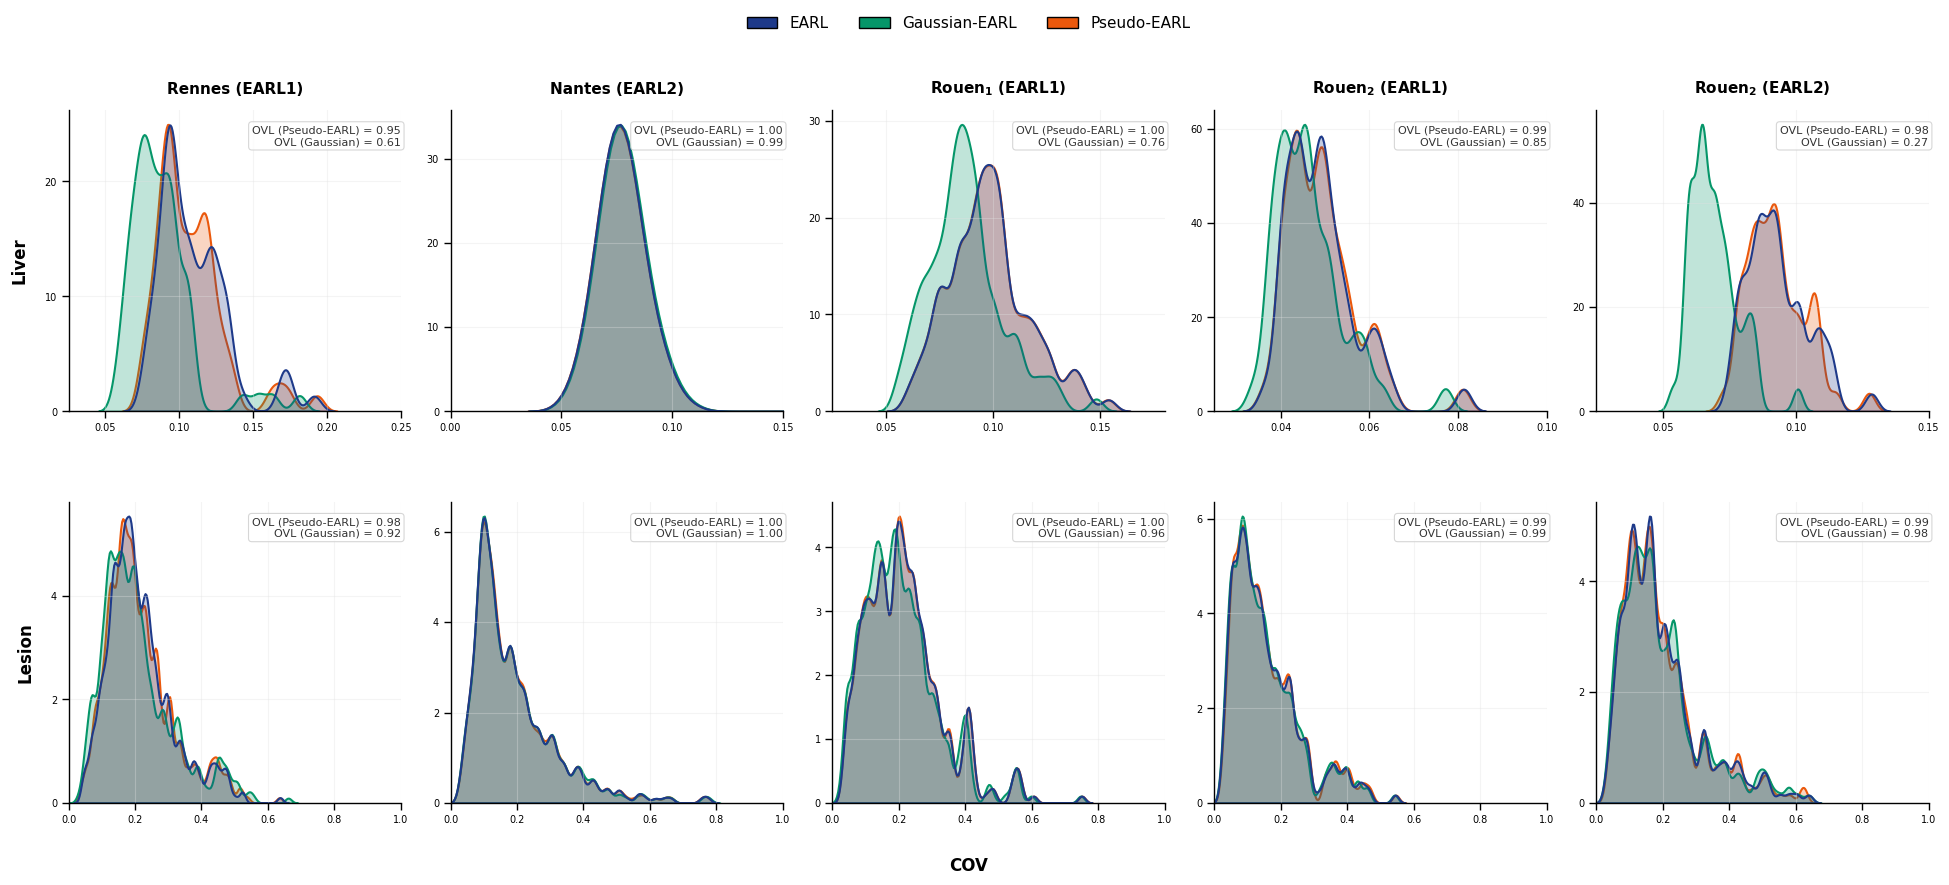

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

# --- RÈGLES DE STYLE STRICTES ---
plt.style.use('default')

# Fonction utilitaire pour calculer mathématiquement l'Overlap (OVL) ou l'IoU
def calculate_overlap_metrics(data1, data2, metric_type='ovl'):
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
        
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    min_x = min(data1.min(), data2.min())
    max_x = max(data1.max(), data2.max())
    margin = (max_x - min_x) * 0.2
    
    # Évaluation sur une grille fine pour l'intégrale
    x_eval = np.linspace(min_x - margin, max_x + margin, 1000)
    y1, y2 = kde1(x_eval), kde2(x_eval)
    
    # Intégrale de l'intersection (minimum des deux courbes)
    ovl = np.trapz(np.minimum(y1, y2), x_eval)
    
    if metric_type.lower() == 'iou':
        # Calcul de l'IoU : Intersection / Union (Union = Aire_1 + Aire_2 - Intersection = 2 - OVL)
        return ovl / (2.0 - ovl)
    
    return ovl


def plot_density_seaborn_multivoi(df, 
                                  target_vois=['liver', 'lesion'], 
                                  metric='RobustCOV',        # NOUVEAU: Mettre 'COV' ou 'RobustCOV' ici
                                  overlap_metric='ovl',
                                  show_overlap_text=True,    # NOUVEAU: Toggle pour cacher/afficher la box OVL
                                  xlim_list=None,
                                  ylim_list=None,
                                  font_scale=1.3,
                                  base_fontsize=14,
                                  force_x_zero=False,
                                  show_all_y_ticks=True,
                                  bw_adjust_list=[0.4, 0.4], 
                                  alpha_val=0.3,
                                  show_native_pet=True):
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION DES 5 CENTRES ---
    plot_configs = [
        {'domain_raw': 'rennes', 'title': 'Rennes (EARL1)', 'suffix': '1'},
        {'domain_raw': 'nantes', 'title': 'Nantes (EARL2)', 'suffix': '2'},
        {'domain_raw': 'chb', 'title': 'Rouen$_\\mathbf{1}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL2)', 'suffix': '2'}
    ]
    
    # --- GESTION DU NATIVE PET DYNAMIQUE ---
    if show_native_pet:
        colors = ['#a1a1aa', '#1e3a8a', '#059669', '#ea580c'] 
        hue_order = ['Native PET', 'EARL', 'Gaussian-EARL', 'Pseudo-EARL']
        target_mods_all = ['pet', 'earl1', 'earl2', 'pseudo-earl1', 'pseudo-earl2', 'gaussian-earl1', 'gaussian-earl2']
    else:
        colors = ['#1e3a8a', '#059669', '#ea580c']
        hue_order = ['EARL', 'Gaussian-EARL', 'Pseudo-EARL']
        target_mods_all = ['earl1', 'earl2', 'pseudo-earl1', 'pseudo-earl2', 'gaussian-earl1', 'gaussian-earl2']
    
    # --- 2. PRÉPARATION GLOBALE DES DONNÉES ---
    df_filtered = df[df['VOI'].str.lower().isin([v.lower() for v in target_vois])].copy()
    df_filtered['Domain'] = df_filtered['Domain'].str.lower()
    df_filtered['Modality'] = df_filtered['Modality'].str.lower()
    df_filtered = df_filtered.dropna(subset=['Domain', 'Modality', metric])
    
    n_rows = len(target_vois)
    n_cols = len(plot_configs)
    
    # --- 3. CRÉATION DE LA FIGURE ---
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4.5 * n_rows))
    
    if n_rows == 1:
        axes = np.atleast_2d(axes)
        
    for row_idx, target_voi in enumerate(target_vois):
        df_row = df_filtered[df_filtered['VOI'].str.lower() == target_voi.lower()]
        df_calc = df_row[df_row['Modality'].isin(target_mods_all)]
        
        current_bw = bw_adjust_list[row_idx] if (isinstance(bw_adjust_list, list) and len(bw_adjust_list) > row_idx) else 0.4
        
        if not df_calc.empty:
            xmin_calc, xmax_calc = np.percentile(df_calc[metric], 1), np.percentile(df_calc[metric], 99)
            margin = (xmax_calc - xmin_calc) * 0.1
            fallback_xmin = 0 if force_x_zero else max(0, xmin_calc - margin)
            fallback_xmax = xmax_calc + margin
        else:
            fallback_xmin, fallback_xmax = 0, 1

        for col_idx, config in enumerate(plot_configs):
            ax = axes[row_idx, col_idx]
            flat_idx = row_idx * n_cols + col_idx
            
            domain_raw = config['domain_raw']
            suffix = config['suffix']
            
            if show_native_pet:
                raw_mods = ['pet', f'earl{suffix}', f'gaussian-earl{suffix}', f'pseudo-earl{suffix}']
            else:
                raw_mods = [f'earl{suffix}', f'gaussian-earl{suffix}', f'pseudo-earl{suffix}']
            
            sub_df = df_row[(df_row['Domain'] == domain_raw) & 
                            (df_row['Modality'].isin(raw_mods))].copy()
            
            mod_map = {
                'pet': 'Native PET',
                f'earl{suffix}': 'EARL',
                f'gaussian-earl{suffix}': 'Gaussian-EARL',
                f'pseudo-earl{suffix}': 'Pseudo-EARL'
            }
            sub_df['Modality'] = sub_df['Modality'].map(mod_map)
            
            if sub_df.empty or len(sub_df) < 5:
                ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
                ax.axis('off')
                continue
                
            # --- 3A. LE NUAGE (KDE Plot) ---
            sns.kdeplot(
                data=sub_df, x=metric, hue='Modality', hue_order=hue_order, palette=colors,
                fill=True, common_norm=False, alpha=alpha_val, linewidth=1.5, bw_adjust=current_bw,
                clip=(0, None), ax=ax, legend=False, zorder=1
            )
            
            # --- 3B. CALCUL ET AFFICHAGE DE LA MÉTRIQUE (Conditionnel) ---
            if show_overlap_text:
                vals_earl = sub_df[sub_df['Modality'] == 'EARL'][metric].values
                vals_pseudo = sub_df[sub_df['Modality'] == 'Pseudo-EARL'][metric].values
                vals_gauss = sub_df[sub_df['Modality'] == 'Gaussian-EARL'][metric].values
                
                score_pseudo = calculate_overlap_metrics(vals_earl, vals_pseudo, metric_type=overlap_metric)
                score_gauss = calculate_overlap_metrics(vals_earl, vals_gauss, metric_type=overlap_metric)
                
                metric_label = "IoU" if overlap_metric.lower() == 'iou' else "OVL"
                score_text = ""
                
                if not np.isnan(score_pseudo):
                    score_text += f"{metric_label} (Pseudo-EARL) = {score_pseudo:.2f}\n"
                if not np.isnan(score_gauss):
                    score_text += f"{metric_label} (Gaussian) = {score_gauss:.2f}"
                    
                if score_text:
                    ax.text(1.0, 0.95, score_text.strip(), transform=ax.transAxes, 
                            ha='right', va='top', fontsize=8, fontweight='normal', color='#333333',
                            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8), zorder=5)
            
            # --- ESTHÉTIQUE & NETTOYAGE ---
            if row_idx == 0:
                ax.set_title(config['title'], fontweight='bold', pad=12, fontsize=base_fontsize + 1)
            else:
                ax.set_title("")
                
            ax.set_xlabel("")
            
            if col_idx == 0:
                ax.set_ylabel(f"{target_voi.capitalize()}", fontweight='bold', labelpad=12, fontsize=base_fontsize + 2)
            else:
                ax.set_ylabel("")
                
            # --- CONTRÔLE DES LIMITES X ET Y PAR SUBPLOT ---
            if xlim_list and len(xlim_list) > flat_idx and xlim_list[flat_idx] is not None:
                ax.set_xlim(xlim_list[flat_idx])
            else:
                ax.set_xlim(fallback_xmin, fallback_xmax)
                
            if ylim_list and len(ylim_list) > flat_idx and ylim_list[flat_idx] is not None:
                ax.set_ylim(ylim_list[flat_idx])
            else:
                ax.set_ylim(bottom=0)
            
            sns.despine(ax=ax, top=True, right=True, left=False)
            
            if show_all_y_ticks or col_idx == 0:
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)
                
            ax.xaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.grid(axis='both', linestyle='-', alpha=0.35, color='#e0e0e0')

    # --- TEXTE GLOBAL AXE X (Dynamique selon la métrique choisie) ---
    fig.supxlabel(f'{metric}', fontsize=base_fontsize + 2, fontweight='bold', y=0.03)

    # --- LÉGENDE GLOBALE ---
    legend_elements = [Patch(facecolor=c, edgecolor='black', linewidth=1., label=m) 
                       for m, c in zip(hue_order, colors)]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.00), 
               ncol=len(hue_order), frameon=False, fontsize=base_fontsize + 1)
    
    plt.subplots_adjust(hspace=0.3, wspace=0.15, bottom=0.11)
    plt.savefig(f"overlap_density_{metric}_{overlap_metric}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

# =========================================================
# EXEMPLE D'EXÉCUTION
# =========================================================
x_limits = [
    (0.025, 0.25), (0, 0.15), (0.025, 0.18), (0.025, 0.1), (0.025, 0.15), # Ligne 1 : Liver 
    (0, 1.),  (0, 1.),  (0, 1.),  (0, 1.), (0, 1.)      # Ligne 2 : Lesion
]

plot_density_seaborn_multivoi(
    master_df,
    metric='COV',                # <-- Choix de la métrique : 'COV' ou 'RobustCOV'
    overlap_metric='ovl',      
    show_overlap_text=True,     # <-- Toggle pour désactiver l'affichage de l'OVL/IoU
    xlim_list=x_limits,
    font_scale=.8,
    base_fontsize=10,
    bw_adjust_list=[0.45, 0.3], 
    alpha_val=0.25,
    show_native_pet=False
)


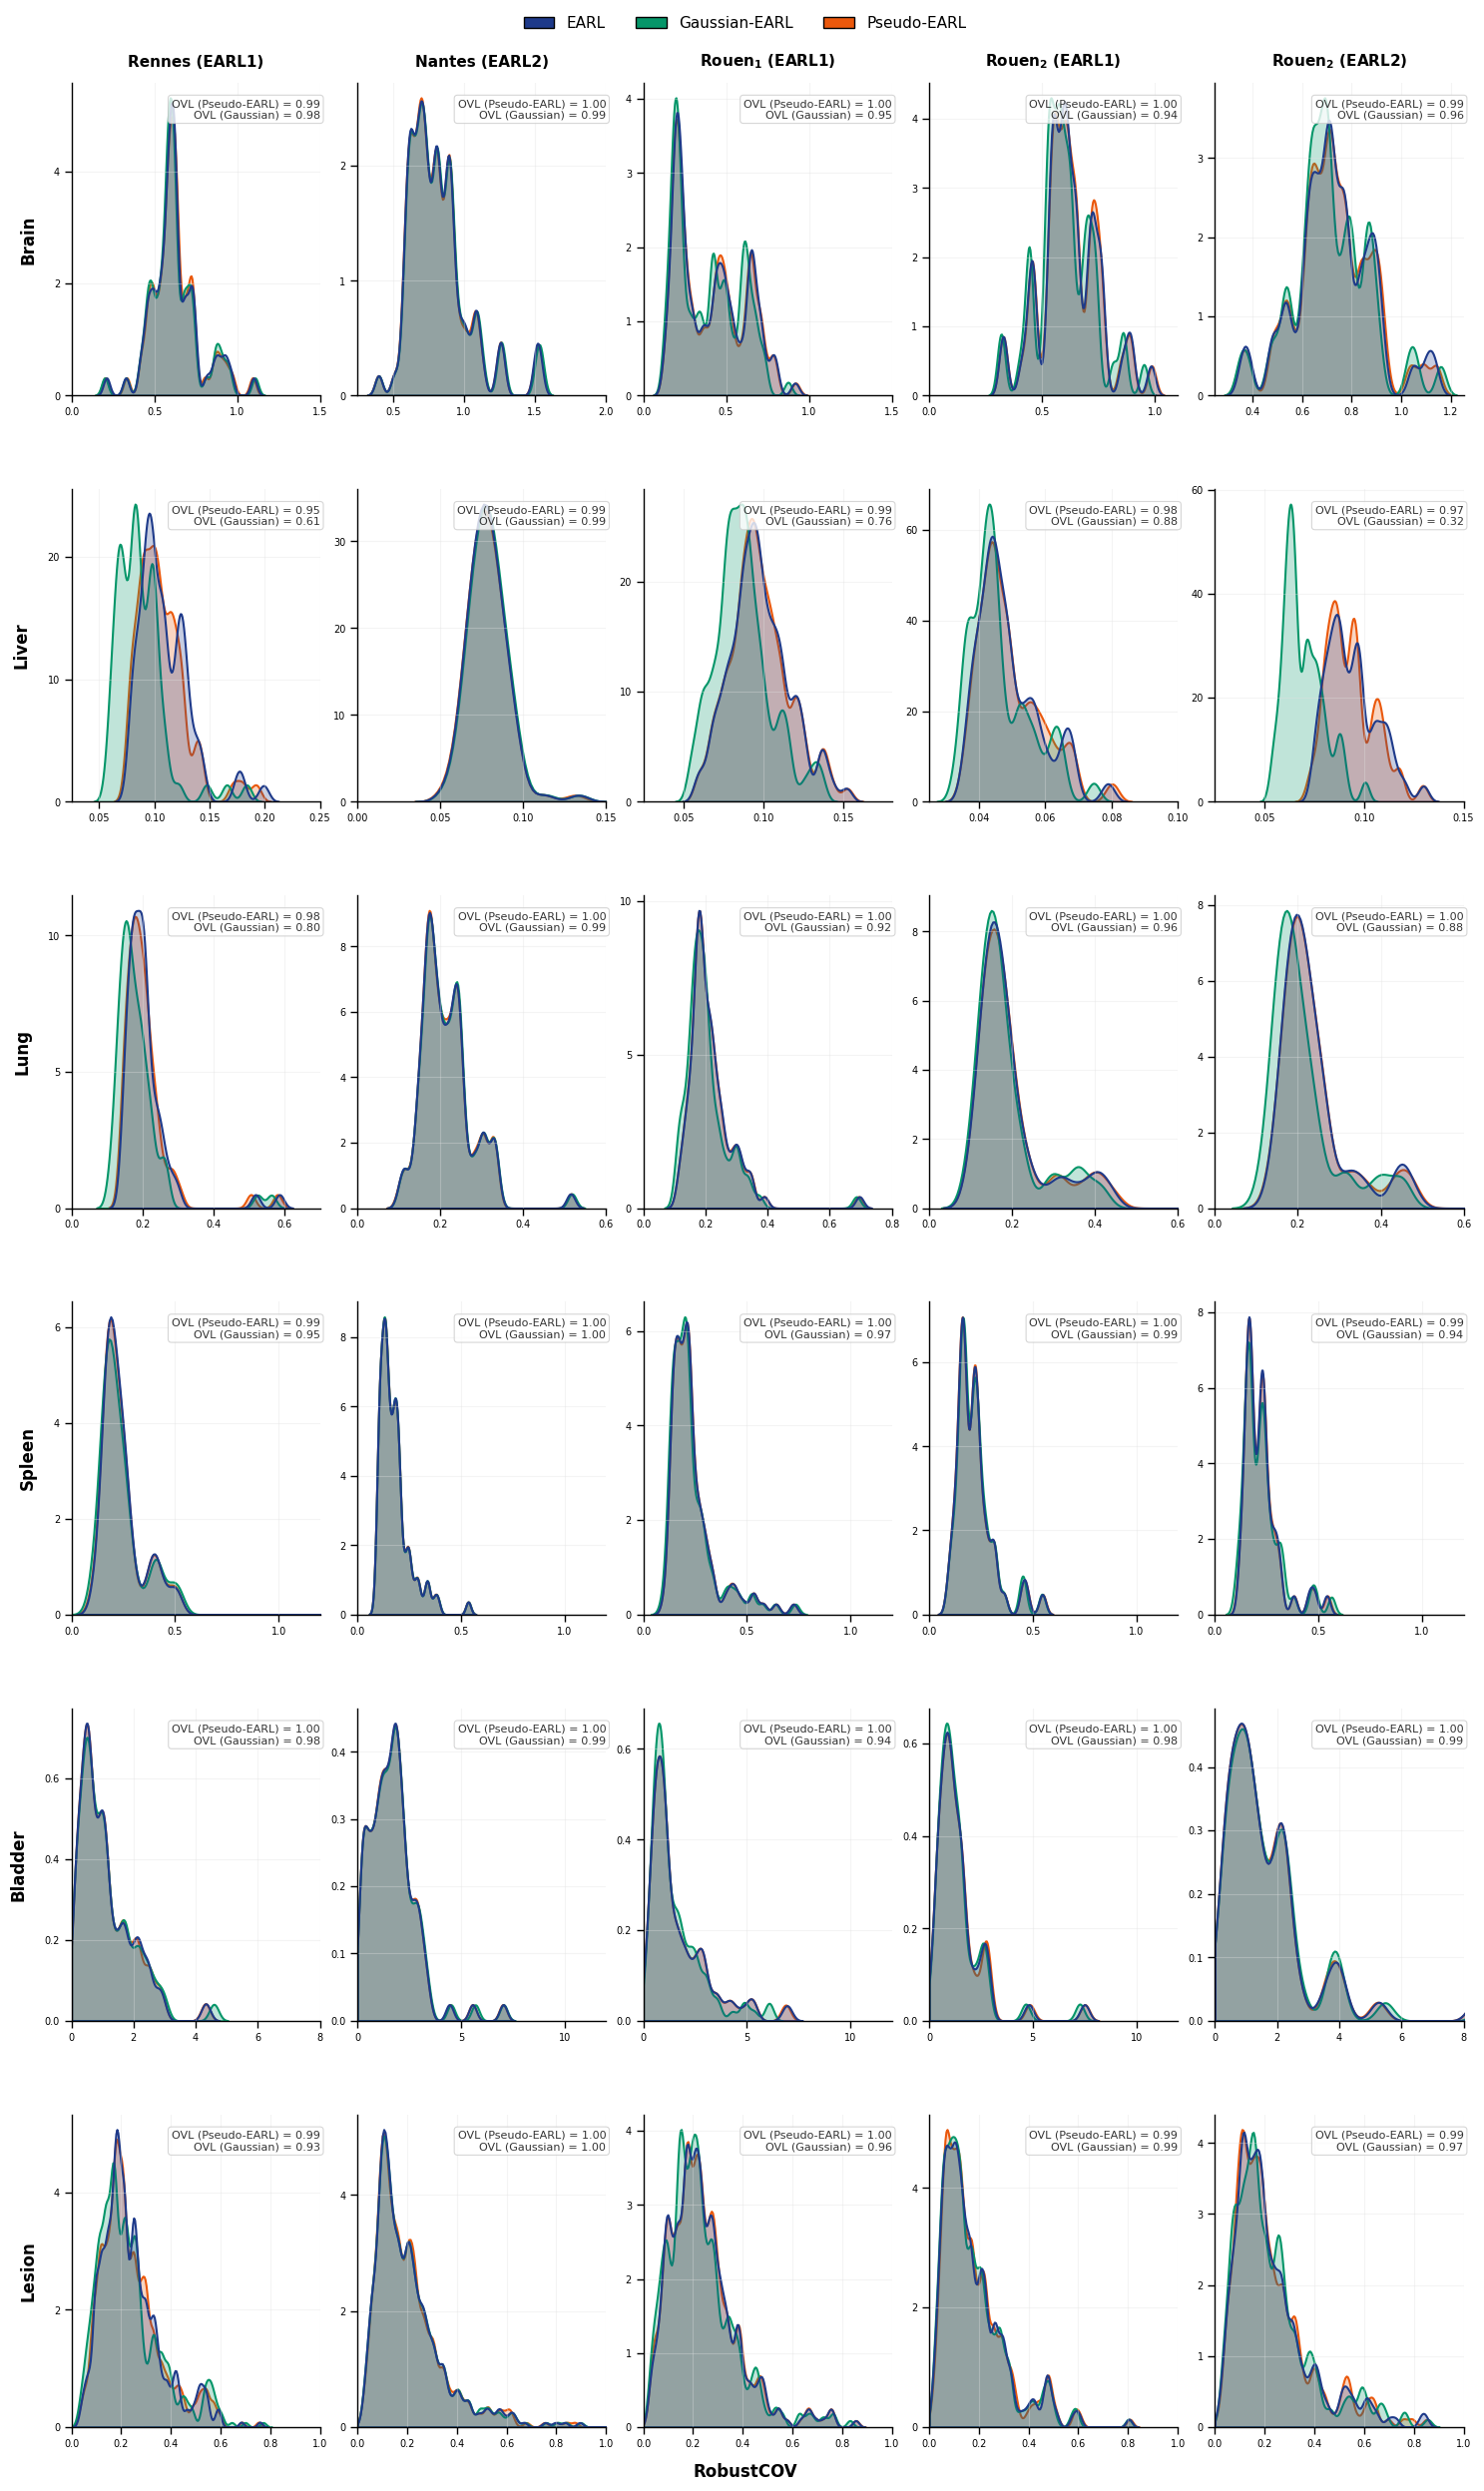

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

# --- RÈGLES DE STYLE STRICTES ---
plt.style.use('default')

# Fonction utilitaire pour calculer mathématiquement l'Overlap (OVL) ou l'IoU
def calculate_overlap_metrics(data1, data2, metric_type='ovl'):
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
        
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    min_x = min(data1.min(), data2.min())
    max_x = max(data1.max(), data2.max())
    margin = (max_x - min_x) * 0.2
    
    # Évaluation sur une grille fine pour l'intégrale
    x_eval = np.linspace(min_x - margin, max_x + margin, 1000)
    y1, y2 = kde1(x_eval), kde2(x_eval)
    
    # Intégrale de l'intersection (minimum des deux courbes)
    ovl = np.trapz(np.minimum(y1, y2), x_eval)
    
    if metric_type.lower() == 'iou':
        # Calcul de l'IoU : Intersection / Union (Union = Aire_1 + Aire_2 - Intersection = 2 - OVL)
        return ovl / (2.0 - ovl)
    
    return ovl


def plot_density_seaborn_multivoi(df, 
                                  target_vois=['brain', 'liver', 'lung', 'spleen', 'urinary_bladder', 'lesion'], 
                                  metric='RobustCOV',        # 'COV' ou 'RobustCOV'
                                  overlap_metric='ovl',      # 'ovl' ou 'iou'
                                  show_overlap_text=True,    # Toggle box OVL/IoU
                                  xlim_list=None,          
                                  ylim_list=None,          
                                  font_scale=1.3,
                                  base_fontsize=14,
                                  force_x_zero=False,
                                  show_all_y_ticks=True,
                                  bw_adjust_list=[0.4]*6,    # Liste des lissages par VOI
                                  alpha_val=0.3,
                                  show_native_pet=True):     # Toggle Native PET
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION DES 5 CENTRES ---
    plot_configs = [
        {'domain_raw': 'rennes', 'title': 'Rennes (EARL1)', 'suffix': '1'},
        {'domain_raw': 'nantes', 'title': 'Nantes (EARL2)', 'suffix': '2'},
        {'domain_raw': 'chb', 'title': 'Rouen$_\\mathbf{1}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL2)', 'suffix': '2'}
    ]
    
    # --- GESTION DU NATIVE PET DYNAMIQUE (Correction 'standard' -> 'pet') ---
    if show_native_pet:
        colors = ['#a1a1aa', '#1e3a8a', '#059669', '#ea580c'] 
        hue_order = ['Native PET', 'EARL', 'Gaussian-EARL', 'Pseudo-EARL']
        target_mods_all = ['pet', 'earl1', 'earl2', 'pseudo-earl1', 'pseudo-earl2', 'gaussian-earl1', 'gaussian-earl2']
    else:
        colors = ['#1e3a8a', '#059669', '#ea580c']
        hue_order = ['EARL', 'Gaussian-EARL', 'Pseudo-EARL']
        target_mods_all = ['earl1', 'earl2', 'pseudo-earl1', 'pseudo-earl2', 'gaussian-earl1', 'gaussian-earl2']
    
    # --- 2. PRÉPARATION GLOBALE DES DONNÉES ---
    df_filtered = df[df['VOI'].str.lower().isin([v.lower() for v in target_vois])].copy()
    df_filtered['Domain'] = df_filtered['Domain'].str.lower()
    df_filtered['Modality'] = df_filtered['Modality'].str.lower()
    df_filtered = df_filtered.dropna(subset=['Domain', 'Modality', metric])
    
    n_rows = len(target_vois)
    n_cols = len(plot_configs)
    
    # --- 3. CRÉATION DE LA FIGURE ---
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    
    if n_rows == 1:
        axes = np.atleast_2d(axes)
        
    for row_idx, target_voi in enumerate(target_vois):
        df_row = df_filtered[df_filtered['VOI'].str.lower() == target_voi.lower()]
        df_calc = df_row[df_row['Modality'].isin(target_mods_all)]
        
        # Attribution robuste du bw_adjust (fallback à 0.4 si la liste est trop courte)
        current_bw = bw_adjust_list[row_idx] if (isinstance(bw_adjust_list, list) and len(bw_adjust_list) > row_idx) else 0.4
        
        if not df_calc.empty:
            xmin_calc, xmax_calc = np.percentile(df_calc[metric], 1), np.percentile(df_calc[metric], 99)
            margin = (xmax_calc - xmin_calc) * 0.1
            fallback_xmin = 0 if force_x_zero else max(0, xmin_calc - margin)
            fallback_xmax = xmax_calc + margin
        else:
            fallback_xmin, fallback_xmax = 0, 1

        for col_idx, config in enumerate(plot_configs):
            ax = axes[row_idx, col_idx]
            flat_idx = row_idx * n_cols + col_idx
            
            domain_raw = config['domain_raw']
            suffix = config['suffix']
            
            if show_native_pet:
                raw_mods = ['pet', f'earl{suffix}', f'gaussian-earl{suffix}', f'pseudo-earl{suffix}']
            else:
                raw_mods = [f'earl{suffix}', f'gaussian-earl{suffix}', f'pseudo-earl{suffix}']
            
            sub_df = df_row[(df_row['Domain'] == domain_raw) & 
                            (df_row['Modality'].isin(raw_mods))].copy()
            
            mod_map = {
                'pet': 'Native PET',
                f'earl{suffix}': 'EARL',
                f'gaussian-earl{suffix}': 'Gaussian-EARL',
                f'pseudo-earl{suffix}': 'Pseudo-EARL'
            }
            sub_df['Modality'] = sub_df['Modality'].map(mod_map)
            
            if sub_df.empty or len(sub_df) < 5:
                ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
                ax.axis('off')
                continue
                
            # --- 3A. LE NUAGE (KDE Plot) (Correction clip) ---
            sns.kdeplot(
                data=sub_df, x=metric, hue='Modality', hue_order=hue_order, palette=colors,
                fill=True, common_norm=False, alpha=alpha_val, linewidth=1.5, bw_adjust=current_bw,
                clip=(0, None), ax=ax, legend=False, zorder=1
            )
            
            # --- 3B. CALCUL ET AFFICHAGE DE LA MÉTRIQUE ---
            if show_overlap_text:
                vals_earl = sub_df[sub_df['Modality'] == 'EARL'][metric].values
                vals_pseudo = sub_df[sub_df['Modality'] == 'Pseudo-EARL'][metric].values
                vals_gauss = sub_df[sub_df['Modality'] == 'Gaussian-EARL'][metric].values
                
                score_pseudo = calculate_overlap_metrics(vals_earl, vals_pseudo, metric_type=overlap_metric)
                score_gauss = calculate_overlap_metrics(vals_earl, vals_gauss, metric_type=overlap_metric)
                
                metric_label = "IoU" if overlap_metric.lower() == 'iou' else "OVL"
                score_text = ""
                
                if not np.isnan(score_pseudo):
                    score_text += f"{metric_label} (Pseudo-EARL) = {score_pseudo:.2f}\n"
                if not np.isnan(score_gauss):
                    score_text += f"{metric_label} (Gaussian) = {score_gauss:.2f}"
                    
                if score_text:
                    ax.text(1.0, 0.95, score_text.strip(), transform=ax.transAxes, 
                            ha='right', va='top', fontsize=8, fontweight='normal', color='#333333',
                            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8), zorder=5)
            
            # --- ESTHÉTIQUE & NETTOYAGE ---
            if row_idx == 0:
                ax.set_title(config['title'], fontweight='bold', pad=12, fontsize=base_fontsize + 1)
            else:
                ax.set_title("")
                
            ax.set_xlabel("")
            
            if col_idx == 0:
                display_voi = "Bladder" if target_voi.lower() == "urinary_bladder" else target_voi.capitalize()
                ax.set_ylabel(f"{display_voi}", fontweight='bold', labelpad=12, fontsize=base_fontsize + 2)
            else:
                ax.set_ylabel("")
                
            # --- CONTRÔLE DES LIMITES X ET Y PAR SUBPLOT ---
            if xlim_list and len(xlim_list) > flat_idx and xlim_list[flat_idx] is not None:
                ax.set_xlim(xlim_list[flat_idx])
            else:
                ax.set_xlim(fallback_xmin, fallback_xmax)
                
            if ylim_list and len(ylim_list) > flat_idx and ylim_list[flat_idx] is not None:
                ax.set_ylim(ylim_list[flat_idx])
            else:
                ax.set_ylim(bottom=0)
            
            sns.despine(ax=ax, top=True, right=True, left=False)
            
            if show_all_y_ticks or col_idx == 0:
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)
                
            ax.xaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.grid(axis='both', linestyle='-', alpha=0.35, color='#e0e0e0')

    # --- TEXTE GLOBAL AXE X (Dynamique) ---
    fig.supxlabel(f'{metric}', fontsize=base_fontsize + 2, fontweight='bold', y=0.03)

    # --- LÉGENDE GLOBALE ---
    legend_elements = [Patch(facecolor=c, edgecolor='black', linewidth=1., label=m) 
                       for m, c in zip(hue_order, colors)]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
               ncol=len(hue_order), frameon=False, fontsize=base_fontsize + 1)
    
    plt.subplots_adjust(hspace=0.3, wspace=0.15, bottom=0.05, top=0.92)
    plt.savefig(f"all_vois_overlap_density_{metric}_{overlap_metric}.svg", bbox_inches='tight', dpi=300)
    plt.show()

# =========================================================
# EXEMPLE D'EXÉCUTION
# =========================================================

x_limits = [
    # Ligne 1 : Brain
    (0, 1.5),  (0.25, 2.),  (0, 1.5),  (0, 1.1),  (0.25, 1.25), 
    # Ligne 2 : Liver
    (0.025, 0.25), (0, 0.15), (0.025, 0.18), (0.025, 0.1), (0.025, 0.15),
    # Ligne 3 : Lung
    (0, 0.7),  (0, 0.6),  (0, .8),  (0, 0.6),  (0, 0.6), 
    # Ligne 4 : Spleen
    (0, 1.2),  (0, 1.2),  (0, 1.2),  (0, 1.2),  (0, 1.2), 
    # Ligne 5 : Bladder
    (0, 8),  (0, 12.0),  (0, 12.0),  (0, 12.0),  (0, 8.0), 
    # Ligne 6 : Lesion
    (0, 1.),  (0, 1.),  (0, 1.),  (0, 1.), (0, 1.) 
]


# Liste de 6 valeurs pour bw_adjust (une par VOI : Brain, Liver, Lung, Spleen, Bladder, Lesion)
bw_adjustments = [0.3, 0.45, 0.4, 0.4, 0.4, 0.3]

plot_density_seaborn_multivoi(
    master_df,
    target_vois=['brain', 'liver', 'lung', 'spleen', 'urinary_bladder', 'lesion'],
    metric='RobustCOV',          # Choix entre 'COV' et 'RobustCOV'
    overlap_metric='ovl',      
    show_overlap_text=True,      # Toggle pour afficher/masquer la box OVL
    xlim_list=x_limits,
    font_scale=.8,
    base_fontsize=10,
    bw_adjust_list=bw_adjustments, # Injection de la liste des 6 BW
    alpha_val=0.25,
    show_native_pet=False         # Toggle pour afficher/masquer Native PET
)

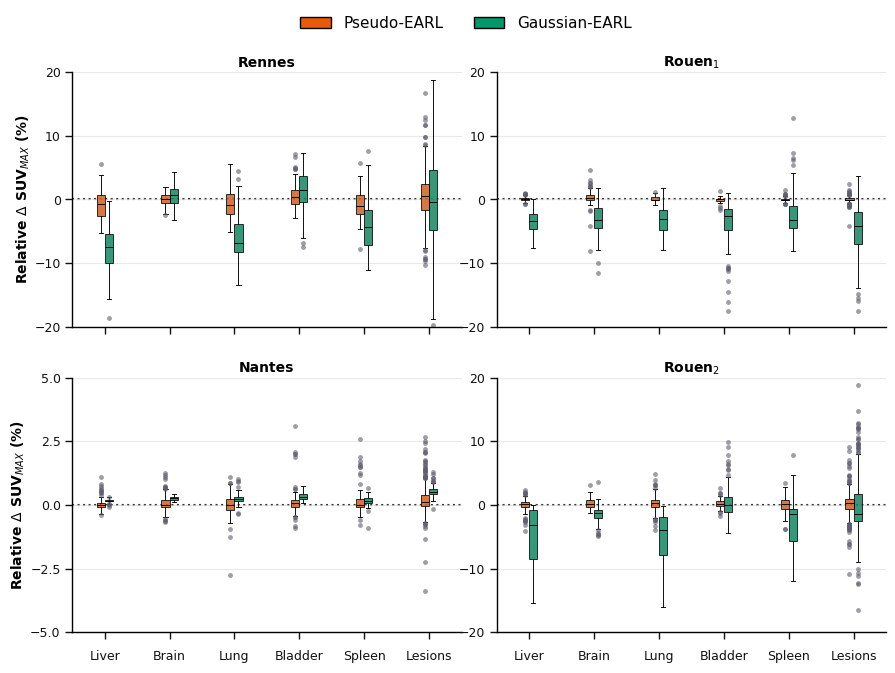

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_multicenter_2x2_delta_boxplot(df, 
                                       feature='original_firstorder_Maximum', # S'adapte aux noms de pyradiomics
                                       target_vois=['liver', 'brain', 'lung', 'urinary_bladder', 'spleen', 'lesion'],
                                       voi_labels={'liver': 'Liver', 'brain': 'Brain', 'lung': 'Lung', 
                                                   'urinary_bladder': 'Bladder', 'spleen': 'Spleen', 'lesion': 'Lesions'},
                                       figsize=(20, 12),
                                       ylim_list=None,             
                                       box_width=0.25,          
                                       box_alpha=0.85,         
                                       show_outliers=True,     
                                       font_scale=1.0, 
                                       base_fontsize=9,
                                       wspace=0.10,           
                                       hspace=0.15,           
                                       share_y_axis=False,    
                                       top_margin=0.92,       
                                       bottom_margin=0.08,
                                       y_tick_max_bins=8,
                                       x_padding=0.5,
                                       y_label_pad=10,        
                                       title_pad=12,
                                       show_legend=True):     # NOUVEAU : Option pour masquer la légende
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION DES CENTRES ÉPURÉE ---
    centers_config = [
        {'domain': 'rennes', 'title': 'Rennes', 'standards': ['1']},
        {'domain': 'chb', 'title': 'Rouen$_1$', 'standards': ['1']},
        {'domain': 'nantes', 'title': 'Nantes', 'standards': ['2']},
        {'domain': 'a100', 'title': 'Rouen$_2$', 'standards': ['1', '2']}
    ]
    
    colors = {
        'Pseudo-EARL': '#ea580c',     
        'Gaussian-EARL': '#059669'    
    }
    hue_order = ['Pseudo-EARL', 'Gaussian-EARL']
    
    # Clés de fusion robustes (gestion des composantes multiples)
    merge_keys = [col for col in ['Subject_ID', 'Domain', 'VOI', 'component', 'Component'] if col in df.columns]
    
    # --- 2. EXTRACTION ROBUSTE ET CALCUL DU DELTA RELATIF (%) ---
    data_list = []
    
    for voi in target_vois:
        voi_display = voi_labels.get(voi.lower(), voi.capitalize())
        
        for center in centers_config:
            domain = center['domain']
            center_title = center['title']
            
            for std in center['standards']:
                ref_mod = f'earl{std}'
                ps_mod = f'pseudo-earl{std}'
                gs_mod = f'gaussian-earl{std}'
                
                # Sous-échantillon pour le domaine et la VOI actuels
                df_sub = df[(df['VOI'].str.lower() == voi.lower()) & (df['Domain'].str.lower() == domain)]
                
                df_ref = df_sub[df_sub['Modality'].str.lower() == ref_mod][merge_keys + [feature]]
                df_ps = df_sub[df_sub['Modality'].str.lower() == ps_mod][merge_keys + [feature]]
                df_gs = df_sub[df_sub['Modality'].str.lower() == gs_mod][merge_keys + [feature]]
                
                # Fusion pour Pseudo-EARL
                m_ps = pd.merge(df_ref, df_ps, on=merge_keys, suffixes=('_ref', '_tgt'))
                if not m_ps.empty:
                    # Formule : ((Cible - Réf) / |Réf|) * 100
                    m_ps['Delta'] = np.where(m_ps[f'{feature}_ref'] == 0, np.nan, 
                                            ((m_ps[f'{feature}_tgt'] - m_ps[f'{feature}_ref']) / m_ps[f'{feature}_ref'].abs()) * 100)
                    for val in m_ps['Delta'].dropna():
                        data_list.append({'VOI': voi_display, 'Center': center_title, 'Method': 'Pseudo-EARL', 'Delta_Pct': val})
                
                # Fusion pour Gaussian-EARL
                m_gs = pd.merge(df_ref, df_gs, on=merge_keys, suffixes=('_ref', '_tgt'))
                if not m_gs.empty:
                    m_gs['Delta'] = np.where(m_gs[f'{feature}_ref'] == 0, np.nan, 
                                            ((m_gs[f'{feature}_tgt'] - m_gs[f'{feature}_ref']) / m_gs[f'{feature}_ref'].abs()) * 100)
                    for val in m_gs['Delta'].dropna():
                        data_list.append({'VOI': voi_display, 'Center': center_title, 'Method': 'Gaussian-EARL', 'Delta_Pct': val})
                            
    df_plot = pd.DataFrame(data_list)

    if df_plot.empty:
        print("Aucune donnée trouvée ou calculable pour cette feature.")
        return

    if ylim_list is not None:
        share_y_axis = False

    # --- 3. CRÉATION DE LA FIGURE ---
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=share_y_axis) 
    axes = axes.flatten() 
    
    flierprops = {
        'marker': 'o', 
        'markerfacecolor': "#5d5d6d", 
        'markeredgecolor': 'none', 
        'alpha': 0.6, 
        'markersize': 3.5
    }

    # Formatage dynamique du label Y
    if 'max' in feature.lower():
        y_label = r"Relative $\Delta$ SUV$_{MAX}$ (%)"
    elif 'mean' in feature.lower():
        y_label = r"Relative $\Delta$ SUV$_{MEAN}$ (%)"
    elif 'peak' in feature.lower():
        y_label = r"Relative $\Delta$ SUV$_{PEAK}$ (%)"
    else:
        # Nettoyage si c'est un nom pyradiomics direct
        feat_clean = feature.replace('original_firstorder_', '').replace('_', ' ')
        y_label = f"Relative $\\Delta$ {feat_clean} (%)"

    for i, center_config in enumerate(centers_config):
        ax = axes[i]
        center_title = center_config['title']
        
        df_center = df_plot[df_plot['Center'] == center_title]
        
        if df_center.empty:
            ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
            ax.axis('off')
            continue
            
        sns.boxplot(
            data=df_center, x='VOI', y='Delta_Pct', hue='Method', palette=colors,
            hue_order=hue_order, notch=False, width=box_width, ax=ax,
            showfliers=show_outliers, flierprops=flierprops,
            linewidth=.65,
            linecolor='black',
            boxprops={'alpha': box_alpha, 'edgecolor': 'black'}
        )

        ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.8, zorder=0)

        # Titre des sous-graphes (utilisation de title_pad)
        ax.set_title(center_title, fontweight='bold', pad=title_pad, fontsize=base_fontsize)
        
        # --- GESTION DES LABELS AXE X (Uniquement en bas) ---
        ax.set_xlabel("")
        if i < 2: 
            ax.tick_params(labelbottom=False)
        
        # --- GESTION DES LABELS AXE Y (Uniquement à gauche) ---
        if i % 2 == 0: 
            ax.set_ylabel(y_label, fontweight='bold', labelpad=y_label_pad, fontsize=base_fontsize)
        else: 
            ax.set_ylabel("")
            if share_y_axis:
                ax.tick_params(labelleft=False)
                
        # --- APPLICATION DE LA LISTE DES LIMITES Y ---
        if ylim_list is not None and len(ylim_list) > i and ylim_list[i] is not None:
            ax.set_ylim(ylim_list[i])
            
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_xlim(-x_padding, len(target_vois) - 1 + x_padding)
            
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.)
        ax.spines['left'].set_color("#000000")
        ax.spines['bottom'].set_linewidth(1.)
        ax.spines['bottom'].set_color("#000000")
        
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#111111")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#111111")
        
        ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(y_tick_max_bins, steps=[1, 2, 2.5, 5, 10]))
        ax.grid(axis='y', linestyle='-', alpha=0.7, color='#e0e0e0')

    # --- 4. LÉGENDE GLOBALE ---
    if show_legend:
        legend_elements = [Patch(facecolor=colors[m], edgecolor='black', linewidth=1., label=m) for m in hue_order]
        fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
                   ncol=2, frameon=False, fontsize=base_fontsize + 1)
    
    plt.subplots_adjust(wspace=wspace, hspace=hspace, bottom=bottom_margin, top=top_margin)
    
    # Save figure as svg
    clean_feature_name = feature.replace('original_firstorder_', '')
    plt.savefig(f"multicenter_2x2_delta_boxplot_{clean_feature_name}.svg", format='svg', bbox_inches='tight', dpi=300)
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
plot_multicenter_2x2_delta_boxplot(
    df=master_df,                                       # Ton raw DataFrame
    feature='original_firstorder_Maximum',              # Extraction directe du SUV Max
    ylim_list=[(-20, 20), (-20, 20), (-5, 5), (-20, 20)], 
    figsize=(10.5, 7), 
    wspace=0.09, 
    hspace=0.2,              
    y_tick_max_bins=4,      
    bottom_margin=0.08,
    top_margin=0.88,
    box_width=0.25,
    box_alpha=0.85,
    font_scale=0.8,
    base_fontsize=10,
    x_padding=0.5,
    y_label_pad=2,            
    title_pad=4,
    show_legend=True          # Toggle pour la légende
)

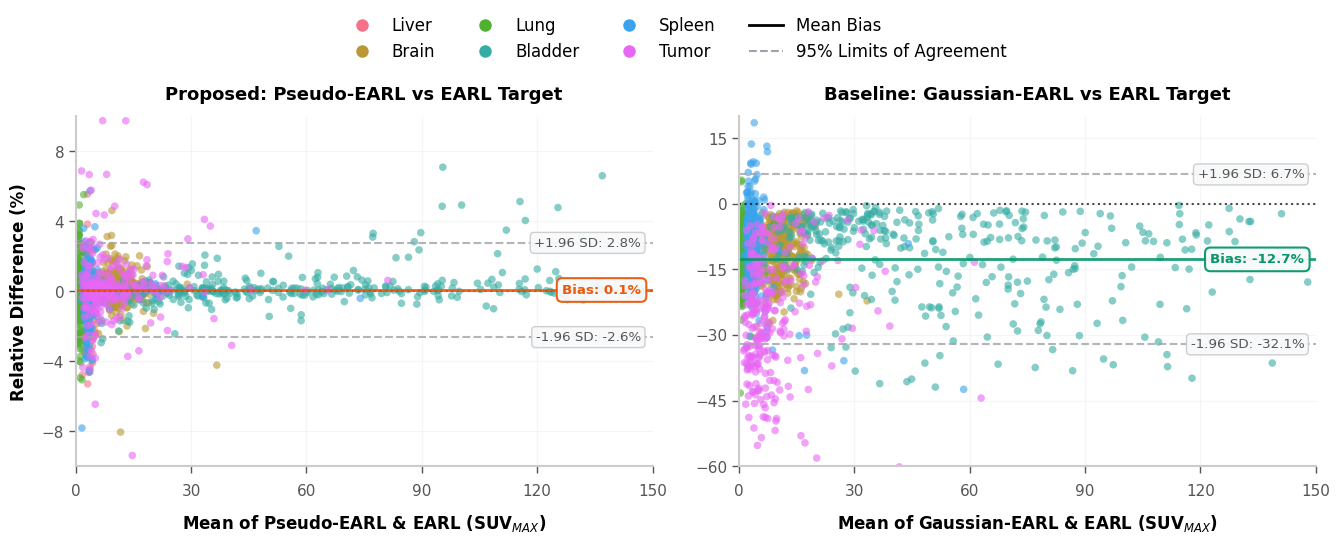

In [ ]:
import numpy as np
import pandas as pd

def fetch_features_bland_altman_data(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    """
    Extrait les données pour créer 93 points (un par feature).
    Pour chaque feature, calcule la magnitude moyenne (axe X) et le biais relatif moyen (axe Y).
    """
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    all_features = [c for c in df.columns if c.startswith('original_') and 'shape' not in c.lower()]
    
    # 1. Fusion stricte par standard (EARL1 / EARL2)
    merged_p_list, merged_g_list = [], []
    for suffix in ['1', '2']:
        df_gt = df[df['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df[df['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df[df['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        if not df_gt.empty and not df_pseudo.empty:
            merged_p_list.append(pd.merge(df_gt, df_pseudo, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
        if not df_gt.empty and not df_gauss.empty:
            merged_g_list.append(pd.merge(df_gt, df_gauss, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
            
    merged_p = pd.concat(merged_p_list, ignore_index=True) if merged_p_list else pd.DataFrame()
    merged_g = pd.concat(merged_g_list, ignore_index=True) if merged_g_list else pd.DataFrame()
    
    # 2. Filtrage sur les VOIs ciblés
    valid_vois = [v.lower() if v.lower() != 'bladder' else 'urinary_bladder' for v in target_vois]
    merged_p = merged_p[merged_p['VOI'].str.lower().isin(valid_vois)]
    merged_g = merged_g[merged_g['VOI'].str.lower().isin(valid_vois)]
    
    data_list = []
    
    # 3. Calcul du Biais Global par Feature
    for feat in all_features:
        col_gt, col_pred = f"{feat}_gt", f"{feat}_pred"
        
        # Pour PseudoEARL-Net
        if col_gt in merged_p.columns and col_pred in merged_p.columns:
            gt_p, pred_p = merged_p[col_gt].dropna().values, merged_p[col_pred].dropna().values
            if len(gt_p) > 0:
                mean_mag = np.mean((gt_p + pred_p) / 2)
                safe_gt = np.where(gt_p == 0, 1e-8, gt_p) # Sécurité division par 0
                bias_pct = np.nanmean(((pred_p - gt_p) / safe_gt) * 100)
                data_list.append({'Feature': feat, 'Method': 'PseudoEARL-Net', 'Mean_Magnitude': mean_mag, 'Mean_Bias': bias_pct})
                
        # Pour Gaussian-EARL
        if col_gt in merged_g.columns and col_pred in merged_g.columns:
            gt_g, pred_g = merged_g[col_gt].dropna().values, merged_g[col_pred].dropna().values
            if len(gt_g) > 0:
                mean_mag = np.mean((gt_g + pred_g) / 2)
                safe_gt = np.where(gt_g == 0, 1e-8, gt_g)
                bias_pct = np.nanmean(((pred_g - gt_g) / safe_gt) * 100)
                data_list.append({'Feature': feat, 'Method': 'Gaussian-EARL', 'Mean_Magnitude': mean_mag, 'Mean_Bias': bias_pct})
                
    return pd.DataFrame(data_list)

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as transforms
from matplotlib.ticker import MaxNLocator
import numpy as np

plt.style.use('default')

def plot_features_bland_altman(df_plot, 
                               figsize=(16, 7),
                               xlim_list=None,     
                               ylim_list=None,     
                               font_scale=1.1, 
                               base_fontsize=13,
                               # --- PARAMÈTRES GRAPHIQUES ---
                               dot_color='#111111',       # Noir subtil
                               dot_size=35,               # Taille des 93 points
                               dot_alpha=0.6,             # Transparence
                               wspace=0.15):              # Espace entre les deux subplots
    
    sns.set_context("paper", font_scale=font_scale)
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False, sharex=False)
    
    method_colors = {
        'PseudoEARL-Net': '#ea580c',     
        'Gaussian-EARL': '#059669'    
    }
    panels = [
        {'ax': axes[0], 'method': 'Gaussian-EARL'},
        {'ax': axes[1], 'method': 'PseudoEARL-Net'}
    ]
    
    # Calcul de la dispersion max pour unifier visuellement les axes Y si non précisés
    max_dispersion = np.nanpercentile(np.abs(df_plot['Mean_Bias']), 99) * 1.3

    for i, panel in enumerate(panels):
        ax = panel['ax']
        method = panel['method']
        
        df_method = df_plot[df_plot['Method'] == method]
        if df_method.empty:
            ax.axis('off')
            continue
            
        # --- 3A. TRACÉ DES 93 POINTS (CERCLES NOIRS SUBTILS) ---
        sns.scatterplot(
            data=df_method, x='Mean_Magnitude', y='Mean_Bias', 
            color=dot_color, s=dot_size, alpha=dot_alpha, edgecolor='none', ax=ax, legend=False
        )
        
        # --- L'ASTUCE LOGARITHMIQUE OBLIGATOIRE ---
        # Sans ça, toutes les features se superposent sur la ligne du zéro
        ax.set_xscale('symlog', linthresh=1e-2)
        
        # --- 3B. STATISTIQUES BLAND-ALTMAN DES FEATURES ---
        bias = np.nanmean(df_method['Mean_Bias'])
        sd = np.nanstd(df_method['Mean_Bias'], ddof=1)
        loa_upper = bias + 1.96 * sd
        loa_lower = bias - 1.96 * sd
        
        # --- 3C. TRACÉ DES LIGNES ---
        ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)
        
        color_bias = method_colors[method]
        ax.axhline(bias, color=color_bias, linestyle='-', linewidth=2.5, zorder=2, alpha=0.9)
        ax.axhline(loa_upper, color='#a1a1aa', linestyle='--', linewidth=1.5, zorder=2, alpha=0.8)
        ax.axhline(loa_lower, color='#a1a1aa', linestyle='--', linewidth=1.5, zorder=2, alpha=0.8)

        # --- 3D. LIMITES X/Y ---
        if ylim_list and len(ylim_list) > i and ylim_list[i] is not None:
            ax.set_ylim(ylim_list[i])
        else:
            ax.set_ylim(-max_dispersion, max_dispersion)
            
        if xlim_list and len(xlim_list) > i and xlim_list[i] is not None:
            ax.set_xlim(xlim_list[i])
        
        # --- 3E. ANNOTATIONS AVEC BBOX ---
        # Transform mathématique : Coordonnée X ancrée à droite (0.98), Coordonnée Y sur la Data (bias)
        trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
        
        bbox_bias = dict(boxstyle="round,pad=0.4", fc="#f8f9fa", ec=color_bias, lw=1.5, alpha=0.95)
        bbox_loa = dict(boxstyle="round,pad=0.3", fc="#f8f9fa", ec="#cccccc", lw=1.0, alpha=0.95)

        ax.text(0.98, bias, f"Bias: {bias:.1f}%", color=color_bias, fontweight='bold', 
                va='center', ha='right', bbox=bbox_bias, transform=trans, zorder=5)
        ax.text(0.98, loa_upper, f"+1.96 SD: {loa_upper:.1f}%", color='#555555', 
                va='center', ha='right', bbox=bbox_loa, transform=trans, zorder=5)
        ax.text(0.98, loa_lower, f"-1.96 SD: {loa_lower:.1f}%", color='#555555', 
                va='center', ha='right', bbox=bbox_loa, transform=trans, zorder=5)

        # --- ESTHÉTIQUE & NETTOYAGE ---
        ax.set_title(method, fontweight='bold', pad=15, fontsize=base_fontsize + 2)
        ax.set_xlabel(f"Average Feature Magnitude (Log Scale)", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        
        if i == 0:
            ax.set_ylabel(f"Mean Relative Bias of Feature (%)", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        else:
            ax.set_ylabel("")
            
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#555555")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#555555")
        
        ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(6))
        ax.grid(axis='both', linestyle='-', alpha=0.3, color='#e0e0e0')

    plt.subplots_adjust(wspace=wspace, bottom=0.15, top=0.88)
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def fetch_radiomics_ccc_data(df, group_by='centers', target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['FirstOrder', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    center_configs = [
        {'label': 'Rennes (EARL 1)', 'domain': 'rennes', 'suffix': '1'},
        {'label': 'Nantes (EARL 2)', 'domain': 'nantes', 'suffix': '2'},
        {'label': 'Rouen$_1$ (EARL 1)', 'domain': 'chb', 'suffix': '1'},
        {'label': 'Rouen$_2$ (EARL 1)', 'domain': 'a100', 'suffix': '1'},
        {'label': 'Rouen$_2$ (EARL 2)', 'domain': 'a100', 'suffix': '2'}
    ]
    
    family_configs = [{'label': l, 'prefix': f'original_{f}_'} for l, f in zip(family_labels, families)]
    
    primary_loop = center_configs if group_by == 'centers' else family_configs
    secondary_loop = family_configs if group_by == 'centers' else center_configs
    
    data_list = []
    
    for primary_cfg in primary_loop:
        ccc_pseudo_list, lci_pseudo_list, uci_pseudo_list = [], [], []
        ccc_gauss_list, lci_gauss_list, uci_gauss_list = [], [], []
        
        for secondary_cfg in secondary_loop:
            c_cfg = primary_cfg if group_by == 'centers' else secondary_cfg
            f_cfg = secondary_cfg if group_by == 'centers' else primary_cfg
            
            domain, suffix = c_cfg['domain'], c_cfg['suffix']
            fam_cols = [c for c in df.columns if c.lower().startswith(f_cfg['prefix'])]
            
            for feature in fam_cols:
                for voi in target_vois:
                    voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
                    
                    earl = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                    pseudo = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                    gauss = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                    
                    min_len = min(len(earl), len(pseudo), len(gauss))
                    if min_len > 3:
                        ccc_p, l_p, u_p, _ = calculate_ccc_and_ci(earl[:min_len], pseudo[:min_len])
                        ccc_g, l_g, u_g, _ = calculate_ccc_and_ci(earl[:min_len], gauss[:min_len])
                        
                        if not np.isnan(ccc_p):
                            ccc_pseudo_list.append(ccc_p); lci_pseudo_list.append(l_p); uci_pseudo_list.append(u_p)
                        if not np.isnan(ccc_g):
                            ccc_gauss_list.append(ccc_g); lci_gauss_list.append(l_g); uci_gauss_list.append(u_g)
                            
        if ccc_pseudo_list:
            data_list.append({
                'Group_Label': primary_cfg['label'], 'Method': 'PseudoEARL-Net',
                'CCC': np.mean(ccc_pseudo_list), 'LCI': np.mean(lci_pseudo_list), 'UCI': np.mean(uci_pseudo_list)
            })
        if ccc_gauss_list:
            data_list.append({
                'Group_Label': primary_cfg['label'], 'Method': 'Gaussian-EARL',
                'CCC': np.mean(ccc_gauss_list), 'LCI': np.mean(lci_gauss_list), 'UCI': np.mean(uci_gauss_list)
            })

    return pd.DataFrame(data_list)

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def draw_gradient_barh(ax, y, width, height, base_color):
    c_left = mcolors.to_rgba(base_color, alpha=0.95)
    c_right = mcolors.to_rgba(base_color, alpha=0.35)
    cmap = mcolors.LinearSegmentedColormap.from_list('grad', [c_left, c_right])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, extent=[0, width, y - height/2, y + height/2], aspect='auto', cmap=cmap, zorder=2)
    ax.add_patch(plt.Rectangle((0, y - height/2), width, height, fill=False, edgecolor=base_color, linewidth=1, zorder=3))

def plot_radiomics_ccc_master(df_plot, 
                              group_by='centers',        
                              figsize=(12, 6),           
                              threshold_val=0.9,         
                              bar_width=0.32,            
                              inter_bar_space=0.03,      
                              text_fixed_x=0.2,          # <-- Aligne le texte à X = 0.2
                              y_margin=0.6,
                              base_fontsize=14):
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=figsize)
    
    # Couleurs de la charte
    base_colors = {'PseudoEARL-Net': '#ea580c', 'Gaussian-EARL': '#059669'}
    
    # Récupération unique des labels de l'axe Y dans l'ordre inverse
    y_labels = list(df_plot['Group_Label'].unique())[::-1]
    y_positions = np.arange(len(y_labels))
    
    # Zebra Striping
    for y_idx in y_positions:
        if y_idx % 2 == 0:
            ax.axhspan(y_idx - 0.5, y_idx + 0.5, color='#f4f4f5', zorder=0, alpha=0.8)

    # Tracé des barres
    for y_idx, label in enumerate(y_labels):
        df_sub = df_plot[df_plot['Group_Label'] == label]
        
        for method, offset in [('Gaussian-EARL', -(bar_width/2 + inter_bar_space/2)), 
                               ('PseudoEARL-Net', +(bar_width/2 + inter_bar_space/2))]:
            row = df_sub[df_sub['Method'] == method]
            if not row.empty:
                ccc = row['CCC'].values[0]
                lci = row['LCI'].values[0]
                uci = row['UCI'].values[0]
                y_pos = y_idx + offset
                color = base_colors[method]
                
                # 1. Barre en dégradé intra-barre
                draw_gradient_barh(ax, y_pos, width=ccc, height=bar_width, base_color=color)
                
                # 2. Barre d'erreur à l'extrémité
                ax.errorbar(x=ccc, y=y_pos, xerr=[[ccc - lci], [uci - ccc]], 
                            fmt='none', ecolor='#222222', capsize=4, capthick=1.5, zorder=4)
                
                # 3. Texte simplifié ("CCC: 0.85") aligné à X fixe
                text = f"{ccc:.2f} [{lci:.2f}-{uci:.2f}]"
                ax.text(text_fixed_x, y_pos, text, va='center', ha='left', 
                        color='#222222', fontweight='bold', fontsize=base_fontsize - 1, zorder=5)

    # Ligne de seuil
    ax.axvline(threshold_val, color='#555555', linestyle='--', linewidth=1.5, zorder=3, alpha=0.8)
    ax.text(threshold_val, y_positions[-1] + 0.8, f"High Reproducibility", 
            va='bottom', ha='center', color='#222222', fontsize=base_fontsize - 1, fontweight='bold')

    # --- NOUVEAU : P-VALUE EN HAUT À GAUCHE ---
    ax.text(0.02, 0.98, "*** $p < 0.001$", transform=ax.transAxes, 
            va='top', ha='left', color='#222222', fontsize=base_fontsize, fontweight='bold', zorder=5)

    # --- ESTHÉTIQUE & NETTOYAGE ---
    # ax.set_title("Radiomics Reproducibility", fontweight='bold', pad=25, fontsize=base_fontsize + 2)
    ax.set_xlabel("CCC [95% CI]", fontweight='bold', labelpad=12, fontsize=base_fontsize)
    
    # Configuration des Ticks avec Step de 0.1
    ax.set_xlim(0, 1.05)
    ax.set_xticks(np.arange(0, 1.05, 0.1))
    
    ax.set_ylim(-y_margin, len(y_labels) - 1 + y_margin)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontweight='bold', fontsize=base_fontsize)
        
    sns.despine(ax=ax, top=True, right=True, left=True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('#cccccc')
    ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#333333")
    ax.yaxis.set_tick_params(length=0)
    
    ax.set_axisbelow(True)
    ax.grid(axis='x', linestyle='-', alpha=0.3, color='#cccccc')

    # --- LÉGENDE AVEC BORDURE NOIRE LÉGÈRE ---
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor=base_colors['Gaussian-EARL'], edgecolor='black', linewidth=0.8, label='Gaussian-EARL'),
        plt.Rectangle((0,0),1,1, facecolor=base_colors['PseudoEARL-Net'], edgecolor='black', linewidth=0.8, label='PseudoEARL-Net')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, .97), 
               ncol=2, frameon=False, fontsize=base_fontsize)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.86)
    plt.show()

# Étape A : Calcul lourd (À ne faire QU'UNE SEULE FOIS)
df_centers_calculated = fetch_radiomics_ccc_data(master_df, group_by='centers')
df_families_calculated = fetch_radiomics_ccc_data(master_df, group_by='families')

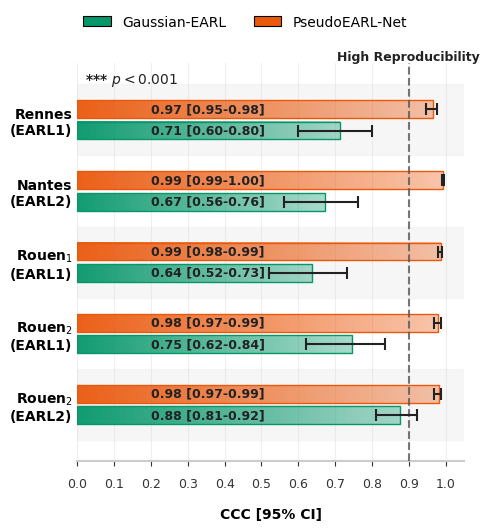

In [69]:
# plot_radiomics_ccc_master(df_centers_calculated, group_by='centers', text_fixed_x=0.2)

plot_radiomics_ccc_master(
    # df_families_calculated, 
    df_centers_calculated,
    group_by='families', 
    text_fixed_x=0.2,
    figsize=(5, 5.5),
    base_fontsize=10,
    bar_width=0.25,
    inter_bar_space=0.05,
    y_margin=0.8
)

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec


# (Garde toujours ta fonction calculate_ccc_and_ci définie ici)

def fetch_radiomics_heatmap_data_per_center(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    # Identification de la colonne de domaine
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    center_configs = [
        {'domain': 'rennes', 'suffix': '1'},
        {'domain': 'nantes', 'suffix': '2'},
        {'domain': 'chb', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '2'}
    ]

    # --- 1. APPARIEMENT STRICT DES PATIENTS ---
    merged_pseudo_list = []
    merged_gauss_list = []
    
    for suffix in ['1', '2']:
        df_gt = df[df['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df[df['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df[df['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        m_pseudo = pd.merge(df_gt, df_pseudo, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred'))
        merged_pseudo_list.append(m_pseudo)
        
        m_gauss = pd.merge(df_gt, df_gauss, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred'))
        merged_gauss_list.append(m_gauss)
        
    merged_pseudo = pd.concat(merged_pseudo_list, ignore_index=True)
    merged_gauss = pd.concat(merged_gauss_list, ignore_index=True)
    
    # --- 2. CALCUL HIÉRARCHIQUE : VOI -> FAMILLE -> FEATURE -> CENTRE ---
    data_list = []
    
    for voi in target_vois:
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        df_voi_pseudo = merged_pseudo[merged_pseudo['VOI'].str.lower() == voi_query]
        df_voi_gauss = merged_gauss[merged_gauss['VOI'].str.lower() == voi_query]
        
        for fam, fam_label in zip(families, family_labels):
            feat_cols = [c for c in df.columns if c.lower().startswith(f'original_{fam}_')]
            
            ccc_pseudo_features = []
            ccc_gauss_features = []
            
            for feat in feat_cols:
                ccc_pseudo_centers = []
                ccc_gauss_centers = []
                
                # ÉTAPE CLÉ : Calcul indépendant pour CHAQUE CENTRE
                for c_cfg in center_configs:
                    c_domain = c_cfg['domain']
                    c_earl = f"earl{c_cfg['suffix']}"
                    
                    # On isole les données de ce centre spécifique
                    subset_pseudo = df_voi_pseudo[(df_voi_pseudo[domain_col].str.lower() == c_domain) & 
                                                  (df_voi_pseudo['Modality_gt'].str.lower() == c_earl)]
                    subset_gauss = df_voi_gauss[(df_voi_gauss[domain_col].str.lower() == c_domain) & 
                                                (df_voi_gauss['Modality_gt'].str.lower() == c_earl)]
                    
                    # CCC PseudoEARL-Net (pour ce centre)
                    if f"{feat}_gt" in subset_pseudo.columns and f"{feat}_pred" in subset_pseudo.columns:
                        gt_vals = subset_pseudo[f"{feat}_gt"].dropna().values
                        pred_vals = subset_pseudo[f"{feat}_pred"].dropna().values
                        
                        if len(gt_vals) >= 3:
                            ccc_p, _, _, _ = calculate_ccc_and_ci(gt_vals, pred_vals)
                            if not np.isnan(ccc_p): ccc_pseudo_centers.append(ccc_p)
                    
                    # CCC Gaussian-EARL (pour ce centre)
                    if f"{feat}_gt" in subset_gauss.columns and f"{feat}_pred" in subset_gauss.columns:
                        gt_vals_g = subset_gauss[f"{feat}_gt"].dropna().values
                        pred_vals_g = subset_gauss[f"{feat}_pred"].dropna().values
                        
                        if len(gt_vals_g) >= 3:
                            ccc_g, _, _, _ = calculate_ccc_and_ci(gt_vals_g, pred_vals_g)
                            if not np.isnan(ccc_g): ccc_gauss_centers.append(ccc_g)
                
                # ÉTAPE CLÉ : On moyenne les centres pour avoir le CCC final de la Feature
                if ccc_pseudo_centers: ccc_pseudo_features.append(np.mean(ccc_pseudo_centers))
                if ccc_gauss_centers: ccc_gauss_features.append(np.mean(ccc_gauss_centers))
            
            # ÉTAPE CLÉ : On moyenne les Features pour avoir le CCC final de la Famille
            data_list.append({
                'Family': fam_label, 
                'VOI': voi.title(),
                'PseudoEARL-Net': np.mean(ccc_pseudo_features) if ccc_pseudo_features else np.nan,
                'Gaussian-EARL': np.mean(ccc_gauss_features) if ccc_gauss_features else np.nan
            })

    df_results = pd.DataFrame(data_list)
    
    # --- 3. CRÉATION DES MATRICES 2D ---
    heatmap_pseudo = df_results.pivot(index='Family', columns='VOI', values='PseudoEARL-Net')
    heatmap_gauss = df_results.pivot(index='Family', columns='VOI', values='Gaussian-EARL')
    
    heatmap_pseudo = heatmap_pseudo.reindex(index=family_labels, columns=[v.title() for v in target_vois])
    heatmap_gauss = heatmap_gauss.reindex(index=family_labels, columns=[v.title() for v in target_vois])
    
    return {'PseudoEARL-Net': heatmap_pseudo, 'Gaussian-EARL': heatmap_gauss}


# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_radiomics_ccc_heatmaps(heatmaps_dict, 
                                figsize=(16, 7), 
                                vmin=0.5,             # Borne basse de la couleur (0.5 ou 0.8 permet d'augmenter le contraste si les valeurs sont toutes > 0.8)
                                vmax=1.0,             # Borne haute (CCC parfait = 1.0)
                                cmap='YlGnBu',        # Dégradé : Jaune -> Vert -> Bleu 
                                annot_fontsize=12,    # Taille de la police du texte DANS les cases
                                wspace_val=0.05,      # Espace entre les deux heatmaps
                                cbar_width=0.03,      # Épaisseur de la barre de couleur (Colorbar)
                                cbar_pad=0.02,        # Espace entre la 2ème heatmap et la barre de couleur
                                linewidths=1.5,       # Épaisseur de la grille blanche entre les cases
                                base_fontsize=14):
    
    sns.set_context("paper", font_scale=1.)
    
    df_pseudo = heatmaps_dict['PseudoEARL-Net']
    df_gauss = heatmaps_dict['Gaussian-EARL']
    
    # --- 1. CRÉATION DE L'ARCHITECTURE (GridSpec) ---
    # On crée 3 colonnes : Heatmap 1, Heatmap 2, et Colorbar
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, width_ratios=[1, 1, cbar_width], wspace=wspace_val)
    
    ax_pseudo = fig.add_subplot(gs[0, 0])
    ax_gauss = fig.add_subplot(gs[0, 1])
    ax_cbar = fig.add_subplot(gs[0, 2])
    
    # --- 2. CONFIGURATION DES ANNOTATIONS ---
    annot_kws = {'fontsize': annot_fontsize, 'fontweight': 'bold'}
    
    # --- 3. TRACÉ DES HEATMAPS ---
    # Heatmap 1 : PseudoEARL-Net (Pas de cbar affichée ici)
    sns.heatmap(df_pseudo, ax=ax_pseudo, vmin=vmin, vmax=vmax, cmap=cmap, 
                annot=True, fmt='.2f', annot_kws=annot_kws, cbar=False,
                linewidths=linewidths, linecolor='white', square=True)
    
    # Heatmap 2 : Gaussian-EARL (La cbar est déportée sur ax_cbar)
    sns.heatmap(df_gauss, ax=ax_gauss, vmin=vmin, vmax=vmax, cmap=cmap, 
                annot=True, fmt='.2f', annot_kws=annot_kws, 
                cbar=True, cbar_ax=ax_cbar,
                linewidths=linewidths, linecolor='white', square=True)
    
    # --- 4. ESTHÉTIQUE DES AXES & TITRES ---
    panels = [
        {'ax': ax_pseudo, 'title': 'PseudoEARL-Net', 'show_ylabel': True},
        {'ax': ax_gauss, 'title': 'Gaussian-EARL', 'show_ylabel': False}
    ]
    
    for panel in panels:
        ax = panel['ax']
        
        # Titre
        ax.set_title(panel['title'], fontweight='bold', pad=15, fontsize=base_fontsize + 1)
        
        # Axe X (VOIs)
        # ax.set_xlabel("Volume of Interest (VOI)", fontweight='bold', labelpad=12, fontsize=base_fontsize)
        ax.set_xlabel("")
        ax.xaxis.set_tick_params(labelsize=base_fontsize - 1, labelrotation=0, colors='#333333')
        
        # Axe Y (Familles)
        if panel['show_ylabel']:
            ax.set_ylabel("Radiomics Feature Family", fontweight='bold', labelpad=12, fontsize=base_fontsize)
            ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, labelrotation=0, colors='#333333')
        else:
            ax.set_ylabel("")
            ax.set_yticks([]) # Efface les ticks sur la 2ème heatmap pour que les 2 se "collent" proprement
            
        # On supprime les bordures noires disgracieuses autour de la heatmap
        for _, spine in ax.spines.items():
            spine.set_visible(False)

    # --- 5. ESTHÉTIQUE DE LA BARRE DE COULEUR ---
    ax_cbar.set_ylabel("CCC", fontweight='bold', labelpad=15, fontsize=base_fontsize)
    ax_cbar.yaxis.set_tick_params(labelsize=base_fontsize - 1)
    
    # Ajustement pour décoller la colorbar de la heatmap 2
    pos = ax_cbar.get_position()
    pos.x0 += cbar_pad
    pos.x1 += cbar_pad
    ax_cbar.set_position(pos)

    # Titre Global (Optionnel, au choix)
    # plt.suptitle("Radiomics Reproducibility (CCC) vs EARL Target", fontweight='bold', fontsize=base_fontsize + 3, y=1.02)
    
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
# df_clone = master_df[master_df['Domain'].str.lower().isin(['nantes'])].copy()
# matrices_dict_strict = fetch_radiomics_heatmap_data_strict(df_clone)
matrices_dict = fetch_radiomics_heatmap_data_per_center(master_df)

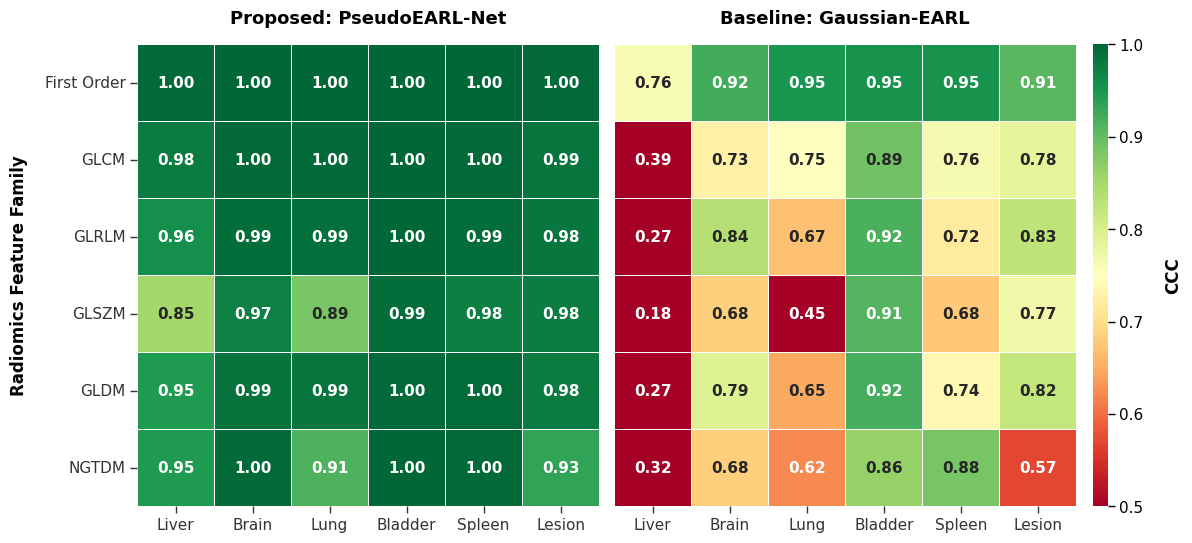

In [69]:
# Étape B : On affiche
# Si tes CCC sont tous très bons (ex: > 0.7), monte le vmin à 0.7 ! 
# Cela augmentera le contraste des couleurs.
#
plot_radiomics_ccc_heatmaps(
    matrices_dict, 
    vmin=0.2, 
    vmax=1.0, 
    cmap='RdYlGn',  # Dégradé : Rouge -> Jaune -> Vert
    wspace_val=0.00,  # Rapproche les deux blocs
    linewidths=0.5,
    figsize=(12.5, 6),
    annot_fontsize=11,
    base_fontsize=12,
    cbar_width=0.03,
    cbar_pad=0.0075
)

In [102]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings

# Désactive les warnings pandas sur les copies de DataFrame
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. FONCTION DE CALCUL DU CCC
# ==============================================================================
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None


# ==============================================================================
# 2. PRÉPARATION DES DONNÉES (Gère les composantes multiples et les NaN)
# ==============================================================================
def fetch_comprehensive_dual_heatmap_data(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    
    center_configs = [
        {'label': 'Rennes_EARL1', 'domain': 'rennes', 'suffix': '1'},
        {'label': 'Nantes_EARL2', 'domain': 'nantes', 'suffix': '2'},
        {'label': 'Rouen1_EARL1', 'domain': 'chb', 'suffix': '1'},
        {'label': 'Rouen2_EARL1', 'domain': 'a100', 'suffix': '1'},
        {'label': 'Rouen2_EARL2', 'domain': 'a100', 'suffix': '2'}
    ]
    
    df_work = df.copy()
    domain_col = 'Domain_Source' if 'Domain_Source' in df_work.columns else 'Domain'
    
    # --- FIX 1 : Gestion robuste du Component ---
    for comp_col in ['Component', 'component']:
        if comp_col in df_work.columns:
            df_work[comp_col] = df_work[comp_col].fillna(-1)
            
    if 'Component' not in df_work.columns and 'component' not in df_work.columns:
        df_work['Component'] = -1
        
    merge_keys = [col for col in ['Subject_ID', 'VOI', domain_col, 'Component', 'component'] if col in df_work.columns]
    
    merged_pseudo_list, merged_gauss_list = [], []
    for suffix in ['1', '2']:
        df_gt = df_work[df_work['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df_work[df_work['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df_work[df_work['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        if not df_gt.empty and not df_pseudo.empty:
            merged_pseudo_list.append(pd.merge(df_gt, df_pseudo, on=merge_keys, suffixes=('_gt', '_pred')))
        if not df_gt.empty and not df_gauss.empty:
            merged_gauss_list.append(pd.merge(df_gt, df_gauss, on=merge_keys, suffixes=('_gt', '_pred')))
        
    merged_p = pd.concat(merged_pseudo_list, ignore_index=True) if merged_pseudo_list else pd.DataFrame()
    merged_g = pd.concat(merged_gauss_list, ignore_index=True) if merged_gauss_list else pd.DataFrame()
    
    # --- FIX 2 : Exclusion stricte de COV, RobustCOV et Shape ---
    excluded_keywords = ['cov', 'robustcov']
    all_features = [
        c for c in df_work.columns 
        if c.startswith('original_') 
        and 'shape' not in c.lower() 
        and not any(excl in c.lower() for excl in excluded_keywords)
    ]
    
    data_list = []
    
    for voi in target_vois:
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        if not merged_p.empty: df_v_p = merged_p[merged_p['VOI'].str.lower() == voi_query]
        else: df_v_p = pd.DataFrame()
            
        if not merged_g.empty: df_v_g = merged_g[merged_g['VOI'].str.lower() == voi_query]
        else: df_v_g = pd.DataFrame()
        
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            col_x_name = f"{voi.title()}_{c_label}"
            
            sub_p = df_v_p[(df_v_p[domain_col].str.lower() == c_cfg['domain']) & (df_v_p['Modality_gt'].str.lower() == f"earl{c_cfg['suffix']}")]
            sub_g = df_v_g[(df_v_g[domain_col].str.lower() == c_cfg['domain']) & (df_v_g['Modality_gt'].str.lower() == f"earl{c_cfg['suffix']}")]
            
            for feat in all_features:
                family = feat.split('_')[1]
                feature_display = feat.replace('original_', '')
                
                ccc_p, ccc_g = np.nan, np.nan
                
                # --- FIX 3 : Dropna symétrique pour garantir un alignement parfait des paires ---
                if f"{feat}_gt" in sub_p.columns and f"{feat}_pred" in sub_p.columns:
                    valid_mask_p = sub_p[f"{feat}_gt"].notna() & sub_p[f"{feat}_pred"].notna()
                    gt_p = sub_p.loc[valid_mask_p, f"{feat}_gt"].values
                    pred_p = sub_p.loc[valid_mask_p, f"{feat}_pred"].values
                    if len(gt_p) >= 3: ccc_p, _, _, _ = calculate_ccc_and_ci(gt_p, pred_p)
                        
                if f"{feat}_gt" in sub_g.columns and f"{feat}_pred" in sub_g.columns:
                    valid_mask_g = sub_g[f"{feat}_gt"].notna() & sub_g[f"{feat}_pred"].notna()
                    gt_g = sub_g.loc[valid_mask_g, f"{feat}_gt"].values
                    pred_g = sub_g.loc[valid_mask_g, f"{feat}_pred"].values
                    if len(gt_g) >= 3: ccc_g, _, _, _ = calculate_ccc_and_ci(gt_g, pred_g)
                
                data_list.append({
                    'Family': family, 'Feature_Y': feature_display, 'VOI_Center_X': col_x_name,
                    'CCC_Pseudo': ccc_p, 'CCC_Gauss': ccc_g
                })

    df_res = pd.DataFrame(data_list)
    matrix_p = df_res.pivot(index=['Family', 'Feature_Y'], columns='VOI_Center_X', values='CCC_Pseudo').sort_index(axis=1).reindex(families, level=0)
    matrix_g = df_res.pivot(index=['Family', 'Feature_Y'], columns='VOI_Center_X', values='CCC_Gauss').sort_index(axis=1).reindex(families, level=0)
    
    return {'PseudoEARL-Net': matrix_p, 'Gaussian-EARL': matrix_g}


# ==============================================================================
# 3. TRACÉ DE LA HEATMAP
# ==============================================================================
def plot_dual_comprehensive_heatmap(matrices_dict, 
                                    figsize=None,          
                                    cell_width=0.3,        
                                    cell_height=0.18,      
                                    gap_between_families=0.08, 
                                    wspace_val=0.03,       
                                    label_fontsize=9,      
                                    title_fontsize=14,
                                    show_annotations=False,
                                    save_path=None):
    
    plt.style.use('default')
    
    matrix_p = matrices_dict['PseudoEARL-Net']
    matrix_g = matrices_dict['Gaussian-EARL']
    
    bounds = [-1.0, 0.6, 0.75, 0.9, 1.0] 
    colors = ['#dc2626', '#ea580c', '#facc15', '#16a34a'] 
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    families = matrix_p.index.get_level_values(0).unique()
    num_cols = matrix_p.shape[1]
    
    if figsize is None:
        total_height = (matrix_p.shape[0] * cell_height) + (len(families) * gap_between_families)
        total_width = (num_cols * cell_width) * 2 
        fig_width = total_width + 6.0  
        fig_height = total_height + 4.0
    else:
        fig_width, fig_height = figsize
        
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    height_ratios = [len(matrix_p.loc[fam]) for fam in families]
    gs = GridSpec(len(families), 2, height_ratios=height_ratios, hspace=gap_between_families, wspace=wspace_val)
    
    for i, fam in enumerate(families):
        ax_p = fig.add_subplot(gs[i, 0])
        ax_g = fig.add_subplot(gs[i, 1])
        
        df_fam_p = matrix_p.loc[fam]
        df_fam_g = matrix_g.loc[fam]
        
        sns.heatmap(df_fam_p, ax=ax_p, cmap=cmap, norm=norm, cbar=False, annot=show_annotations, square=False, linewidths=0.5, linecolor='white')
        sns.heatmap(df_fam_g, ax=ax_g, cmap=cmap, norm=norm, cbar=False, annot=show_annotations, square=False, linewidths=0.5, linecolor='white')
        
        if i == 0:
            ax_p.set_title("Proposed: PseudoEARL-Net", fontweight='bold', pad=15, fontsize=title_fontsize)
            ax_g.set_title("Baseline: Gaussian-EARL", fontweight='bold', pad=15, fontsize=title_fontsize)
            
        ax_p.set_ylabel("")
        ax_g.set_ylabel("")
        ax_g.set_yticks([]) 
        
        ax_p.set_yticks(np.arange(len(df_fam_p.index)) + 0.5)
        ax_p.set_yticklabels(df_fam_p.index, rotation=0, fontsize=label_fontsize, fontweight='normal', color="#333333")
        
        ax_p.set_xlabel("")
        ax_g.set_xlabel("")
        
        if i == len(families) - 1: 
            ax_p.set_xticks(np.arange(len(df_fam_p.columns)) + 0.5)
            ax_g.set_xticks(np.arange(len(df_fam_g.columns)) + 0.5)
            
            ax_p.set_xticklabels(df_fam_p.columns, rotation=90, fontsize=label_fontsize, fontweight='normal', color="#333333")
            ax_g.set_xticklabels(df_fam_g.columns, rotation=90, fontsize=label_fontsize, fontweight='normal', color="#333333")
            
            ax_p.xaxis.set_tick_params(pad=5)
            ax_g.xaxis.set_tick_params(pad=5)
        else:
            ax_p.set_xticks([])
            ax_g.set_xticks([])
            
        for spine in list(ax_p.spines.values()) + list(ax_g.spines.values()):
            spine.set_visible(False)

    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='black', linewidth=0.5, label='CCC $\geq$ 0.90'),
        Patch(facecolor='#facc15', edgecolor='black', linewidth=0.5, label='0.75 $\leq$ CCC < 0.90'),
        Patch(facecolor='#ea580c', edgecolor='black', linewidth=0.5, label='0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='black', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.97), 
               ncol=4, frameon=False, fontsize=title_fontsize - 1)
    
    plt.subplots_adjust(bottom=0.18, top=0.91, left=0.20, right=0.98)
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


ccc_matrices = fetch_comprehensive_dual_heatmap_data(master_df)


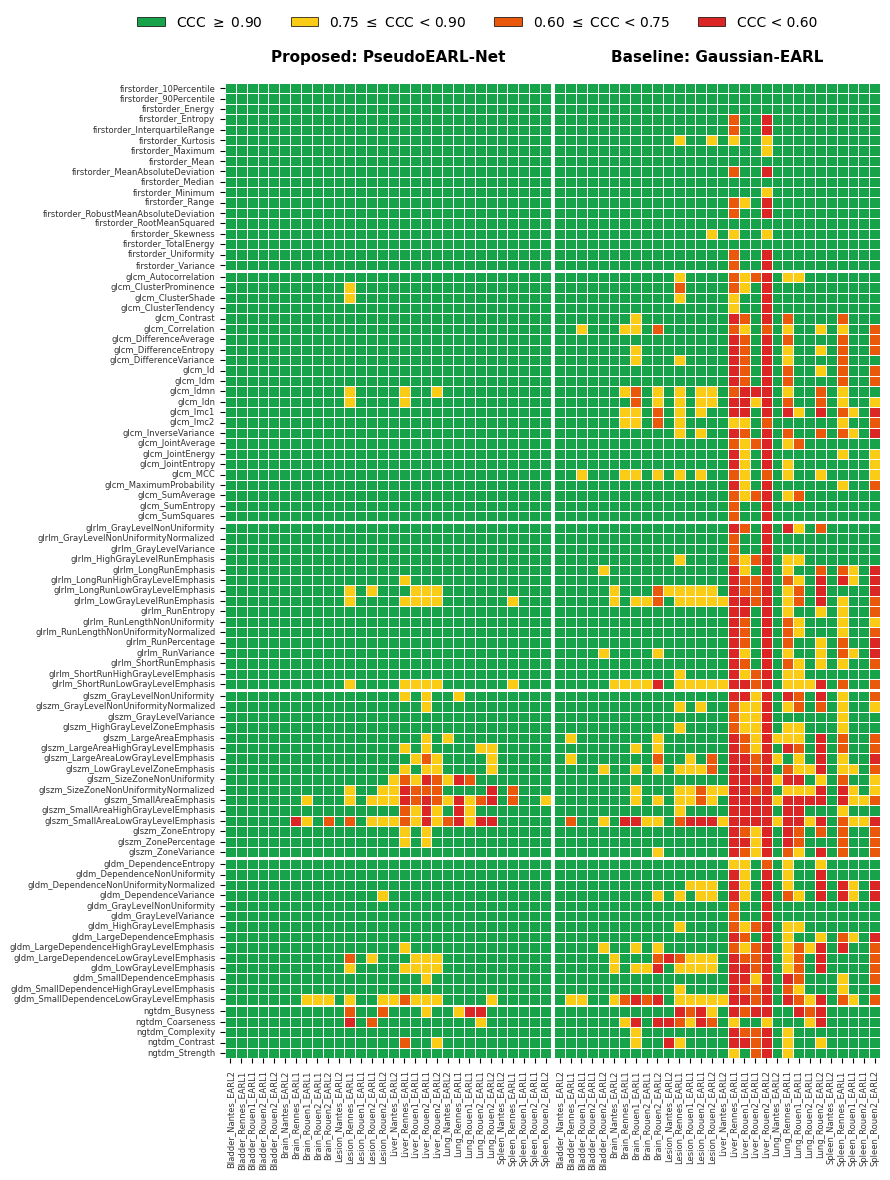

In [74]:
plot_dual_comprehensive_heatmap(
    ccc_matrices,
    cell_width=0.04,        
    cell_height=0.1,       
    gap_between_families=0.01,
    wspace_val=0.01,       
    label_fontsize=6,
    title_fontsize=11,
    save_path="full_radiomics_ccc_dual_heatmap.svg"
)

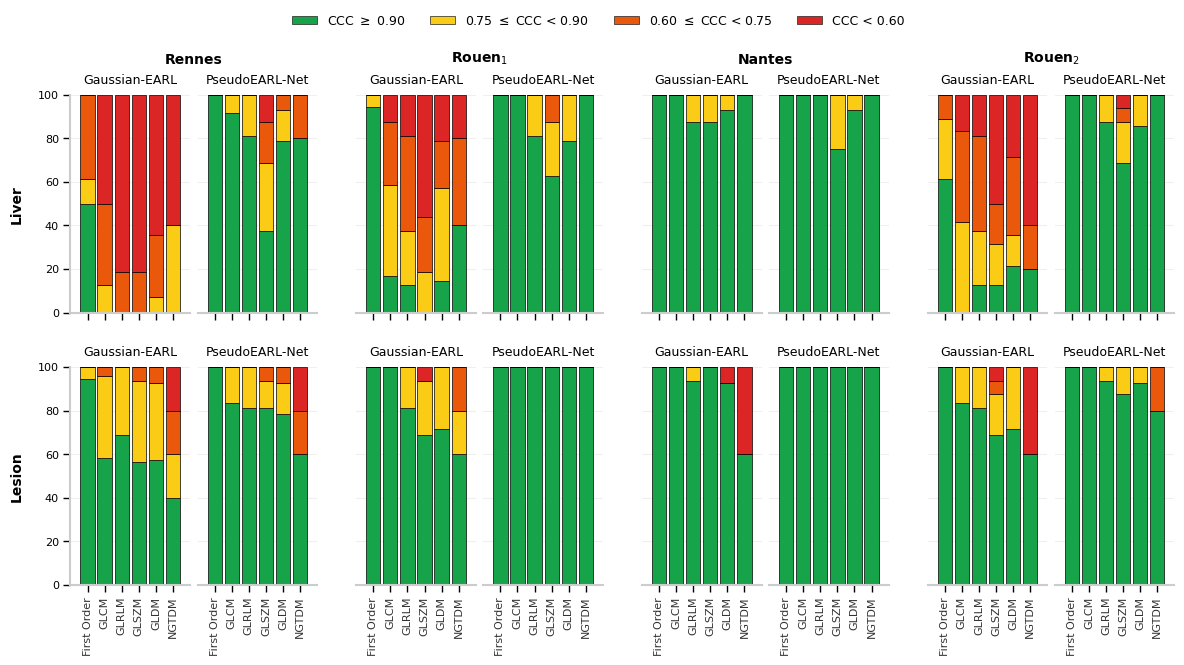

In [90]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

# --- Fonction de calcul CCC ---
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None


# ==============================================================================
# 1. PRÉPARATION ET CALCUL DES DONNÉES
# ==============================================================================
def fetch_multicenter_8x2_reproducibility_data(df, target_vois=['Liver', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    df_work = df.copy()
    domain_col = 'Domain_Source' if 'Domain_Source' in df_work.columns else 'Domain'
    
    # --- FIX 1 : Gestion robuste du Component ---
    for comp_col in ['Component', 'component']:
        if comp_col in df_work.columns:
            df_work[comp_col] = df_work[comp_col].fillna(-1)
            
    if 'Component' not in df_work.columns and 'component' not in df_work.columns:
        df_work['Component'] = -1
        
    merge_keys = [col for col in ['Subject_ID', 'VOI', domain_col, 'Component', 'component'] if col in df_work.columns]
    
    # --- 1. PRÉ-FUSION STRICTE PAR STANDARD ---
    merged_pseudo_list, merged_gauss_list = [], []
    for suffix in ['1', '2']:
        df_gt = df_work[df_work['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df_work[df_work['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df_work[df_work['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        if not df_gt.empty and not df_pseudo.empty:
            merged_pseudo_list.append(pd.merge(df_gt, df_pseudo, on=merge_keys, suffixes=('_gt', '_pred')))
        if not df_gt.empty and not df_gauss.empty:
            merged_gauss_list.append(pd.merge(df_gt, df_gauss, on=merge_keys, suffixes=('_gt', '_pred')))
            
    merged_p = pd.concat(merged_pseudo_list, ignore_index=True) if merged_pseudo_list else pd.DataFrame()
    merged_g = pd.concat(merged_gauss_list, ignore_index=True) if merged_gauss_list else pd.DataFrame()
    
    # --- FIX 2 : Exclusion stricte de COV, RobustCOV et Shape ---
    excluded_keywords = ['cov', 'robustcov']
    all_features = [
        c for c in df_work.columns 
        if c.startswith('original_') 
        and 'shape' not in c.lower() 
        and not any(excl in c.lower() for excl in excluded_keywords)
    ]
    
    center_configs = [
        {'label': 'Rennes', 'domain': 'rennes'},
        {'label': 'Rouen$_1$', 'domain': 'chb'},
        {'label': 'Nantes', 'domain': 'nantes'},
        {'label': 'Rouen$_2$', 'domain': 'a100'} 
    ]
    
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    # Dictionnaire de stockage: {VOI: {Center: {Method: {Feature: CCC_Value}}}}
    ccc_store = {v.capitalize(): {c['label']: {m: {} for m in methods} for c in center_configs} for v in target_vois}
    
    # --- 2. CALCUL DES CCC INDÉPENDANTS ---
    for voi in target_vois:
        v_key = voi.capitalize()
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        if not merged_p.empty: df_v_p = merged_p[merged_p['VOI'].str.lower() == voi_query]
        else: df_v_p = pd.DataFrame()
            
        if not merged_g.empty: df_v_g = merged_g[merged_g['VOI'].str.lower() == voi_query]
        else: df_v_g = pd.DataFrame()
        
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            c_domain = c_cfg['domain']
            
            sub_p = df_v_p[df_v_p[domain_col].str.lower() == c_domain]
            sub_g = df_v_g[df_v_g[domain_col].str.lower() == c_domain]
            
            for feat in all_features:
                col_gt, col_pred = f"{feat}_gt", f"{feat}_pred"
                
                # --- FIX 3 : Dropna symétrique pour un alignement parfait ---
                if col_gt in sub_p.columns and col_pred in sub_p.columns:
                    valid_mask_p = sub_p[col_gt].notna() & sub_p[col_pred].notna()
                    gt = sub_p.loc[valid_mask_p, col_gt].values
                    pred = sub_p.loc[valid_mask_p, col_pred].values
                    
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['PseudoEARL-Net'][feat] = ccc
                        
                if col_gt in sub_g.columns and col_pred in sub_g.columns:
                    valid_mask_g = sub_g[col_gt].notna() & sub_g[col_pred].notna()
                    gt = sub_g.loc[valid_mask_g, col_gt].values
                    pred = sub_g.loc[valid_mask_g, col_pred].values
                    
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['Gaussian-EARL'][feat] = ccc

    # --- 3. AGRÉGATION EN PROPORTIONS ---
    final_data = []
    for voi in target_vois:
        v_key = voi.capitalize()
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            for m in methods:
                for fam, fam_label in zip(families, family_labels):
                    fam_features = [f for f in all_features if f.split('_')[1] == fam]
                    
                    excellent, good, moderate, mediocre = 0, 0, 0, 0
                    total_valid = 0
                    
                    for feat in fam_features:
                        if feat in ccc_store[v_key][c_label][m]:
                            ccc_val = ccc_store[v_key][c_label][m][feat]
                            total_valid += 1
                            if ccc_val >= 0.90: excellent += 1
                            elif ccc_val >= 0.75: good += 1
                            elif ccc_val >= 0.60: moderate += 1
                            else: mediocre += 1
                            
                    if total_valid > 0:
                        final_data.append({
                            'VOI': v_key, 'Center': c_label, 'Method': m, 'Family': fam_label,
                            'Excellent': (excellent / total_valid) * 100,
                            'Good': (good / total_valid) * 100,
                            'Moderate': (moderate / total_valid) * 100,
                            'Mediocre': (mediocre / total_valid) * 100
                        })
                        
    return pd.DataFrame(final_data)


# ==============================================================================
# 2. TRACÉ DES BARRES EMPILÉES
# ==============================================================================
plt.style.use('default')

def plot_multicenter_8x2_stacked_bars(df_plot, 
                                      target_vois=['Liver', 'Lesion'],
                                      figsize=(22, 10),
                                      wspace_intra_group=0.08,    
                                      wspace_inter_group=0.5,    
                                      hspace=0.35,                
                                      top_margin=0.85,
                                      bottom_margin=0.15,
                                      left_margin=0.06,
                                      right_margin=0.98,
                                      bar_width=0.25,            
                                      gap_between_bars=0.05,    
                                      bar_edgecolor='black',
                                      bar_linewidth=0.3,
                                      center_title_fontsize=15,
                                      method_title_fontsize=11,
                                      row_title_fontsize=16,
                                      label_fontsize=10,
                                      legend_fontsize=12,
                                      x_label_rotation=90):
    
    sns.set_context("paper", font_scale=1.1)
    fig = plt.figure(figsize=figsize)
    
    width_ratios = [1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1]
    gs = gridspec.GridSpec(len(target_vois), 11, width_ratios=width_ratios, wspace=wspace_intra_group, hspace=hspace, 
                           top=top_margin, bottom=bottom_margin, left=left_margin, right=right_margin)
    
    centers = ['Rennes', 'Rouen$_1$', 'Nantes', 'Rouen$_2$']
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    tiers = ['Excellent', 'Good', 'Moderate', 'Mediocre']
    colors = ['#16a34a', '#facc15', '#ea580c', '#dc2626'] 
    
    x_step = bar_width + gap_between_bars
    
    for row_idx, voi in enumerate(target_vois):
        for col_idx, center in enumerate(centers):
            
            base_grid_idx = col_idx * 3 
            
            for m_idx, method in enumerate(methods):
                grid_pos = base_grid_idx + m_idx
                ax = fig.add_subplot(gs[row_idx, grid_pos])
                
                df_sub = df_plot[(df_plot['VOI'] == voi.capitalize()) & (df_plot['Center'] == center) & (df_plot['Method'] == method)]
                
                if df_sub.empty:
                    ax.axis('off')
                    continue
                    
                x_labels = df_sub['Family'].tolist()
                x = np.arange(len(x_labels)) * x_step
                bottom = np.zeros(len(x_labels))
                
                for tier, color in zip(tiers, colors):
                    values = df_sub[tier].values
                    ax.bar(x, values, bottom=bottom, color=color, 
                           edgecolor=bar_edgecolor, width=bar_width, linewidth=bar_linewidth)
                    bottom += values 
                
                ax.set_title(method, fontweight='normal', pad=8, fontsize=method_title_fontsize)
                ax.set_xlim(-x_step, x[-1] + x_step)
                ax.set_ylim(0, 100)
                
                ax.set_xticks(x)
                if row_idx == len(target_vois) - 1:
                    ax.set_xticklabels(x_labels, rotation=x_label_rotation, fontsize=label_fontsize, color="#333333")
                else:
                    ax.set_xticklabels([])
                
                if grid_pos == 0:
                    ax.set_ylabel(f"{voi.capitalize()}", fontweight='bold', labelpad=10, fontsize=label_fontsize + 2)
                    ax.tick_params(axis='y', labelsize=label_fontsize)
                else:
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', length=0) 
                    
                sns.despine(ax=ax, top=True, right=True, left=(grid_pos != 0))
                
                if grid_pos == 0:
                    ax.spines['left'].set_linewidth(1.5)
                    ax.spines['left'].set_color('#cccccc')
                    
                ax.spines['bottom'].set_linewidth(1.5)
                ax.spines['bottom'].set_color('#cccccc')
                
                ax.set_axisbelow(True)
                ax.yaxis.grid(True, linestyle='-', alpha=0.3, color='#cccccc')
                ax.xaxis.grid(False)
                
                if row_idx == 0 and m_idx == 1: 
                    pos_left = fig.axes[-2].get_position()
                    pos_right = ax.get_position()
                    mid_x = (pos_left.x0 + pos_right.x1) / 2
                    
                    fig.text(mid_x, pos_left.y1 + 0.04, center, ha='center', va='bottom', 
                             fontweight='bold', fontsize=center_title_fontsize)

    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='#222222', linewidth=0.5, label='CCC $\geq$ 0.90'),
        Patch(facecolor='#facc15', edgecolor='#222222', linewidth=0.5, label=r'0.75 $\leq$ CCC < 0.90'),
        Patch(facecolor='#ea580c', edgecolor='#222222', linewidth=0.5, label=r'0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='#222222', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, top_margin + 0.08), 
               ncol=4, frameon=False, fontsize=legend_fontsize)
    
    plt.savefig("multicenter_8x2_stacked_bars.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 3. EXÉCUTION
# ==============================================================================

# Calcul (avec le merge sécurisé et dropna symétrique)
df_stacked_8x2 = fetch_multicenter_8x2_reproducibility_data(master_df, target_vois=['Liver', 'Lesion'])

# Tracé
plot_multicenter_8x2_stacked_bars(
    df_plot=df_stacked_8x2,
    target_vois=['Liver', 'Lesion'],
    
    figsize=(12, 7),
    
    wspace_intra_group=0.08,    
    wspace_inter_group=0.2,    
    hspace=0.25,                
    
    top_margin=0.85,            
    bottom_margin=0.15,         
    left_margin=0.06,           
    right_margin=0.98,
    
    bar_width=0.25,            
    gap_between_bars=0.05,      
    bar_edgecolor='black',
    bar_linewidth=0.5,
    
    center_title_fontsize=10,
    method_title_fontsize=9,
    row_title_fontsize=11,
    label_fontsize=8,
    legend_fontsize=9,
    x_label_rotation=90,
)

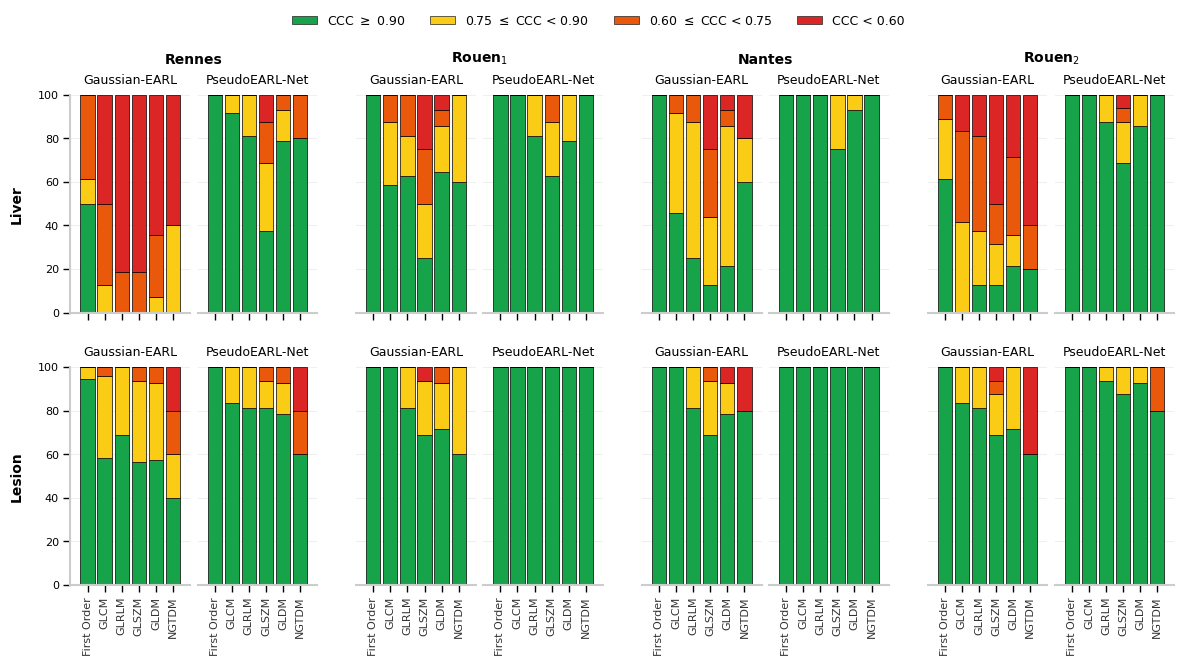

In [104]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

# --- Fonction de calcul CCC ---
def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true, y_pred = np.asarray(y_true, dtype=float).flatten(), np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    if N < 3: return np.nan, np.nan, np.nan, np.nan
    if np.var(y_true) == 0 and np.var(y_pred) == 0: return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc): return np.nan, np.nan, np.nan, np.nan
    ccc = np.clip(ccc, -1.0, 1.0)
    if ccc == 1.0: return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    return ccc, np.tanh(z - z_critical * se), np.tanh(z + z_critical * se), None


# ==============================================================================
# 1. PRÉPARATION ET CALCUL DES DONNÉES
# ==============================================================================
def fetch_multicenter_8x2_reproducibility_data(df, target_vois=['Liver', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    df_work = df.copy()
    domain_col = 'Domain_Source' if 'Domain_Source' in df_work.columns else 'Domain'
    
    # --- FIX 1 : Gestion robuste du Component ---
    for comp_col in ['Component', 'component']:
        if comp_col in df_work.columns:
            df_work[comp_col] = df_work[comp_col].fillna(-1)
            
    if 'Component' not in df_work.columns and 'component' not in df_work.columns:
        df_work['Component'] = -1
        
    merge_keys = [col for col in ['Subject_ID', 'VOI', domain_col, 'Component', 'component'] if col in df_work.columns]
    
    # --- 1. PRÉ-FUSION STRICTE PAR STANDARD ---
    merged_pseudo_list, merged_gauss_list = [], []
    for suffix in ['1', '2']:
        df_gt = df_work[df_work['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df_work[df_work['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df_work[df_work['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        if not df_gt.empty and not df_pseudo.empty:
            merged_pseudo_list.append(pd.merge(df_gt, df_pseudo, on=merge_keys, suffixes=('_gt', '_pred')))
        if not df_gt.empty and not df_gauss.empty:
            merged_gauss_list.append(pd.merge(df_gt, df_gauss, on=merge_keys, suffixes=('_gt', '_pred')))
            
    merged_p = pd.concat(merged_pseudo_list, ignore_index=True) if merged_pseudo_list else pd.DataFrame()
    merged_g = pd.concat(merged_gauss_list, ignore_index=True) if merged_gauss_list else pd.DataFrame()
    
    # --- FIX 2 : Exclusion stricte de COV, RobustCOV et Shape ---
    excluded_keywords = ['cov', 'robustcov']
    all_features = [
        c for c in df_work.columns 
        if c.startswith('original_') 
        and 'shape' not in c.lower() 
        and not any(excl in c.lower() for excl in excluded_keywords)
    ]
    
    center_configs = [
        {'label': 'Rennes', 'domain': 'rennes'},
        {'label': 'Rouen$_1$', 'domain': 'chb'},
        {'label': 'Nantes', 'domain': 'nantes'},
        {'label': 'Rouen$_2$', 'domain': 'a100'} 
    ]
    
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    # Dictionnaire de stockage: {VOI: {Center: {Method: {Feature: CCC_Value}}}}
    ccc_store = {v.capitalize(): {c['label']: {m: {} for m in methods} for c in center_configs} for v in target_vois}
    
    # --- 2. CALCUL DES CCC INDÉPENDANTS ---
    for voi in target_vois:
        v_key = voi.capitalize()
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        if not merged_p.empty: df_v_p = merged_p[merged_p['VOI'].str.lower() == voi_query]
        else: df_v_p = pd.DataFrame()
            
        if not merged_g.empty: df_v_g = merged_g[merged_g['VOI'].str.lower() == voi_query]
        else: df_v_g = pd.DataFrame()
        
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            c_domain = c_cfg['domain']
            
            sub_p = df_v_p[df_v_p[domain_col].str.lower() == c_domain]
            sub_g = df_v_g[df_v_g[domain_col].str.lower() == c_domain]
            
            for feat in all_features:
                col_gt, col_pred = f"{feat}_gt", f"{feat}_pred"
                
                # --- FIX 3 : Dropna symétrique pour un alignement parfait ---
                if col_gt in sub_p.columns and col_pred in sub_p.columns:
                    valid_mask_p = sub_p[col_gt].notna() & sub_p[col_pred].notna()
                    gt = sub_p.loc[valid_mask_p, col_gt].values
                    pred = sub_p.loc[valid_mask_p, col_pred].values
                    
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['PseudoEARL-Net'][feat] = ccc
                        
                if col_gt in sub_g.columns and col_pred in sub_g.columns:
                    valid_mask_g = sub_g[col_gt].notna() & sub_g[col_pred].notna()
                    gt = sub_g.loc[valid_mask_g, col_gt].values
                    pred = sub_g.loc[valid_mask_g, col_pred].values
                    
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['Gaussian-EARL'][feat] = ccc

    # --- 3. AGRÉGATION EN PROPORTIONS ---
    final_data = []
    for voi in target_vois:
        v_key = voi.capitalize()
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            for m in methods:
                for fam, fam_label in zip(families, family_labels):
                    fam_features = [f for f in all_features if f.split('_')[1] == fam]
                    
                    excellent, good, moderate, mediocre = 0, 0, 0, 0
                    total_valid = 0
                    
                    for feat in fam_features:
                        if feat in ccc_store[v_key][c_label][m]:
                            ccc_val = ccc_store[v_key][c_label][m][feat]
                            total_valid += 1
                            if ccc_val >= 0.90: excellent += 1
                            elif ccc_val >= 0.75: good += 1
                            elif ccc_val >= 0.60: moderate += 1
                            else: mediocre += 1
                            
                    if total_valid > 0:
                        final_data.append({
                            'VOI': v_key, 'Center': c_label, 'Method': m, 'Family': fam_label,
                            'Excellent': (excellent / total_valid) * 100,
                            'Good': (good / total_valid) * 100,
                            'Moderate': (moderate / total_valid) * 100,
                            'Mediocre': (mediocre / total_valid) * 100
                        })
                        
    return pd.DataFrame(final_data)


# ==============================================================================
# 2. TRACÉ DES BARRES EMPILÉES
# ==============================================================================
plt.style.use('default')

def plot_multicenter_8x2_stacked_bars(df_plot, 
                                      target_vois=['Liver', 'Lesion'],
                                      figsize=(22, 10),
                                      wspace_intra_group=0.08,    
                                      wspace_inter_group=0.5,    
                                      hspace=0.35,                
                                      top_margin=0.85,
                                      bottom_margin=0.15,
                                      left_margin=0.06,
                                      right_margin=0.98,
                                      bar_width=0.25,            
                                      gap_between_bars=0.05,    
                                      bar_edgecolor='black',
                                      bar_linewidth=0.3,
                                      center_title_fontsize=15,
                                      method_title_fontsize=11,
                                      row_title_fontsize=16,
                                      label_fontsize=10,
                                      legend_fontsize=12,
                                      x_label_rotation=90):
    
    sns.set_context("paper", font_scale=1.1)
    fig = plt.figure(figsize=figsize)
    
    width_ratios = [1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1]
    gs = gridspec.GridSpec(len(target_vois), 11, width_ratios=width_ratios, wspace=wspace_intra_group, hspace=hspace, 
                           top=top_margin, bottom=bottom_margin, left=left_margin, right=right_margin)
    
    centers = ['Rennes', 'Rouen$_1$', 'Nantes', 'Rouen$_2$']
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    tiers = ['Excellent', 'Good', 'Moderate', 'Mediocre']
    colors = ['#16a34a', '#facc15', '#ea580c', '#dc2626'] 
    
    x_step = bar_width + gap_between_bars
    
    for row_idx, voi in enumerate(target_vois):
        for col_idx, center in enumerate(centers):
            
            base_grid_idx = col_idx * 3 
            
            for m_idx, method in enumerate(methods):
                grid_pos = base_grid_idx + m_idx
                ax = fig.add_subplot(gs[row_idx, grid_pos])
                
                df_sub = df_plot[(df_plot['VOI'] == voi.capitalize()) & (df_plot['Center'] == center) & (df_plot['Method'] == method)]
                
                if df_sub.empty:
                    ax.axis('off')
                    continue
                    
                x_labels = df_sub['Family'].tolist()
                x = np.arange(len(x_labels)) * x_step
                bottom = np.zeros(len(x_labels))
                
                for tier, color in zip(tiers, colors):
                    values = df_sub[tier].values
                    ax.bar(x, values, bottom=bottom, color=color, 
                           edgecolor=bar_edgecolor, width=bar_width, linewidth=bar_linewidth)
                    bottom += values 
                
                ax.set_title(method, fontweight='normal', pad=8, fontsize=method_title_fontsize)
                ax.set_xlim(-x_step, x[-1] + x_step)
                ax.set_ylim(0, 100)
                
                ax.set_xticks(x)
                if row_idx == len(target_vois) - 1:
                    ax.set_xticklabels(x_labels, rotation=x_label_rotation, fontsize=label_fontsize, color="#333333")
                else:
                    ax.set_xticklabels([])
                
                if grid_pos == 0:
                    ax.set_ylabel(f"{voi.capitalize()}", fontweight='bold', labelpad=10, fontsize=label_fontsize + 2)
                    ax.tick_params(axis='y', labelsize=label_fontsize)
                else:
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', length=0) 
                    
                sns.despine(ax=ax, top=True, right=True, left=(grid_pos != 0))
                
                if grid_pos == 0:
                    ax.spines['left'].set_linewidth(1.5)
                    ax.spines['left'].set_color('#cccccc')
                    
                ax.spines['bottom'].set_linewidth(1.5)
                ax.spines['bottom'].set_color('#cccccc')
                
                ax.set_axisbelow(True)
                ax.yaxis.grid(True, linestyle='-', alpha=0.3, color='#cccccc')
                ax.xaxis.grid(False)
                
                if row_idx == 0 and m_idx == 1: 
                    pos_left = fig.axes[-2].get_position()
                    pos_right = ax.get_position()
                    mid_x = (pos_left.x0 + pos_right.x1) / 2
                    
                    fig.text(mid_x, pos_left.y1 + 0.04, center, ha='center', va='bottom', 
                             fontweight='bold', fontsize=center_title_fontsize)

    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='#222222', linewidth=0.5, label='CCC $\geq$ 0.90'),
        Patch(facecolor='#facc15', edgecolor='#222222', linewidth=0.5, label=r'0.75 $\leq$ CCC < 0.90'),
        Patch(facecolor='#ea580c', edgecolor='#222222', linewidth=0.5, label=r'0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='#222222', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, top_margin + 0.08), 
               ncol=4, frameon=False, fontsize=legend_fontsize)
    
    plt.savefig("multicenter_8x2_stacked_bars.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 3. EXÉCUTION
# ==============================================================================

# Calcul (avec le merge sécurisé et dropna symétrique)
df_stacked_8x2 = fetch_multicenter_8x2_reproducibility_data(master_df, target_vois=['Liver', 'Lesion'])

# Tracé
plot_multicenter_8x2_stacked_bars(
    df_plot=df_stacked_8x2,
    target_vois=['Liver', 'Lesion'],
    
    figsize=(12, 7),
    
    wspace_intra_group=0.08,    
    wspace_inter_group=0.2,    
    hspace=0.25,                
    
    top_margin=0.85,            
    bottom_margin=0.15,         
    left_margin=0.06,           
    right_margin=0.98,
    
    bar_width=0.25,            
    gap_between_bars=0.05,      
    bar_edgecolor='black',
    bar_linewidth=0.5,
    
    center_title_fontsize=10,
    method_title_fontsize=9,
    row_title_fontsize=11,
    label_fontsize=8,
    legend_fontsize=9,
    x_label_rotation=90,
)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# --- Fonction assumée comme existante dans ton environnement ---
# def calculate_ccc_and_ci(gt, pred):
#     ... return ccc, lower_ci, upper_ci, p_value

plt.style.use('default')

def fetch_multicenter_8x2_reproducibility_data(df, target_vois=['Brain', 'Liver', 'Lung', 'Spleen', 'Bladder', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    # --- 1. PRÉ-FUSION STRICTE PAR STANDARD ---
    merged_pseudo_list, merged_gauss_list = [], []
    for suffix in ['1', '2']:
        df_gt = df[df['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df[df['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df[df['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        if not df_gt.empty and not df_pseudo.empty:
            merged_pseudo_list.append(pd.merge(df_gt, df_pseudo, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
        if not df_gt.empty and not df_gauss.empty:
            merged_gauss_list.append(pd.merge(df_gt, df_gauss, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
            
    merged_p = pd.concat(merged_pseudo_list, ignore_index=True) if merged_pseudo_list else pd.DataFrame()
    merged_g = pd.concat(merged_gauss_list, ignore_index=True) if merged_gauss_list else pd.DataFrame()
    
    all_features = [c for c in df.columns if c.startswith('original_') and 'shape' not in c.lower()]
    
    center_configs = [
        {'label': 'Rennes', 'domain': 'rennes'},
        {'label': 'Rouen$_1$', 'domain': 'chb'},
        {'label': 'Nantes', 'domain': 'nantes'},
        {'label': 'Rouen$_2$', 'domain': 'a100'} 
    ]
    
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    # Dictionnaire de stockage
    ccc_store = {v.capitalize(): {c['label']: {m: {} for m in methods} for c in center_configs} for v in target_vois}
    
    # --- 2. CALCUL DES CCC INDÉPENDANTS ---
    for voi in target_vois:
        v_key = voi.capitalize()
        # Gestion explicite du nom de la vessie
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        df_v_p = merged_p[merged_p['VOI'].str.lower() == voi_query]
        df_v_g = merged_g[merged_g['VOI'].str.lower() == voi_query]
        
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            c_domain = c_cfg['domain']
            
            sub_p = df_v_p[df_v_p[domain_col].str.lower() == c_domain]
            sub_g = df_v_g[df_v_g[domain_col].str.lower() == c_domain]
            
            for feat in all_features:
                col_gt, col_pred = f"{feat}_gt", f"{feat}_pred"
                
                if col_gt in sub_p.columns and col_pred in sub_p.columns:
                    gt, pred = sub_p[col_gt].dropna().values, sub_p[col_pred].dropna().values
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['PseudoEARL-Net'][feat] = ccc
                        
                if col_gt in sub_g.columns and col_pred in sub_g.columns:
                    gt, pred = sub_g[col_gt].dropna().values, sub_g[col_pred].dropna().values
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store[v_key][c_label]['Gaussian-EARL'][feat] = ccc

    # --- 3. AGRÉGATION EN PROPORTIONS ---
    final_data = []
    for voi in target_vois:
        v_key = voi.capitalize()
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            for m in methods:
                for fam, fam_label in zip(families, family_labels):
                    fam_features = [f for f in all_features if f.split('_')[1] == fam]
                    
                    excellent, good, moderate, mediocre = 0, 0, 0, 0
                    total_valid = 0
                    
                    for feat in fam_features:
                        if feat in ccc_store[v_key][c_label][m]:
                            ccc_val = ccc_store[v_key][c_label][m][feat]
                            total_valid += 1
                            if ccc_val >= 0.90: excellent += 1
                            elif ccc_val >= 0.75: good += 1
                            elif ccc_val >= 0.60: moderate += 1
                            else: mediocre += 1
                            
                    if total_valid > 0:
                        final_data.append({
                            'VOI': v_key, 'Center': c_label, 'Method': m, 'Family': fam_label,
                            'Excellent': (excellent / total_valid) * 100,
                            'Good': (good / total_valid) * 100,
                            'Moderate': (moderate / total_valid) * 100,
                            'Mediocre': (mediocre / total_valid) * 100
                        })
                        
    return pd.DataFrame(final_data)

def plot_multicenter_8x2_stacked_bars(df_plot, 
                                      target_vois=['Brain', 'Liver', 'Lung', 'Spleen', 'Bladder', 'Lesion'],
                                      figsize=(22, 25), # Hauteur augmentée pour accommoder les 6 lignes
                                      # --- PARAMÈTRES SPATIAUX ---
                                      wspace_intra_group=0.08,    
                                      wspace_inter_group=0.5,     
                                      hspace=0.35,                
                                      top_margin=0.85,
                                      bottom_margin=0.15,
                                      left_margin=0.06,
                                      right_margin=0.98,
                                      # --- PARAMÈTRES DES BARRES ---
                                      bar_width=0.25,            
                                      gap_between_bars=0.05,    
                                      bar_edgecolor='black',
                                      bar_linewidth=0.3,
                                      # --- FONTS ---
                                      center_title_fontsize=15,
                                      method_title_fontsize=11,
                                      row_title_fontsize=16,
                                      label_fontsize=10,
                                      legend_fontsize=12,
                                      x_label_rotation=90):
    
    sns.set_context("paper", font_scale=1.1)
    fig = plt.figure(figsize=figsize)
    
    # Stratégie : 11 colonnes. C0,C1 (Rennes) | C2 (Vide) | C3,C4 (Rouen1) | C5 (Vide) | C6,C7 (Nantes) | C8 (Vide) | C9,C10 (Rouen2)
    width_ratios = [1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1, wspace_inter_group, 1, 1]
    gs = gridspec.GridSpec(len(target_vois), 11, width_ratios=width_ratios, wspace=wspace_intra_group, hspace=hspace, 
                           top=top_margin, bottom=bottom_margin, left=left_margin, right=right_margin)
    
    centers = ['Rennes', 'Rouen$_1$', 'Nantes', 'Rouen$_2$']
    methods = ['Gaussian-EARL', 'PseudoEARL-Net']
    
    tiers = ['Excellent', 'Good', 'Moderate', 'Mediocre']
    colors = ['#16a34a', '#facc15', '#ea580c', '#dc2626'] 
    
    x_step = bar_width + gap_between_bars
    
    for row_idx, voi in enumerate(target_vois):
        for col_idx, center in enumerate(centers):
            
            # Calcul de l'index réel dans la grille (saute les colonnes vides)
            base_grid_idx = col_idx * 3 
            
            for m_idx, method in enumerate(methods):
                grid_pos = base_grid_idx + m_idx
                ax = fig.add_subplot(gs[row_idx, grid_pos])
                
                df_sub = df_plot[(df_plot['VOI'] == voi.capitalize()) & (df_plot['Center'] == center) & (df_plot['Method'] == method)]
                
                if df_sub.empty:
                    ax.axis('off')
                    continue
                    
                x_labels = df_sub['Family'].tolist()
                x = np.arange(len(x_labels)) * x_step
                bottom = np.zeros(len(x_labels))
                
                # Tracé des barres empilées
                for tier, color in zip(tiers, colors):
                    values = df_sub[tier].values
                    ax.bar(x, values, bottom=bottom, color=color, 
                           edgecolor=bar_edgecolor, width=bar_width, linewidth=bar_linewidth)
                    bottom += values 
                
                # --- ESTHÉTIQUE DU SOUS-GRAPHIQUE ---
                ax.set_title(method, fontweight='normal', pad=8, fontsize=method_title_fontsize)
                ax.set_xlim(-x_step, x[-1] + x_step)
                ax.set_ylim(0, 100)
                
                # L'axe X n'est affiché que sur la ligne du bas
                ax.set_xticks(x)
                if row_idx == len(target_vois) - 1:
                    ax.set_xticklabels(x_labels, rotation=x_label_rotation, fontsize=label_fontsize, color="#333333")
                else:
                    ax.set_xticklabels([])
                
                # L'axe Y n'est affiché que sur la toute première colonne de gauche
                if grid_pos == 0:
                    ax.set_ylabel(f"{voi.capitalize()}", fontweight='bold', labelpad=10, fontsize=label_fontsize + 2)
                    ax.tick_params(axis='y', labelsize=label_fontsize)
                else:
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', length=0) 
                    
                sns.despine(ax=ax, top=True, right=True, left=(grid_pos != 0))
                
                if grid_pos == 0:
                    ax.spines['left'].set_linewidth(1.5)
                    ax.spines['left'].set_color('#cccccc')
                    
                ax.spines['bottom'].set_linewidth(1.5)
                ax.spines['bottom'].set_color('#cccccc')
                
                ax.set_axisbelow(True)
                ax.yaxis.grid(True, linestyle='-', alpha=0.3, color='#cccccc')
                ax.xaxis.grid(False)
                
                # --- AJOUT DU TITRE DU CENTRE (au-dessus du groupe) ---
                if row_idx == 0 and m_idx == 1: 
                    pos_left = fig.axes[-2].get_position()
                    pos_right = ax.get_position()
                    mid_x = (pos_left.x0 + pos_right.x1) / 2
                    fig.text(mid_x, pos_left.y1 + 0.015, center, ha='center', va='bottom', 
                             fontweight='bold', fontsize=center_title_fontsize)
        
    # --- LÉGENDE GLOBALE ---
    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='#222222', linewidth=0.5, label='CCC > 0.90'),
        Patch(facecolor='#facc15', edgecolor='#222222', linewidth=0.5, label=r'0.75 $\leq$ CCC $\leq$ 0.90'),
        Patch(facecolor='#ea580c', edgecolor='#222222', linewidth=0.5, label=r'0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='#222222', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
               ncol=4, frameon=False, fontsize=legend_fontsize)
    
    plt.subplots_adjust(top=0.5)
    plt.savefig("multicenter_6x4x2_stacked_bars.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================

vois_list = ['Brain', 'Liver', 'Lung', 'Spleen', 'Bladder', 'Lesion']

df_stacked_all = fetch_multicenter_8x2_reproducibility_data(df_with_deltas, target_vois=vois_list)

plot_multicenter_8x2_stacked_bars(
    df_plot=df_stacked_all,
    target_vois=vois_list,
    
    # --- TAILLE GLOBALE ---
    figsize=(12, 20.), # /!\ Hauteur augmentée de 7 à 20 pour faire respirer les 6 lignes
    
    # --- GESTION DE L'ESPACEMENT ---
    wspace_intra_group=0.08,    
    wspace_inter_group=0.2,     
    hspace=0.25,                
    
    # --- MARGES DU CADRE ---
    top_margin=0.95,            
    bottom_margin=0.10,         
    left_margin=0.06,           
    right_margin=0.98,
    
    # --- DIMENSION DES BARRES ---
    bar_width=0.25,            
    gap_between_bars=0.05,      
    bar_edgecolor='black',
    bar_linewidth=0.5,
    
    # --- TYPOGRAPHIE ---
    center_title_fontsize=10,
    method_title_fontsize=9,
    row_title_fontsize=11,
    label_fontsize=8,
    legend_fontsize=9,
    x_label_rotation=90
)

In [ ]:
plot_multicenter_8x2_stacked_bars(
    df_plot=df_stacked_all,
    target_vois=vois_list,
    
    # --- TAILLE GLOBALE ---
    figsize=(12, 20.), # /!\ Hauteur augmentée de 7 à 20 pour faire respirer les 6 lignes
    
    # --- GESTION DE L'ESPACEMENT ---
    wspace_intra_group=0.08,    
    wspace_inter_group=0.2,     
    hspace=0.25,                
    
    # --- MARGES DU CADRE ---
    top_margin=0.95,            
    bottom_margin=0.10,         
    left_margin=0.06,           
    right_margin=0.98,
    
    # --- DIMENSION DES BARRES ---
    bar_width=0.25,            
    gap_between_bars=0.05,      
    bar_edgecolor='black',
    bar_linewidth=0.5,
    
    # --- TYPOGRAPHIE ---
    center_title_fontsize=10,
    method_title_fontsize=9,
    row_title_fontsize=11,
    label_fontsize=8,
    legend_fontsize=9,
    x_label_rotation=90
)

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_are_learning_curves_combined(csv_path, 
                                      output_dir=".",
                                      # --- PARAMÈTRES DE STYLE GLOBAUX ---
                                      figsize=(14, 6),   # Élargi pour accueillir 2 colonnes
                                      dpi=300,
                                      font_family='sans-serif',
                                      # --- PARAMÈTRES DES LIGNES ET POINTS ---
                                      linewidth=2.5,
                                      marker='o',
                                      markersize=8,
                                      # --- PARAMÈTRES TYPOGRAPHIQUES ---
                                      title_fontsize=18, # Légèrement plus grand pour les titres
                                      label_fontsize=14,
                                      tick_fontsize=12,
                                      legend_fontsize=11,
                                      # --- PARAMÈTRES DE GRILLE ET AXES ---
                                      grid_alpha=0.3,
                                      y_range=None,      # Ex: (0, 50)
                                      # --- PARAMÈTRES DE VARIANCE ---
                                      show_std=True,
                                      std_alpha=0.15):
    
# 1. Chargement et vérification des données
    if not os.path.exists(csv_path):
        print(f"❌ Erreur : Le fichier {csv_path} est introuvable.")
        return
        
    df = pd.read_csv(csv_path)
    plt.rcParams['font.family'] = font_family
    
    # ÉCHANGE DES COULEURS : lesion = rouge, urinary_bladder (Bladder) = rose
    color_map = {
        'liver': '#1f77b4',
        'brain': '#ff7f0e',
        'lung': '#2ca02c',
        'urinary_bladder': '#e377c2', # Rose
        'spleen': '#9467bd',
        'lesion': '#d62728'           # Rouge
    }
    
    # Raccourcir le nom "urinary_bladder" en "Bladder" et formater les autres
    def format_name(name):
        if name == 'urinary_bladder':
            return 'Bladder'
        return name.replace('_', ' ').title()

    # 2. Création de la figure à 2 colonnes (sharey=True pour aligner les échelles Y)
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi, sharey=True)
    
    # Titres modifiés (EARL1 et EARL2 sans espace)
    configs = [('earl1', 'EARL1'), ('earl2', 'EARL2')]
    
    # 3. Boucle sur les sous-graphiques
    for idx, (ax, (earl_val, earl_title)) in enumerate(zip(axes, configs)):
        df_earl = df[df['earl'] == earl_val]
        
        if df_earl.empty:
            ax.set_title(earl_title, fontsize=title_fontsize, fontweight='bold')
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
            
        vois_presentes = df_earl['voi'].unique()
        
        for voi in sorted(vois_presentes):
            df_voi = df_earl[df_earl['voi'] == voi]
            
            agg_df = df_voi.groupby('dsr')['aRE_mean'].agg(['mean', 'std']).reset_index()
            
            x = agg_df['dsr']
            y_mean = agg_df['mean']
            y_std = agg_df['std']
            
            c = color_map.get(voi, '#333333')
            
            # Tracé principal
            ax.plot(x, y_mean, color=c, linewidth=linewidth, marker=marker, 
                    markersize=markersize, label=format_name(voi))
            
            # Tracé de l'écart-type
            if show_std:
                lower_bound = np.maximum(y_mean - y_std, 0)
                upper_bound = y_mean + y_std
                ax.fill_between(x, lower_bound, upper_bound, color=c, alpha=std_alpha, edgecolor='none')
                
        # --- PERSONNALISATION DU SOUS-GRAPHIQUE ---
        
        ax.set_title(earl_title, fontsize=title_fontsize, fontweight='bold', pad=15)
        
        # Label X mis à jour
        ax.set_xlabel("Number of training subjects", fontsize=label_fontsize, fontweight='bold')
        
        # Label Y mis à jour
        if ax == axes[0]:
            ax.set_ylabel("aRE %", fontsize=label_fontsize, fontweight='bold')
            
        ax.set_xticks(range(1, 11))
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        
        if y_range is not None:
            ax.set_ylim(y_range)
            
        ax.grid(True, linestyle='--', alpha=grid_alpha)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Légende uniquement sur le plot de droite (idx == 1)
        if idx == 1:
            ax.legend(title="Volumes of Interest", title_fontsize=legend_fontsize, 
                      fontsize=legend_fontsize, loc='best', framealpha=0.9, edgecolor='gray')
        
    # Ajustement final et Sauvegarde
    plt.tight_layout()
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        save_path = os.path.join(output_dir, "learning_curves_aRE_combined.svg")
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    
        print(f"✅ Figure combinée sauvegardée : {save_path}")

    plt.show()


plot_are_learning_curves_combined(
    csv_path="../data/metrics_pseudo_earl_aRE.csv", 
    output_dir='.',
    
    figsize=(12, 5),
    linewidth=1.0,
    markersize=3.5,
    
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=10,
    legend_fontsize=9,
    
    grid_alpha=0.4,
    y_range=(0., 6), 
    
    show_std=True,
    std_alpha=0.10
)

✅ Figure combinée sauvegardée : .\learning_curves_aRE_combined.svg


In [4]:
import pandas as pd
import numpy as np

csv_path = "../data/metrics_pseudo_earl_aRE.csv"
df = pd.read_csv(csv_path)

# Raccourcir le nom de la vessie pour un affichage plus propre
df['voi'] = df['voi'].replace('urinary_bladder', 'bladder')

df_final = df[df['dsr'] == 10]

summary_records = []
for earl in ['earl1', 'earl2']:
    df_e = df_final[df_final['earl'] == earl]
    for voi in df_e['voi'].unique():
        # Extraction des aRE moyens par sujet pour ce VOI
        are_values = df_e[df_e['voi'] == voi]['aRE_mean']
        
        summary_records.append({
            'Target': earl.upper(),
            'VOI': voi.capitalize(),
            'Mean_aRE_%': are_values.mean(),
            'Std_aRE_%': are_values.std(),
            'Median_aRE_%': are_values.median(),
            'IQR_Q1': are_values.quantile(0.25),
            'IQR_Q3': are_values.quantile(0.75)
        })

df_summary = pd.DataFrame(summary_records)
# Tri pour un bel affichage
df_summary = df_summary.sort_values(by=['Target', 'Mean_aRE_%']).reset_index(drop=True)

print("="*80)
print("📊 1. PERFORMANCES FINALES PAR ORGANE (Modèle entraîné avec 10 sujets)")
print("="*80)
# Formatage pour une lecture facile (Mean ± Std)
df_display = df_summary.copy()
df_display['aRE (Mean ± Std)'] = df_display.apply(lambda row: f"{row['Mean_aRE_%']:.1f}% ± {row['Std_aRE_%']:.1f}%", axis=1)
df_display['aRE (Median [IQR])'] = df_display.apply(lambda row: f"{row['Median_aRE_%']:.1f}% [{row['IQR_Q1']:.1f} - {row['IQR_Q3']:.1f}]", axis=1)
display(df_display[['Target', 'VOI', 'aRE (Mean ± Std)', 'aRE (Median [IQR])']])


# ==============================================================================
# 3. EXTRACTION DES "INSIGHTS" SCIENTIFIQUES POUR LA DISCUSSION
# ==============================================================================
print("\n" + "="*80)
print("💡 2. INSIGHTS AUTOMATIQUES POUR LA DISCUSSION DU PAPIER")
print("="*80)

# --- Insight A : L'organe le plus difficile vs le plus facile ---
print("\n🔹 A. Complexité Anatomique (à DSR=10) :")
for earl in ['earl1', 'earl2']:
    df_e = df_summary[df_summary['Target'] == earl.upper()]
    easiest = df_e.iloc[0] # Déjà trié par moyenne croissante
    hardest = df_e.iloc[-1]
    print(f"  [{earl.upper()}] Le plus facile : {easiest['VOI']} ({easiest['Median_aRE_%']:.1f}% erreur médiane)")
    print(f"  [{earl.upper()}] Le plus difficile : {hardest['VOI']} ({hardest['Median_aRE_%']:.1f}% erreur médiane)")

# --- Insight B : Bénéfice de la donnée (Data Scaling : DSR 1 vs DSR 10) ---
print("\n🔹 B. Impact de la taille de la cohorte d'entraînement (DSR 1 vs 10) :")
df_dsr1 = df[df['dsr'] == 1]
scaling_records = []

for voi in df['voi'].unique():
    # On moyenne les deux EARL pour simplifier l'analyse globale
    are_dsr1 = df_dsr1[df_dsr1['voi'] == voi]['aRE_mean'].median()
    are_dsr10 = df_final[df_final['voi'] == voi]['aRE_mean'].median()
    
    if pd.notna(are_dsr1) and pd.notna(are_dsr10):
        improvement = are_dsr1 - are_dsr10
        relative_improvement = (improvement / are_dsr1) * 100
        scaling_records.append({'VOI': voi, 'Drop': improvement, 'Rel_Drop': relative_improvement})

df_scaling = pd.DataFrame(scaling_records).sort_values(by='Drop', ascending=False)
best_scaler = df_scaling.iloc[0]
worst_scaler = df_scaling.iloc[-1]

print(f"  ➤ {best_scaler['VOI'].capitalize()} a massivement bénéficié de l'ajout de données : l'erreur médiane a chuté de {best_scaler['Drop']:.1f} points absolus (soit -{best_scaler['Rel_Drop']:.1f}% de l'erreur initiale).")
print(f"  ➤ {worst_scaler['VOI'].capitalize()} stagne assez vite : l'erreur n'a diminué que de {worst_scaler['Drop']:.1f} points entre 1 et 10 patients.")

# --- Insight C : Différence globale EARL 1 vs EARL 2 ---
print("\n🔹 C. Lequel des deux standards est le plus dur à cibler ?")
global_earl1 = df_summary[df_summary['Target'] == 'EARL1']['Median_aRE_%'].median()
global_earl2 = df_summary[df_summary['Target'] == 'EARL2']['Median_aRE_%'].median()

if global_earl1 < global_earl2:
    print(f"  ➤ Globalement, EARL2 ({global_earl2:.1f}% erreur médiane) semble légèrement plus difficile à reconstruire que EARL1 ({global_earl1:.1f}%).")
else:
    print(f"  ➤ Globalement, EARL1 ({global_earl1:.1f}% erreur médiane) semble légèrement plus difficile à reconstruire que EARL2 ({global_earl2:.1f}%).")

print("\n" + "="*80)

📊 1. PERFORMANCES FINALES PAR ORGANE (Modèle entraîné avec 10 sujets)


,Target,VOI,aRE (Mean ± Std),aRE (Median [IQR])
0,EARL1,Liver,0.5% ± 0.1%,0.5% [0.5 - 0.5]
1,EARL1,Brain,0.5% ± 0.1%,0.5% [0.5 - 0.6]
2,EARL1,Spleen,0.6% ± 0.1%,0.5% [0.5 - 0.6]
3,EARL1,Lung,0.9% ± 0.2%,0.8% [0.8 - 0.9]
4,EARL1,Lesion,1.0% ± 0.4%,0.9% [0.8 - 1.1]
5,EARL1,Bladder,1.1% ± 0.6%,0.9% [0.7 - 1.3]
6,EARL2,Brain,1.0% ± 0.2%,0.9% [0.9 - 1.0]
7,EARL2,Liver,1.1% ± 0.2%,1.1% [1.0 - 1.2]
8,EARL2,Spleen,1.3% ± 0.3%,1.3% [1.1 - 1.5]
9,EARL2,Bladder,1.6% ± 0.7%,1.5% [1.1 - 1.9]



💡 2. INSIGHTS AUTOMATIQUES POUR LA DISCUSSION DU PAPIER

🔹 A. Complexité Anatomique (à DSR=10) :
  [EARL1] Le plus facile : Liver (0.5% erreur médiane)
  [EARL1] Le plus difficile : Bladder (0.9% erreur médiane)
  [EARL2] Le plus facile : Brain (0.9% erreur médiane)
  [EARL2] Le plus difficile : Lung (1.8% erreur médiane)

🔹 B. Impact de la taille de la cohorte d'entraînement (DSR 1 vs 10) :
  ➤ Bladder a massivement bénéficié de l'ajout de données : l'erreur médiane a chuté de 1.5 points absolus (soit -56.0% de l'erreur initiale).
  ➤ Liver stagne assez vite : l'erreur n'a diminué que de 0.5 points entre 1 et 10 patients.

🔹 C. Lequel des deux standards est le plus dur à cibler ?
  ➤ Globalement, EARL2 (1.4% erreur médiane) semble légèrement plus difficile à reconstruire que EARL1 (0.7%).



In [1]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==============================================================================
csv_path = "../data/metrics_pseudo_earl_aRE.csv"
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"❌ Fichier {csv_path} introuvable.")
    exit()

# Harmonisation des noms pour faciliter le filtrage
df['voi'] = df['voi'].replace('urinary_bladder', 'bladder')

# ==============================================================================
# 2. CALCULS POUR LE PARAGRAPHE 1 (DATA SCALING : DSR 1 vs 10)
# ==============================================================================
# Séparation des DSR extrêmes
df_dsr1 = df[df['dsr'] == 1]
df_dsr10 = df[df['dsr'] == 10]

# --- Pour Lesion & Bladder (Moyenne ± Std) ---
# On combine les deux organes pour avoir la stat globale demandée dans ta phrase
complex_vois = ['lesion', 'bladder']
are_complex_1 = df_dsr1[df_dsr1['voi'].isin(complex_vois)]['aRE_mean']
are_complex_10 = df_dsr10[df_dsr10['voi'].isin(complex_vois)]['aRE_mean']

mean_comp_1, std_comp_1 = are_complex_1.mean(), are_complex_1.std()
mean_comp_10, std_comp_10 = are_complex_10.mean(), are_complex_10.std()

# --- Pour Liver & Brain (Médiane sur TOUTES les configurations) ---
median_liver_all = df[df['voi'] == 'liver']['aRE_mean'].median()
median_brain_all = df[df['voi'] == 'brain']['aRE_mean'].median()

# ==============================================================================
# 3. CALCULS POUR LE PARAGRAPHE 2 (GAP EARL1 vs EARL2)
# ==============================================================================
# Généralement, on compare les standards sur le modèle final (DSR=10)
# Liver
median_liver_earl1 = df_dsr10[(df_dsr10['voi'] == 'liver') & (df_dsr10['earl'] == 'earl1')]['aRE_mean'].median()
median_liver_earl2 = df_dsr10[(df_dsr10['voi'] == 'liver') & (df_dsr10['earl'] == 'earl2')]['aRE_mean'].median()

# Lesion
median_lesion_earl1 = df_dsr10[(df_dsr10['voi'] == 'lesion') & (df_dsr10['earl'] == 'earl1')]['aRE_mean'].median()
median_lesion_earl2 = df_dsr10[(df_dsr10['voi'] == 'lesion') & (df_dsr10['earl'] == 'earl2')]['aRE_mean'].median()

# ==============================================================================
# 4. GÉNÉRATION DES TEXTES PRÊTS POUR L'ARTICLE
# ==============================================================================
print("\n" + "="*80)
print("📝 TEXTES GÉNÉRÉS POUR LA DISCUSSION DU PAPIER")
print("="*80)

text_1 = (
    f"- Indeed, lesions and bladder are the VOIs that benefit the most from a larger training set, "
    f"going from {mean_comp_1:.1f}% ± {std_comp_1:.1f}% with 1 subject to {mean_comp_10:.1f}% ± {std_comp_10:.1f}% with 10 subjects, "
    f"as they exhibit greater heterogeneity in uptake and morphology. On the other hand, liver and brain VOIs, "
    f"which are more homogeneous and consistently represented across subjects, show stable performance even with fewer training samples "
    f"(median aRE across all configurations: {median_liver_all:.1f}% for the liver and {median_brain_all:.1f}% for the brain)."
)

print("\n🔹 Paragraphe sur le Data Scaling :")
print(text_1)

text_2 = (
    f"- Globalement, EARL2 ({median_liver_earl2:.1f}% d'erreur médiane sur le foie et {median_lesion_earl2:.1f}% sur les lésions) "
    f"semble légèrement plus difficile à reconstruire que EARL1 ({median_liver_earl1:.1f}% sur le foie et {median_lesion_earl1:.1f}% sur les lésions)."
)

print("\n🔹 Paragraphe sur le Gap EARL 1 vs EARL 2 (Basé sur le modèle final à 10 sujets) :")
print(text_2)

print("\n" + "="*80)


📝 TEXTES GÉNÉRÉS POUR LA DISCUSSION DU PAPIER

🔹 Paragraphe sur le Data Scaling :
- Indeed, lesions and bladder are the VOIs that benefit the most from a larger training set, going from 3.3% ± 1.9% with 1 subject to 1.4% ± 0.7% with 10 subjects, as they exhibit greater heterogeneity in uptake and morphology. On the other hand, liver and brain VOIs, which are more homogeneous and consistently represented across subjects, show stable performance even with fewer training samples (median aRE across all configurations: 1.0% for the liver and 0.9% for the brain).

🔹 Paragraphe sur le Gap EARL 1 vs EARL 2 (Basé sur le modèle final à 10 sujets) :
- Globalement, EARL2 (1.1% d'erreur médiane sur le foie et 1.6% sur les lésions) semble légèrement plus difficile à reconstruire que EARL1 (0.5% sur le foie et 0.9% sur les lésions).



In [1]:
import pandas as pd

# 1. Chargement des données
csv_path = "../data/metrics_pseudo_earl_aRE.csv"
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"❌ Fichier {csv_path} introuvable.")
    exit()

# 2. Extraction pour les Lésions (DSR 1 vs 10, par standard)
# --- EARL 1 ---
les_1_e1 = df[(df['dsr'] == 1) & (df['voi'] == 'lesion') & (df['earl'] == 'earl1')]['aRE_mean']
les_10_e1 = df[(df['dsr'] == 10) & (df['voi'] == 'lesion') & (df['earl'] == 'earl1')]['aRE_mean']

# --- EARL 2 ---
les_1_e2 = df[(df['dsr'] == 1) & (df['voi'] == 'lesion') & (df['earl'] == 'earl2')]['aRE_mean']
les_10_e2 = df[(df['dsr'] == 10) & (df['voi'] == 'lesion') & (df['earl'] == 'earl2')]['aRE_mean']

# 3. Extraction pour le Foie (Médiane sur TOUTES les configurations, par standard)
liv_all_e1 = df[(df['voi'] == 'liver') & (df['earl'] == 'earl1')]['aRE_mean']
liv_all_e2 = df[(df['voi'] == 'liver') & (df['earl'] == 'earl2')]['aRE_mean']

# 4. Génération du texte
text_final = (
    f"- Indeed, lesions are among the VOIs that benefit the most from a larger training set, "
    f"going from {les_1_e1.mean():.1f}% ± {les_1_e1.std():.1f}% with 1 subject to {les_10_e1.mean():.1f}% ± {les_10_e1.std():.1f}% with 10 subjects for EARL1, "
    f"and from {les_1_e2.mean():.1f}% ± {les_1_e2.std():.1f}% to {les_10_e2.mean():.1f}% ± {les_10_e2.std():.1f}% for EARL2, "
    f"as they exhibit greater heterogeneity in uptake and morphology. On the other hand, the liver VOI, "
    f"which is more homogeneous and consistently represented across subjects, shows stable performance even with fewer training samples "
    f"(median aRE across all training configurations: {liv_all_e1.median():.1f}% for EARL1 and {liv_all_e2.median():.1f}% for EARL2)."
)

print("="*80)
print("📝 PARAGRAPHE FINAL (Lésion et Foie séparés par standard)")
print("="*80)
print(text_final)
print("="*80)

📝 PARAGRAPHE FINAL (Lésion et Foie séparés par standard)
- Indeed, lesions are among the VOIs that benefit the most from a larger training set, going from 3.2% ± 1.7% with 1 subject to 1.0% ± 0.4% with 10 subjects for EARL1, and from 2.9% ± 1.1% to 1.7% ± 0.6% for EARL2, as they exhibit greater heterogeneity in uptake and morphology. On the other hand, the liver VOI, which is more homogeneous and consistently represented across subjects, shows stable performance even with fewer training samples (median aRE across all training configurations: 0.6% for EARL1 and 1.2% for EARL2).


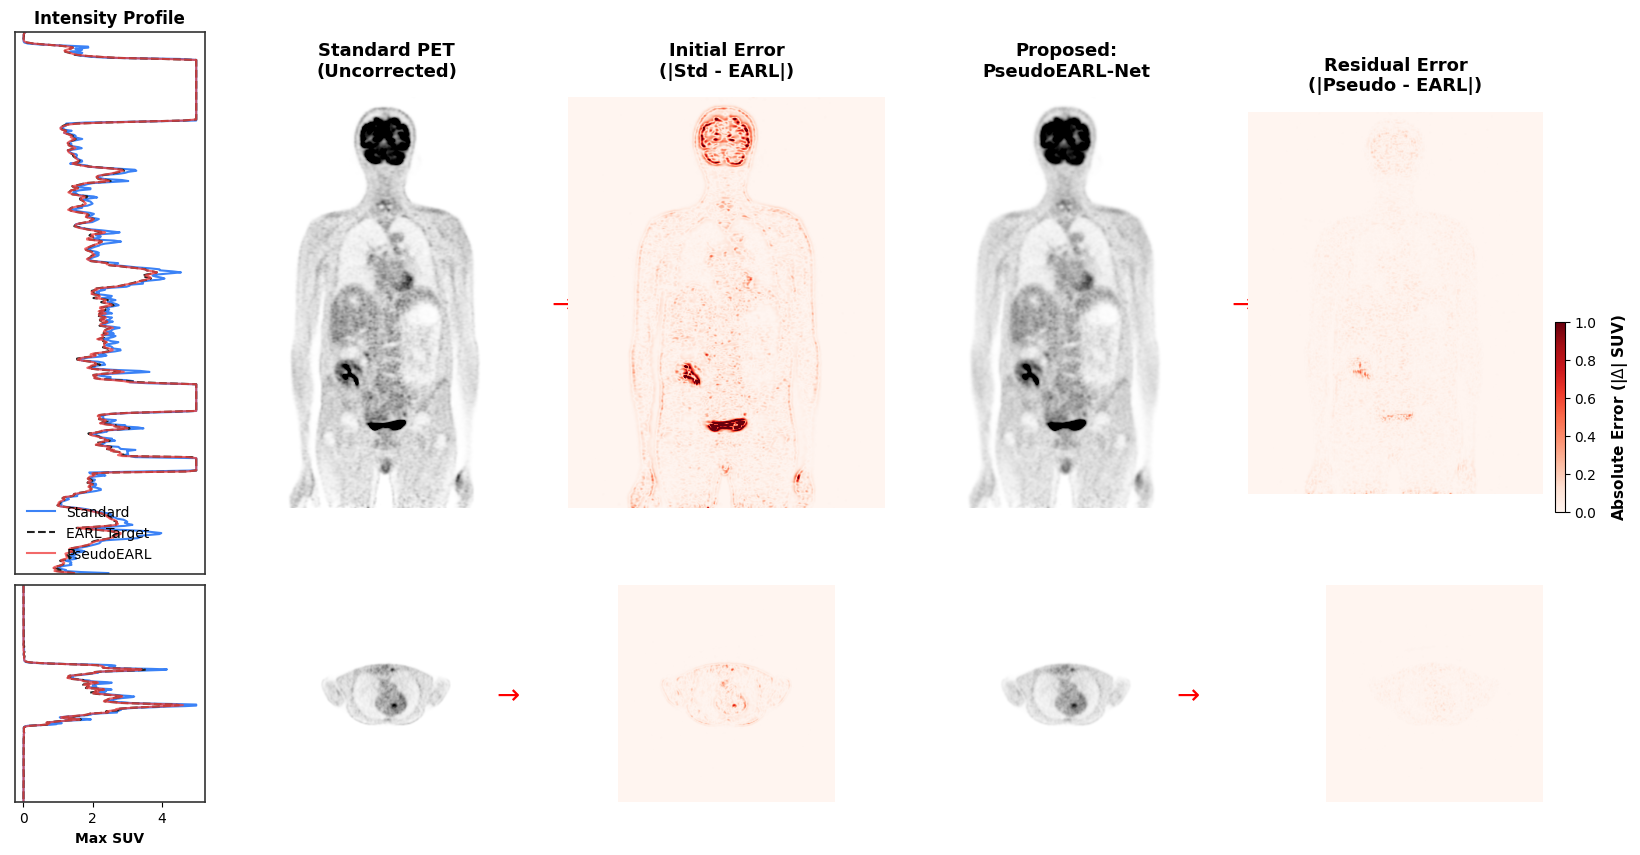

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import nibabel as nib

# --- APPLICATION DE LA CHARTE ---
plt.style.use('default')

def load_and_orient_volume(path_or_array):
    if isinstance(path_or_array, str):
        img = nib.load(path_or_array)
        return img.get_fdata()
    return path_or_array

def plot_pet_error_reduction_panel(std_vol, earl_vol, pseudo_vol, 
                                   coronal_idx, axial_idx, 
                                   figsize=(20, 10),      
                                   vmax_suv=5.0,          
                                   vmax_diff=None,
                                   absolute_diff=True,    # Par défaut en erreur absolue (très visuel)
                                   show_profiles=True):   
    
    # 1. Chargement des données
    v_std = load_and_orient_volume(std_vol)
    v_earl = load_and_orient_volume(earl_vol)     # La vérité terrain cible
    v_pseudo = load_and_orient_volume(pseudo_vol) # La prédiction du modèle
    
    # 2. Extraction des coupes (Rotation pour alignement)
    cor_std = np.rot90(v_std[:, coronal_idx, :], k=1)
    cor_earl = np.rot90(v_earl[:, coronal_idx, :], k=1)
    cor_pseudo = np.rot90(v_pseudo[:, coronal_idx, :], k=1)
    
    ax_std = np.rot90(v_std[:, :, axial_idx], k=1)
    ax_earl = np.rot90(v_earl[:, :, axial_idx], k=1)
    ax_pseudo = np.rot90(v_pseudo[:, :, axial_idx], k=1)
    
    # 3. Calcul des matrices d'erreur (Standard vs EARL) et (Pseudo vs EARL)
    if absolute_diff:
        cor_err_std = np.abs(cor_std - cor_earl)
        ax_err_std = np.abs(ax_std - ax_earl)
        cor_err_pseudo = np.abs(cor_pseudo - cor_earl)
        ax_err_pseudo = np.abs(ax_pseudo - ax_earl)
        
        diff_cmap = 'Reds'
        vmin_diff = 0
        cbar_label = 'Absolute Error (|$\Delta$| SUV)'
        err_str_std = "|Std - EARL|"
        err_str_pseudo = "|Pseudo - EARL|"
    else:
        cor_err_std = cor_std - cor_earl
        ax_err_std = ax_std - ax_earl
        cor_err_pseudo = cor_pseudo - cor_earl
        ax_err_pseudo = ax_pseudo - ax_earl
        
        diff_cmap = 'bwr'
        cbar_label = 'Error ($\Delta$ SUV)'
        err_str_std = "Std - EARL"
        err_str_pseudo = "Pseudo - EARL"
        
    # Gestion dynamique du VMAX de l'erreur
    if vmax_diff is None:
        all_diffs = np.concatenate([
            cor_err_std.flatten(), ax_err_std.flatten(),
            cor_err_pseudo.flatten(), ax_err_pseudo.flatten()
        ])
        vmax_diff = np.nanpercentile(np.abs(all_diffs), 99.9)
        if vmax_diff == 0: vmax_diff = 1.0 
        
    if not absolute_diff:
        vmin_diff = -vmax_diff
    
    # --- GESTION DE L'ARCHITECTURE GRIDSPEC ---
    n_cols = 5 if show_profiles else 4
    width_ratios = [1.2, 2, 2, 2, 2] if show_profiles else [2, 2, 2, 2]
    img_col = 1 if show_profiles else 0
    
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, n_cols, width_ratios=width_ratios, height_ratios=[2.5, 1], wspace=0.08, hspace=0.03)
    
    axes = {}
    for i in range(2):
        for j in range(n_cols):
            axes[(i, j)] = fig.add_subplot(gs[i, j])

    pet_cmap = 'gray_r' 
    
    # --- LIGNE 0 : VUES CORONALES ---
    axes[(0, img_col)].imshow(cor_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(0, img_col+1)].imshow(cor_err_std, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(0, img_col+2)].imshow(cor_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    im_diff = axes[(0, img_col+3)].imshow(cor_err_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    
    # --- LIGNE 1 : VUES AXIALES ---
    axes[(1, img_col)].imshow(ax_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+1)].imshow(ax_err_std, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(1, img_col+2)].imshow(ax_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+3)].imshow(ax_err_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)

    # --- DESSIN DES PROFILS D'INTENSITÉ ---
    if show_profiles:
        # On remplace le Gaussien par la Target EARL (Noir pointillé)
        color_std, color_pseudo, color_earl = '#3b82f6', '#ef4444', '#222222'
        
        # Profil Coronal
        mip_cor_std = np.max(np.clip(cor_std, 0, vmax_suv), axis=1)
        mip_cor_pseudo = np.max(np.clip(cor_pseudo, 0, vmax_suv), axis=1)
        mip_cor_earl = np.max(np.clip(cor_earl, 0, vmax_suv), axis=1)
        y_axis_cor = np.arange(cor_std.shape[0])
        
        ax_pc = axes[(0, 0)]
        ax_pc.plot(mip_cor_std, y_axis_cor, color=color_std, linewidth=1.5, label='Standard')
        ax_pc.plot(mip_cor_earl, y_axis_cor, color=color_earl, linewidth=1.5, linestyle='--', label='EARL Target')
        ax_pc.plot(mip_cor_pseudo, y_axis_cor, color=color_pseudo, linewidth=1.5, alpha=0.8, label='PseudoEARL')
        
        ax_pc.set_title("Intensity Profile", fontweight='bold', fontsize=12)
        ax_pc.set_ylim(cor_std.shape[0] - 0.5, -0.5) 
        ax_pc.legend(loc='lower left', frameon=False, fontsize=10)
        
        # Profil Axial 
        mip_ax_std = np.max(np.clip(ax_std, 0, vmax_suv), axis=1)
        mip_ax_pseudo = np.max(np.clip(ax_pseudo, 0, vmax_suv), axis=1)
        mip_ax_earl = np.max(np.clip(ax_earl, 0, vmax_suv), axis=1)
        y_axis_ax = np.arange(ax_std.shape[0])
        
        ax_pa = axes[(1, 0)]
        ax_pa.plot(mip_ax_std, y_axis_ax, color=color_std, linewidth=1.5)
        ax_pa.plot(mip_ax_earl, y_axis_ax, color=color_earl, linewidth=1.5, linestyle='--')
        ax_pa.plot(mip_ax_pseudo, y_axis_ax, color=color_pseudo, linewidth=1.5, alpha=0.8)
        
        ax_pa.set_xlabel("Max SUV", fontweight='bold', fontsize=10)
        ax_pa.set_ylim(ax_std.shape[0] - 0.5, -0.5)

    # --- ESTHÉTIQUE & NETTOYAGE ---
    titles = [
        "Standard PET\n(Uncorrected)", 
        f"Initial Error\n({err_str_std})", 
        "Proposed:\nPseudoEARL-Net", 
        f"Residual Error\n({err_str_pseudo})"
    ]
    
    for j in range(4):
        axes[(0, img_col + j)].set_title(titles[j], fontweight='bold', pad=15, fontsize=13)
        
    for i in range(2):
        for j in range(n_cols):
            ax = axes[(i, j)]
            if j >= img_col: 
                ax.axis('off') 
            elif show_profiles: 
                if i == 0: ax.set_xticks([]) 
                ax.set_yticks([]) 
                for spine in ax.spines.values():
                    spine.set_linewidth(1.2)
                    spine.set_color('#333333')
    
    # --- FLÈCHES ROUGES DE PROGRESSION ---
    arrow_kwargs = dict(color='red', fontsize=20, fontweight='bold', ha='center', va='center')
    axes[(0, img_col)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(0, img_col)].transAxes, **arrow_kwargs)
    axes[(1, img_col)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(1, img_col)].transAxes, **arrow_kwargs)
    
    axes[(0, img_col+2)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(0, img_col+2)].transAxes, **arrow_kwargs)
    axes[(1, img_col+2)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(1, img_col+2)].transAxes, **arrow_kwargs)

    # --- BARRE DE COULEUR (COLORBAR) ---
    cbar = fig.colorbar(im_diff, ax=[axes[(0, img_col+3)], axes[(1, img_col+3)]], 
                        fraction=0.03, pad=0.04, shrink=0.8)
    cbar.set_label(cbar_label, fontweight='bold', fontsize=11, labelpad=10)
    cbar.ax.tick_params(labelsize=10)

    plt.show()

plot_pet_error_reduction_panel(
    std_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/PET_TEP_TAP_AC.nii.gz', 
    earl_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/EARL_TEP_TAP_EARL.nii.gz',       # La Target
    pseudo_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/pseudo-earl1.nii.gz',
    coronal_idx=200, 
    axial_idx=300,   
    vmax_suv=5.0,
    vmax_diff=1,           
    absolute_diff=True,      # Affiche l'effacement de l'erreur en Rouge -> Blanc
    show_profiles=True       
)

Extraction de la coupe coronale #160...
Calcul des différences...
🔄 Échelle auto-ajustée au 99e percentile : 1.00
Génération de la figure...


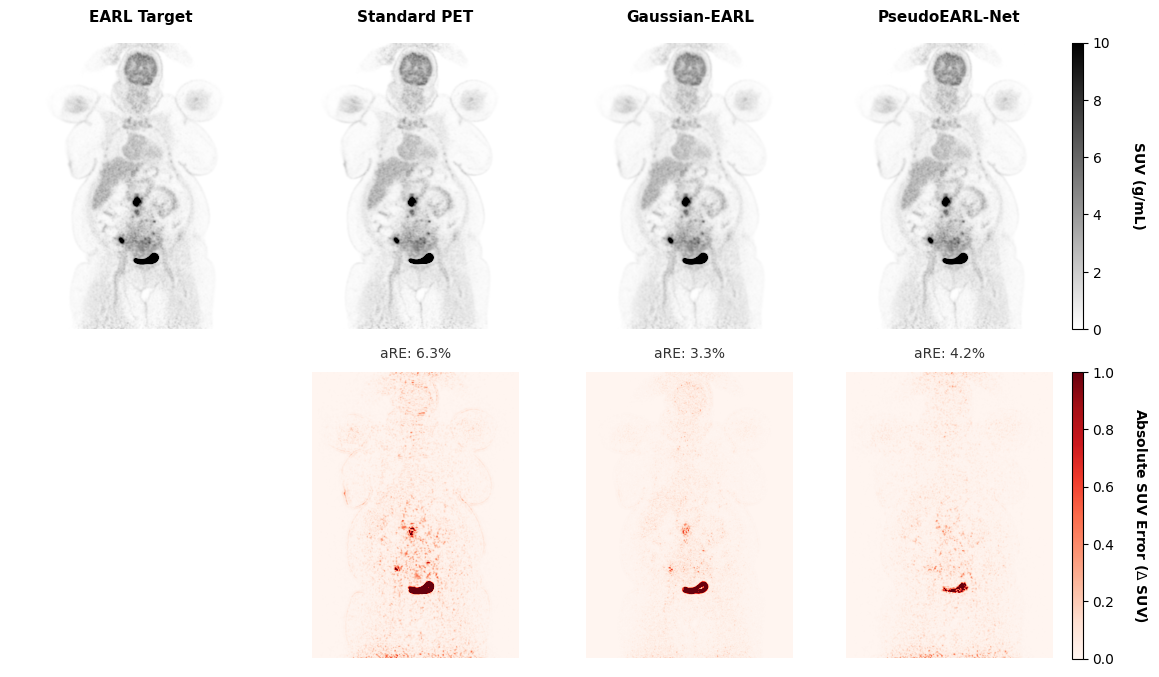

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from mpl_toolkits.axes_grid1 import make_axes_locatable

def generate_slice_difference_figure(path_earl, path_standard, path_gauss, path_pseudo, 
                                     slice_idx, 
                                     figsize=(18, 10),
                                     # --- PARAMÈTRES D'IMAGE ---
                                     vmax_pet=10.0, 
                                     vmax_diff=None, 
                                     cmap_preset=0,  
                                     # --- PARAMÈTRES SPATIAUX ---
                                     wspace=0.05,            
                                     hspace=0.15,            
                                     cbar_width_pct="5%",    
                                     cbar_pad=0.2,           
                                     # --- PARAMÈTRES TYPOGRAPHIQUES ---
                                     title_fontsize=18,      
                                     are_fontsize=15,        
                                     cbar_label_fontsize=14, 
                                     cbar_tick_fontsize=12,  
                                     show_are=True,
                                     save_path=None):
    """
    Génère une figure 2x4 (Coupes PET / Différences), paramétrable de A à Z.
    Ajout d'une échelle SUV sur la 1ère ligne et d'une échelle d'erreur sur la 2ème.
    """
    
    colormaps = ['Reds', 'magma', 'inferno', 'hot', 'Oranges', 'YlOrRd', 'viridis', 'plasma', 'coolwarm', 'jet']
    selected_cmap = colormaps[cmap_preset] if 0 <= cmap_preset <= 9 else colormaps[0]

    def load_and_extract_coronal_slice(path, y_index):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Fichier introuvable : {path}")
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)
        return np.flipud(arr[:, y_index, :])

    print(f"Extraction de la coupe coronale #{slice_idx}...")
    slice_earl = load_and_extract_coronal_slice(path_earl, slice_idx)
    slice_std = load_and_extract_coronal_slice(path_standard, slice_idx)
    slice_gauss = load_and_extract_coronal_slice(path_gauss, slice_idx)
    slice_pseudo = load_and_extract_coronal_slice(path_pseudo, slice_idx)
    
    print("Calcul des différences...")
    diff_std = np.abs(slice_std - slice_earl)
    diff_gauss = np.abs(slice_gauss - slice_earl)
    diff_pseudo = np.abs(slice_pseudo - slice_earl)
    
    if vmax_diff is None:
        all_errors = np.concatenate([diff_std.flatten(), diff_gauss.flatten(), diff_pseudo.flatten()])
        vmax_diff = max(np.percentile(all_errors, 99), 1.0)
        print(f"🔄 Échelle auto-ajustée au 99e percentile : {vmax_diff:.2f}")

    def calculate_mean_are(slice_pred, slice_gt):
        mask = slice_gt > 0.1 
        if not np.any(mask): return 0.0
        return np.mean(np.abs(slice_pred[mask] - slice_gt[mask]) / slice_gt[mask]) * 100

    are_std = calculate_mean_are(slice_std, slice_earl)
    are_gauss = calculate_mean_are(slice_gauss, slice_earl)
    are_pseudo = calculate_mean_are(slice_pseudo, slice_earl)
    
    print("Génération de la figure...")
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    
    # --- LIGNE 1 : Les Coupes PET ---
    titles_top = ['EARL Target', 'Standard PET', 'Gaussian-EARL', 'PseudoEARL-Net']
    slices_top = [slice_earl, slice_std, slice_gauss, slice_pseudo]
    im_pet = None
    
    for i in range(4):
        ax = axes[0, i]
        # On sauvegarde le dernier objet Image (im_pet) pour y attacher la colorbar
        im_pet = ax.imshow(slices_top[i], cmap='gray_r', vmin=0, vmax=vmax_pet)
        ax.set_title(titles_top[i], fontsize=title_fontsize, pad=15, fontweight='bold')
        ax.axis('off')
        
    # --- LIGNE 2 : Les Différences ---
    slices_bottom = [None, diff_std, diff_gauss, diff_pseudo]
    are_values = [None, are_std, are_gauss, are_pseudo]
    im_diff = None 
    
    for i in range(4):
        ax = axes[1, i]
        if i == 0:
            ax.axis('off') 
        else:
            im_diff = ax.imshow(slices_bottom[i], cmap=selected_cmap, vmin=0, vmax=vmax_diff)
            ax.axis('off')
            
            if show_are:
                ax.set_title(f"aRE: {are_values[i]:.1f}%", fontsize=are_fontsize, pad=10, color='#333333')
            else:
                ax.set_title("Absolute Difference", fontsize=are_fontsize - 1, pad=10, color='#555555')
            
    plt.subplots_adjust(wspace=wspace, hspace=hspace)
    
    # --- COLORBAR 1 : ÉCHELLE SUV (Ligne du haut) ---
    ax_pet_right = axes[0, 3] # La dernière image en haut à droite
    divider_pet = make_axes_locatable(ax_pet_right)
    cbar_ax_pet = divider_pet.append_axes("right", size=cbar_width_pct, pad=cbar_pad)
    
    cbar_pet = fig.colorbar(im_pet, cax=cbar_ax_pet)
    cbar_pet.set_label('SUV (g/mL)', rotation=270, labelpad=25, 
                       fontsize=cbar_label_fontsize, fontweight='bold')
    cbar_pet.ax.tick_params(labelsize=cbar_tick_fontsize)
    
    # --- COLORBAR 2 : ÉCHELLE D'ERREUR (Ligne du bas) ---
    ax_diff_right = axes[1, 3] # La dernière image en bas à droite
    divider_diff = make_axes_locatable(ax_diff_right)
    cbar_ax_diff = divider_diff.append_axes("right", size=cbar_width_pct, pad=cbar_pad)
    
    cbar_diff = fig.colorbar(im_diff, cax=cbar_ax_diff)
    cbar_diff.set_label('Absolute SUV Error ($\Delta$ SUV)', rotation=270, labelpad=25, 
                        fontsize=cbar_label_fontsize, fontweight='bold')
    cbar_diff.ax.tick_params(labelsize=cbar_tick_fontsize)
    
    if save_path is not None:
        # plt.savefig(save_path, bbox_inches='tight', dpi=300, transparent=False, facecolor='white')
        print(f"✅ Figure sauvegardée sous : {save_path}")
        
    plt.show()

# ==========================================
# EXEMPLE D'EXÉCUTION
# ==========================================

# Renseigne ici les chemins vers un patient spécifique
patient_dir = '../data/PET-EARL/domain_a100/A100785598'

path_earl = os.path.join(patient_dir, "EARL_TEP_TAP_EARL2.nii.gz")
path_standard = os.path.join(patient_dir, "PET_TEP_TAP_AC_G4mm.nii.gz") 
path_gauss = os.path.join(patient_dir, "gaussian-earl2.nii.gz")
path_pseudo = os.path.join(patient_dir, "pseudo-earl2-dsr10.nii.gz")

generate_slice_difference_figure(
    path_earl=path_earl,
    path_standard=path_standard,
    path_gauss=path_gauss,
    path_pseudo=path_pseudo,
    
    slice_idx=160,  
    
    # -- RÉGLAGES D'ERREUR ET DE COULEUR --
    vmax_pet=10.0,   
    vmax_diff=None, # Laisse None pour utiliser le 99e percentile
    cmap_preset=0,  # 0=Reds, 1=Magma...
    
    # -- PERSONNALISATION SPATIALE --
    figsize=(14, 8),
    wspace=0.05,          
    hspace=0.15,          
    cbar_width_pct="5%",  
    cbar_pad=0.2,         
    
    # -- PERSONNALISATION TYPOGRAPHIQUE --
    title_fontsize=11,
    are_fontsize=10,
    cbar_label_fontsize=10,
    cbar_tick_fontsize=10,
    
    show_are=True,        
    # save_path="earl1_slice_difference_figure.png"
)

Extraction de la coupe coronale #180...
Calcul des différences...
🔄 Échelle d'erreur auto-ajustée au 99e percentile : 1.00
Génération de la figure...


/tmp/ipykernel_3621640/869410862.py:157: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(save_path, bbox_inches='tight', dpi=300, transparent=False, facecolor='white')
/tmp/ipykernel_3621640/869410862.py:157: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(save_path, bbox_inches='tight', dpi=300, transparent=False, facecolor='white')
/tmp/ipykernel_3621640/869410862.py:157: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(save_path, bbox_inches='tight', dpi=300, transparent=False, facecolor='white')


✅ Figure sauvegardée sous : dual_standard_difference_figure.svg


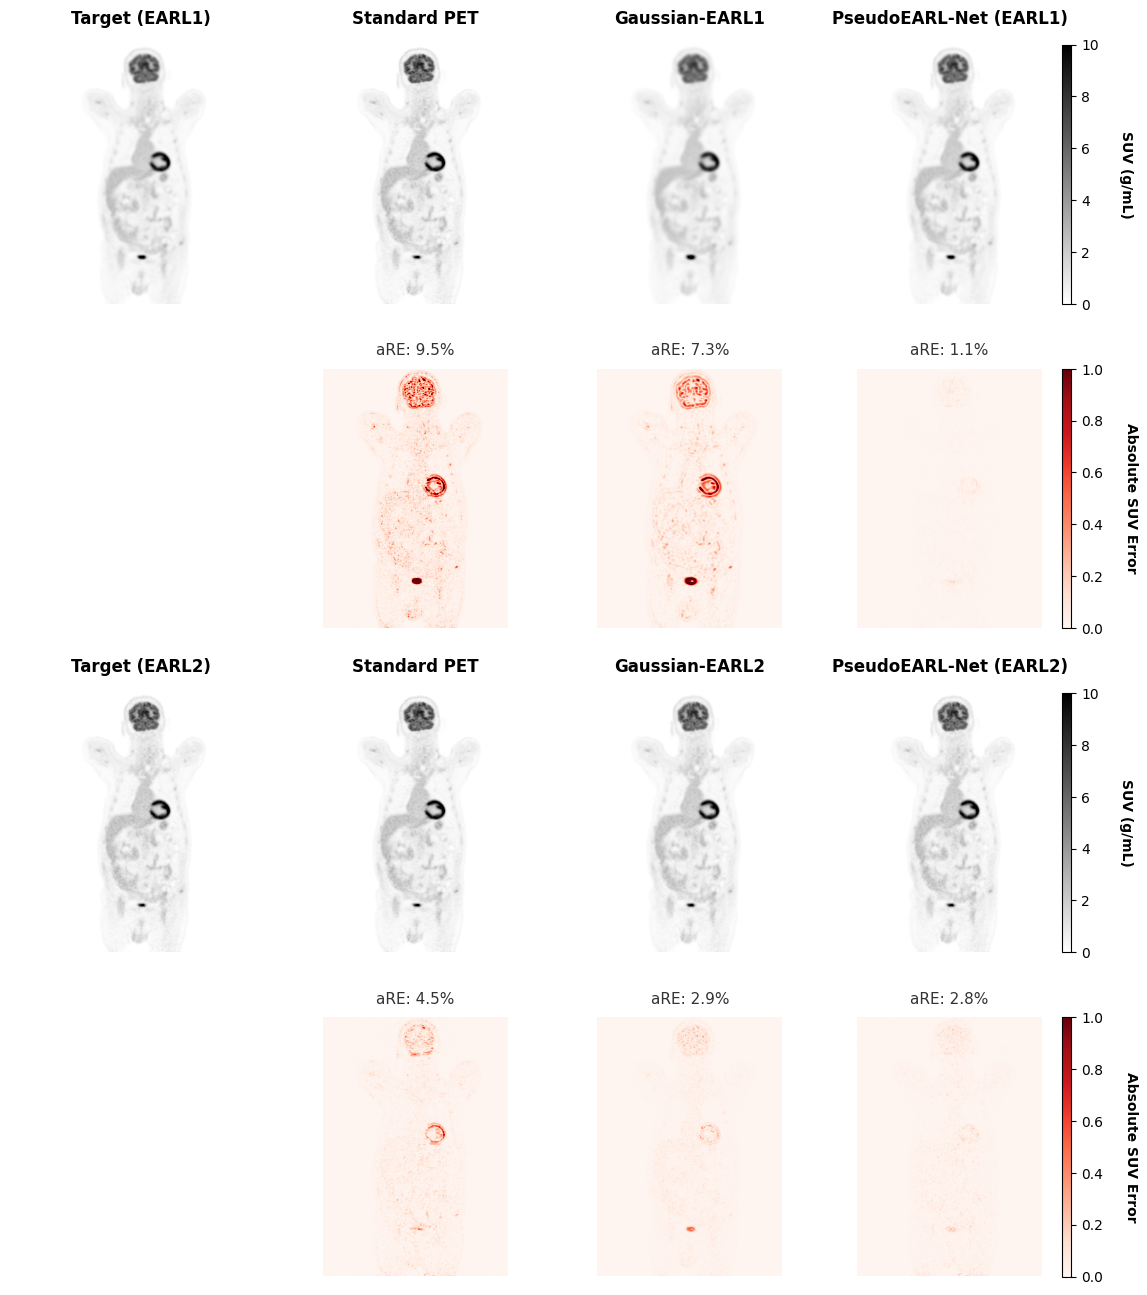

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from mpl_toolkits.axes_grid1 import make_axes_locatable

def generate_dual_standard_slice_figure(path_earl1, path_earl2,
                                        path_standard, 
                                        path_gauss1, path_gauss2,
                                        path_pseudo1, path_pseudo2, 
                                        slice_idx, 
                                        figsize=(16, 16),
                                        # --- PARAMÈTRES D'IMAGE ---
                                        vmax_pet=10.0, 
                                        vmax_diff=None, 
                                        cmap_preset=0,  
                                        # --- PARAMÈTRES SPATIAUX ---
                                        wspace=0.05,            
                                        hspace=0.25,            
                                        cbar_width_pct="5%",    
                                        cbar_pad=0.2,           
                                        # --- PARAMÈTRES TYPOGRAPHIQUES ---
                                        title_fontsize=16,      
                                        are_fontsize=14,        
                                        cbar_label_fontsize=12, 
                                        cbar_tick_fontsize=10,  
                                        show_are=True,
                                        save_path=None):
    
    colormaps = ['Reds', 'magma', 'inferno', 'hot', 'Oranges', 'YlOrRd', 'viridis', 'plasma', 'coolwarm', 'jet']
    selected_cmap = colormaps[cmap_preset] if 0 <= cmap_preset <= 9 else colormaps[0]

    def load_and_extract_coronal_slice(path, y_index):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Fichier introuvable : {path}")
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)
        return np.flipud(arr[:, y_index, :])

    print(f"Extraction de la coupe coronale #{slice_idx}...")
    
    # Chargement Standard (commun)
    slice_std = load_and_extract_coronal_slice(path_standard, slice_idx)
    
    # Chargement EARL 1
    slice_earl1 = load_and_extract_coronal_slice(path_earl1, slice_idx)
    slice_gauss1 = load_and_extract_coronal_slice(path_gauss1, slice_idx)
    slice_pseudo1 = load_and_extract_coronal_slice(path_pseudo1, slice_idx)
    
    # Chargement EARL 2
    slice_earl2 = load_and_extract_coronal_slice(path_earl2, slice_idx)
    slice_gauss2 = load_and_extract_coronal_slice(path_gauss2, slice_idx)
    slice_pseudo2 = load_and_extract_coronal_slice(path_pseudo2, slice_idx)
    
    print("Calcul des différences...")
    diff_std1 = np.abs(slice_std - slice_earl1)
    diff_gauss1 = np.abs(slice_gauss1 - slice_earl1)
    diff_pseudo1 = np.abs(slice_pseudo1 - slice_earl1)
    
    diff_std2 = np.abs(slice_std - slice_earl2)
    diff_gauss2 = np.abs(slice_gauss2 - slice_earl2)
    diff_pseudo2 = np.abs(slice_pseudo2 - slice_earl2)
    
    if vmax_diff is None:
        all_errors = np.concatenate([
            diff_std1.flatten(), diff_gauss1.flatten(), diff_pseudo1.flatten(),
            diff_std2.flatten(), diff_gauss2.flatten(), diff_pseudo2.flatten()
        ])
        vmax_diff = max(np.percentile(all_errors, 99), 1.0)
        print(f"🔄 Échelle d'erreur auto-ajustée au 99e percentile : {vmax_diff:.2f}")

    def calculate_mean_are(slice_pred, slice_gt):
        mask = slice_gt > 0.1 
        if not np.any(mask): return 0.0
        return np.mean(np.abs(slice_pred[mask] - slice_gt[mask]) / slice_gt[mask]) * 100

    are_std1, are_gauss1, are_pseudo1 = map(lambda p: calculate_mean_are(p, slice_earl1), [slice_std, slice_gauss1, slice_pseudo1])
    are_std2, are_gauss2, are_pseudo2 = map(lambda p: calculate_mean_are(p, slice_earl2), [slice_std, slice_gauss2, slice_pseudo2])
    
    print("Génération de la figure...")
    fig, axes = plt.subplots(4, 4, figsize=figsize)
    
    # ==========================================
    # BLOC 1 : CIBLE EARL 1
    # ==========================================
    titles_pet1 = ['Target (EARL1)', 'Standard PET', 'Gaussian-EARL1', 'PseudoEARL-Net (EARL1)']
    slices_pet1 = [slice_earl1, slice_std, slice_gauss1, slice_pseudo1]
    
    titles_diff1 = [None, f"aRE: {are_std1:.1f}%", f"aRE: {are_gauss1:.1f}%", f"aRE: {are_pseudo1:.1f}%"]
    slices_diff1 = [None, diff_std1, diff_gauss1, diff_pseudo1]
    
    # Ligne 0 : PET EARL 1
    for i in range(4):
        ax = axes[0, i]
        im_pet1 = ax.imshow(slices_pet1[i], cmap='gray_r', vmin=0, vmax=vmax_pet)
        ax.set_title(titles_pet1[i], fontsize=title_fontsize, pad=15, fontweight='bold')
        ax.axis('off')
        
    # Ligne 1 : Différences EARL 1
    for i in range(4):
        ax = axes[1, i]
        if i == 0:
            ax.axis('off') 
        else:
            im_diff1 = ax.imshow(slices_diff1[i], cmap=selected_cmap, vmin=0, vmax=vmax_diff)
            ax.axis('off')
            title_text = titles_diff1[i] if show_are else "Absolute Difference"
            ax.set_title(title_text, fontsize=are_fontsize, pad=10, color='#333333')
            
    # ==========================================
    # BLOC 2 : CIBLE EARL 2
    # ==========================================
    titles_pet2 = ['Target (EARL2)', 'Standard PET', 'Gaussian-EARL2', 'PseudoEARL-Net (EARL2)']
    slices_pet2 = [slice_earl2, slice_std, slice_gauss2, slice_pseudo2]
    
    titles_diff2 = [None, f"aRE: {are_std2:.1f}%", f"aRE: {are_gauss2:.1f}%", f"aRE: {are_pseudo2:.1f}%"]
    slices_diff2 = [None, diff_std2, diff_gauss2, diff_pseudo2]
    
    # Ligne 2 : PET EARL 2
    for i in range(4):
        ax = axes[2, i]
        im_pet2 = ax.imshow(slices_pet2[i], cmap='gray_r', vmin=0, vmax=vmax_pet)
        ax.set_title(titles_pet2[i], fontsize=title_fontsize, pad=15, fontweight='bold')
        ax.axis('off')
        
    # Ligne 3 : Différences EARL 2
    for i in range(4):
        ax = axes[3, i]
        if i == 0:
            ax.axis('off') 
        else:
            im_diff2 = ax.imshow(slices_diff2[i], cmap=selected_cmap, vmin=0, vmax=vmax_diff)
            ax.axis('off')
            title_text = titles_diff2[i] if show_are else "Absolute Difference"
            ax.set_title(title_text, fontsize=are_fontsize, pad=10, color='#333333')

    plt.subplots_adjust(wspace=wspace, hspace=hspace)
    
    # ==========================================
    # AJOUT DES COLORBARS
    # ==========================================
    def add_colorbar(ax_target, im_source, label_text):
        divider = make_axes_locatable(ax_target)
        cbar_ax = divider.append_axes("right", size=cbar_width_pct, pad=cbar_pad)
        cbar = fig.colorbar(im_source, cax=cbar_ax)
        cbar.set_label(label_text, rotation=270, labelpad=25, 
                       fontsize=cbar_label_fontsize, fontweight='bold')
        cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    # Attachées à la dernière colonne de chaque ligne
    add_colorbar(axes[0, 3], im_pet1, 'SUV (g/mL)')
    add_colorbar(axes[1, 3], im_diff1, 'Absolute SUV Error')
    add_colorbar(axes[2, 3], im_pet2, 'SUV (g/mL)')
    add_colorbar(axes[3, 3], im_diff2, 'Absolute SUV Error')
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=300, transparent=False, facecolor='white')
        print(f"✅ Figure sauvegardée sous : {save_path}")
        
    plt.show()

# ==========================================
# EXEMPLE D'EXÉCUTION
# ==========================================
patient_dir = '../data/PET-EARL/domain_a100/A100783275' # A100785598

generate_dual_standard_slice_figure(
    path_earl1 = os.path.join(patient_dir, "EARL_TEP_TAP_EARL1.nii.gz"),
    path_earl2 = os.path.join(patient_dir, "EARL_TEP_TAP_EARL2.nii.gz"),
    
    path_standard = os.path.join(patient_dir, "PET_TEP_TAP_AC_G4mm.nii.gz"), 
    
    path_gauss1 = os.path.join(patient_dir, "gaussian-earl1.nii.gz"),
    path_gauss2 = os.path.join(patient_dir, "gaussian-earl2.nii.gz"),
    
    path_pseudo1 = os.path.join(patient_dir, "pseudo-earl1-dsr10.nii.gz"),
    path_pseudo2 = os.path.join(patient_dir, "pseudo-earl2-dsr10.nii.gz"),
    
    # --- PARAMÈTRES DE LA COUPE ---
    slice_idx=180,  
    
    # -- RÉGLAGES D'ERREUR ET DE COULEUR --
    vmax_pet=10.0,   
    vmax_diff=None, # Auto-ajustement global sur EARL 1 & 2
    cmap_preset=0,  
    
    # -- PERSONNALISATION SPATIALE --
    figsize=(14, 16), 
    wspace=0.05,          
    hspace=0.25,      
    cbar_width_pct="5%",  
    cbar_pad=0.2,         
    
    # -- PERSONNALISATION TYPOGRAPHIQUE --
    title_fontsize=12,
    are_fontsize=11,
    cbar_label_fontsize=10,
    cbar_tick_fontsize=10,
    
    show_are=True,        
    save_path="dual_standard_difference_figure.svg"
)

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

pet = nib.load('../data/scptemp/PET_TEP_TAP_AC_G4mm.nii.gz').get_fdata()
earl = nib.load('../data/scptemp/EARL_TEP_TAP_EARL1.nii.gz').get_fdata()

slcie_idx = 200
coronal_pet = np.rot90(pet[60:303, slcie_idx, pet.shape[-1] - 363:], k=1)
coronal_earl = np.rot90(earl[60:303, slcie_idx, earl.shape[-1] - 363:], k=1)
residual = np.abs(coronal_pet - coronal_earl)

#save each one of them
for img, name in zip([coronal_pet, coronal_earl, residual], ['coronal_pet.png', 'coronal_earl.png', 'residual.png']):
    plt.imshow(img, cmap='gray_r' if name in ['coronal_pet.png', 'coronal_earl.png'] else 'RdBu_r', vmin=0, vmax=5 if name in ['coronal_pet.png', 'coronal_earl.png'] else 2)
    plt.axis('off')
    plt.savefig(name, bbox_inches='tight', dpi=300)
    plt.close()

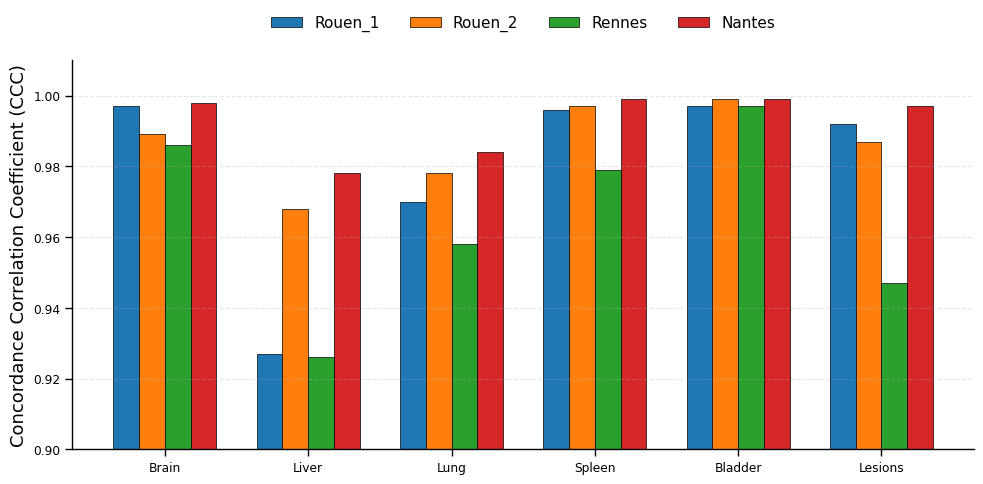

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# REPLACE WITH YOUR DATA
# ------------------------------------------------------------------

vois = ["Brain", "Liver", "Lung", "Spleen", "Bladder", "Lesions"]

data = {
    "Rouen_1": [0.997, 0.927, 0.970, 0.996, 0.997, 0.992],
    "Rouen_2": [0.989, 0.968, 0.978, 0.997, 0.999, 0.987],
    "Rennes":  [0.986, 0.926, 0.958, 0.979, 0.997, 0.947],
    "Nantes":  [0.998, 0.978, 0.984, 0.999, 0.999, 0.997]
}

df = pd.DataFrame(data, index=vois)

# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(vois))
width = 0.18

for i, center in enumerate(df.columns):
    ax.bar(
        x + (i - 1.5) * width,
        df[center],
        width=width,
        label=center,
        edgecolor="black",
        linewidth=0.5
    )

ax.set_xticks(x)
ax.set_xticklabels(vois)

ax.set_ylabel("Concordance Correlation Coefficient (CCC)")
ax.set_ylim(0.90, 1.01)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15)
)

plt.tight_layout()
plt.show()

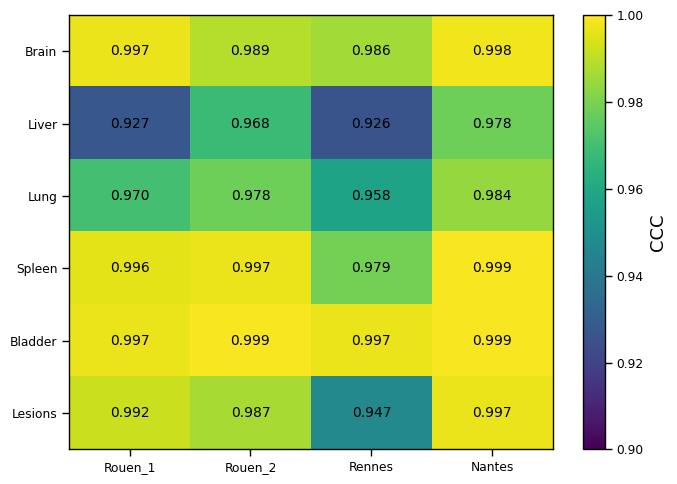

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(7,5))

im = ax.imshow(
    df,
    aspect="auto",
    vmin=0.90,
    vmax=1.00
)

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns)

ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index)

for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        ax.text(
            j,
            i,
            f"{df.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            fontsize=10
        )

cbar = plt.colorbar(im)
cbar.set_label("CCC")

plt.tight_layout()
plt.show()

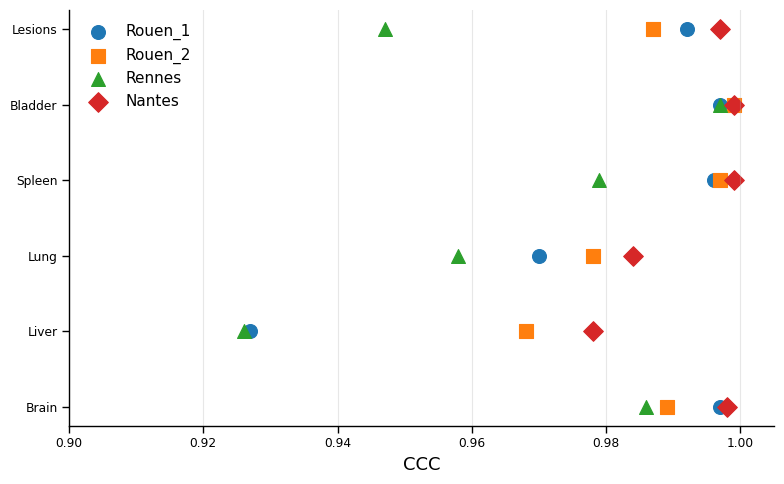

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(8,5))

markers = ["o","s","^","D"]

for marker, center in zip(markers, df.columns):
    ax.scatter(
        df[center],
        df.index,
        s=100,
        marker=marker,
        label=center
    )

ax.set_xlim(0.90,1.005)
ax.set_xlabel("CCC")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

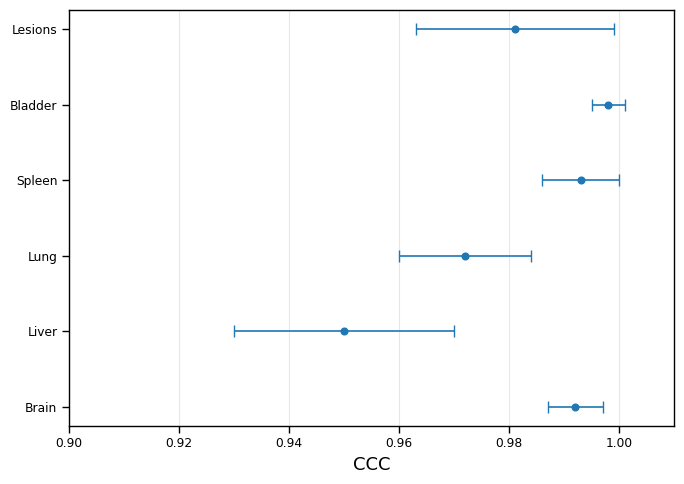

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vois = ["Brain","Liver","Lung","Spleen","Bladder","Lesions"]

mean_ccc = [0.992,0.950,0.972,0.993,0.998,0.981]
sd_ccc = [0.005,0.020,0.012,0.007,0.003,0.018]

fig, ax = plt.subplots(figsize=(7,5))

y = np.arange(len(vois))

ax.errorbar(
    mean_ccc,
    y,
    xerr=sd_ccc,
    fmt='o',
    capsize=4
)

ax.set_yticks(y)
ax.set_yticklabels(vois)

ax.set_xlabel("CCC")
ax.set_xlim(0.90,1.01)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

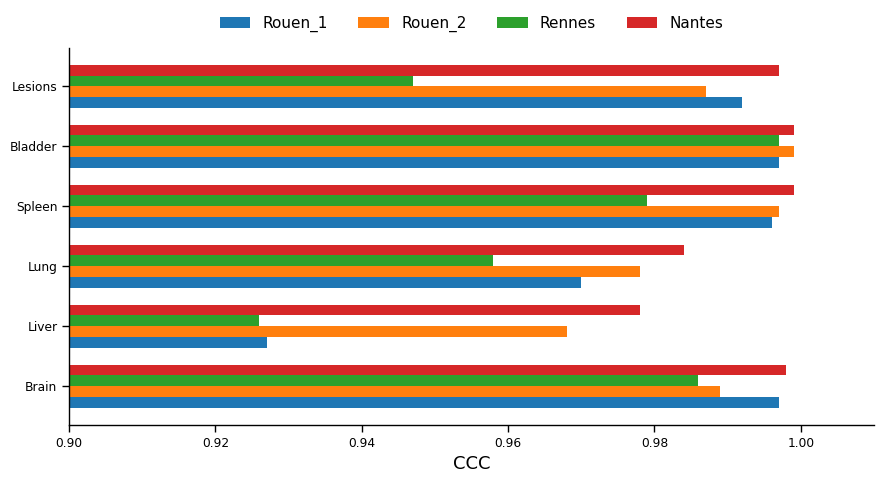

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(9,5))

y = np.arange(len(df.index))
h = 0.18

for i, center in enumerate(df.columns):
    ax.barh(
        y + (i-1.5)*h,
        df[center],
        height=h,
        label=center
    )

ax.set_yticks(y)
ax.set_yticklabels(df.index)

ax.set_xlim(0.90,1.01)

ax.set_xlabel("CCC")

ax.legend(
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,1.12),
    loc="upper center"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

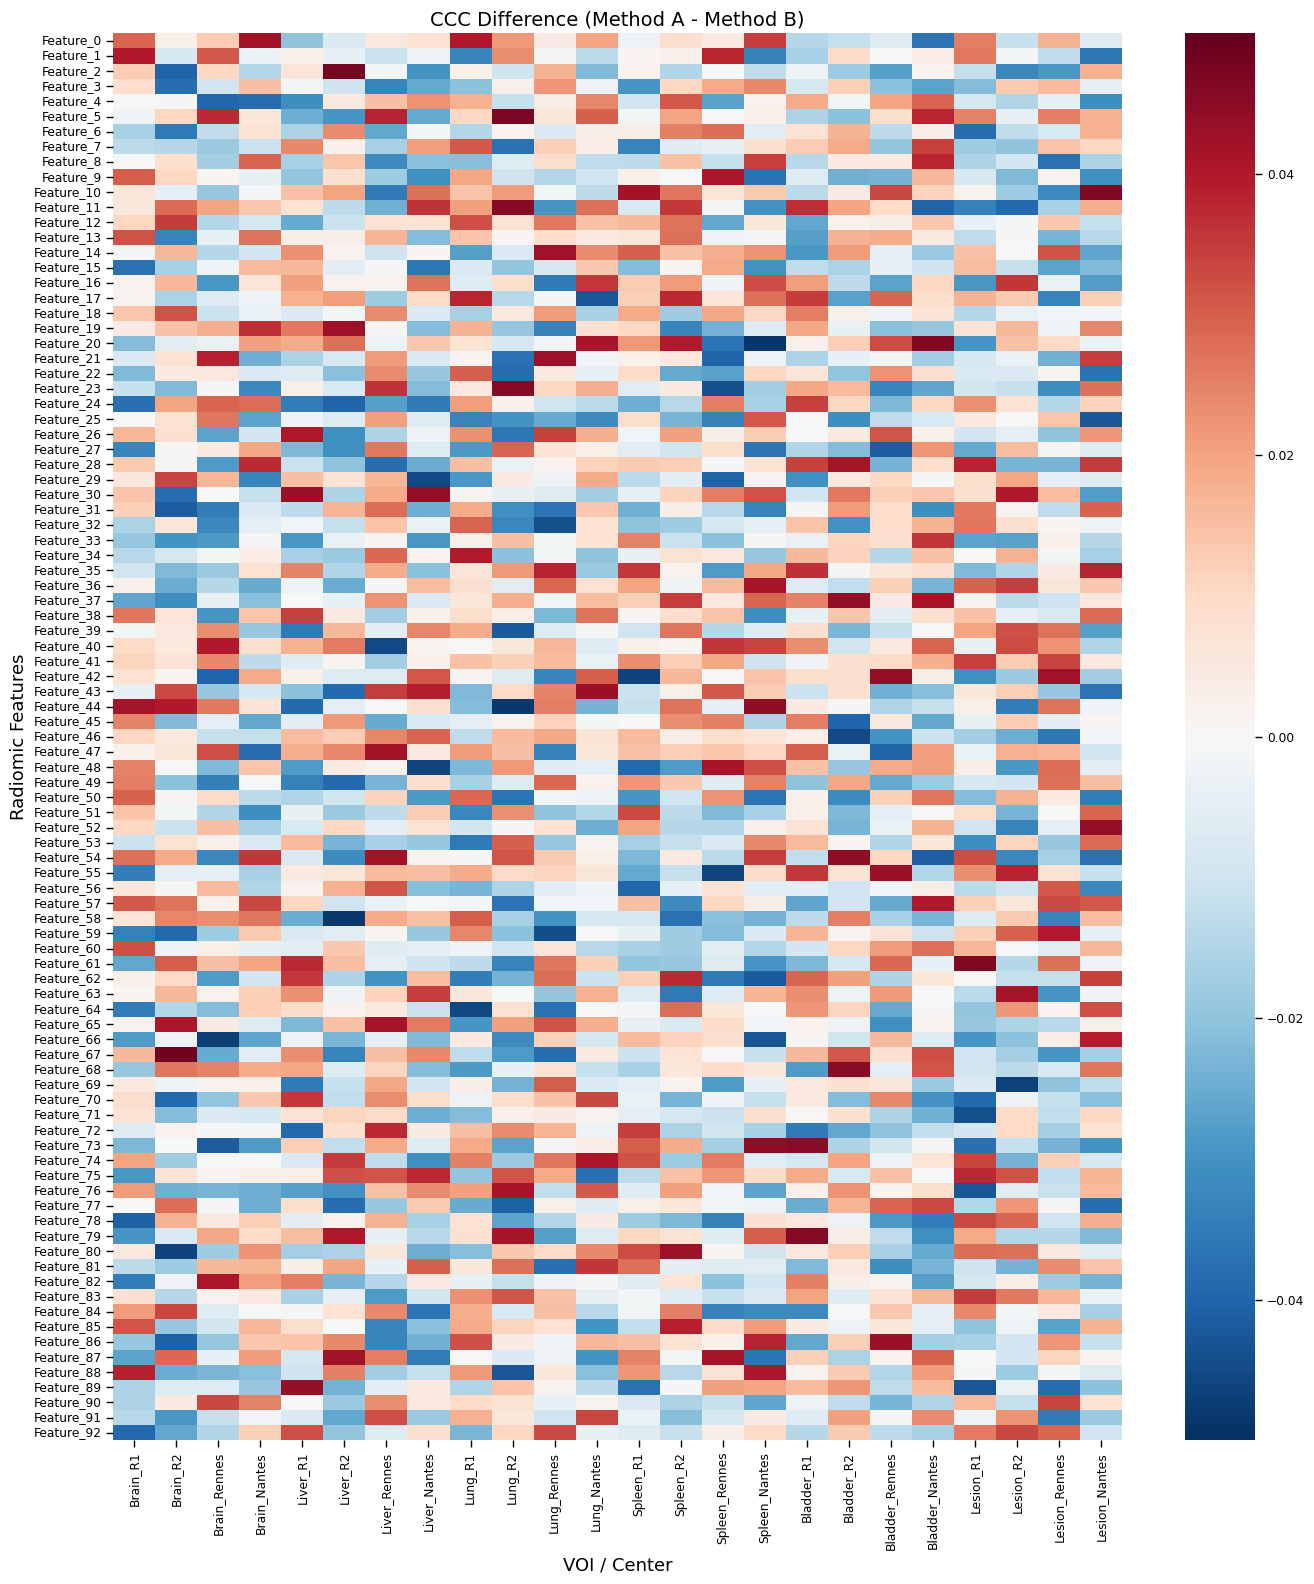

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Example
# ----------------------------------------------------

features = [f"Feature_{i}" for i in range(93)]

columns = [
    "Brain_R1","Brain_R2","Brain_Rennes","Brain_Nantes",
    "Liver_R1","Liver_R2","Liver_Rennes","Liver_Nantes",
    "Lung_R1","Lung_R2","Lung_Rennes","Lung_Nantes",
    "Spleen_R1","Spleen_R2","Spleen_Rennes","Spleen_Nantes",
    "Bladder_R1","Bladder_R2","Bladder_Rennes","Bladder_Nantes",
    "Lesion_R1","Lesion_R2","Lesion_Rennes","Lesion_Nantes"
]

# CCC of your method
ccc_method_A = pd.DataFrame(
    0.95 + 0.05*np.random.rand(93,24),
    index=features,
    columns=columns
)

# CCC of reference method
ccc_method_B = pd.DataFrame(
    0.95 + 0.05*np.random.rand(93,24),
    index=features,
    columns=columns
)

delta = ccc_method_A - ccc_method_B

plt.figure(figsize=(14,16))

sns.heatmap(
    delta,
    cmap="RdBu_r",
    center=0,
    vmin=-0.05,
    vmax=0.05
)

plt.title("CCC Difference (Method A - Method B)")
plt.xlabel("VOI / Center")
plt.ylabel("Radiomic Features")

plt.tight_layout()
plt.show()

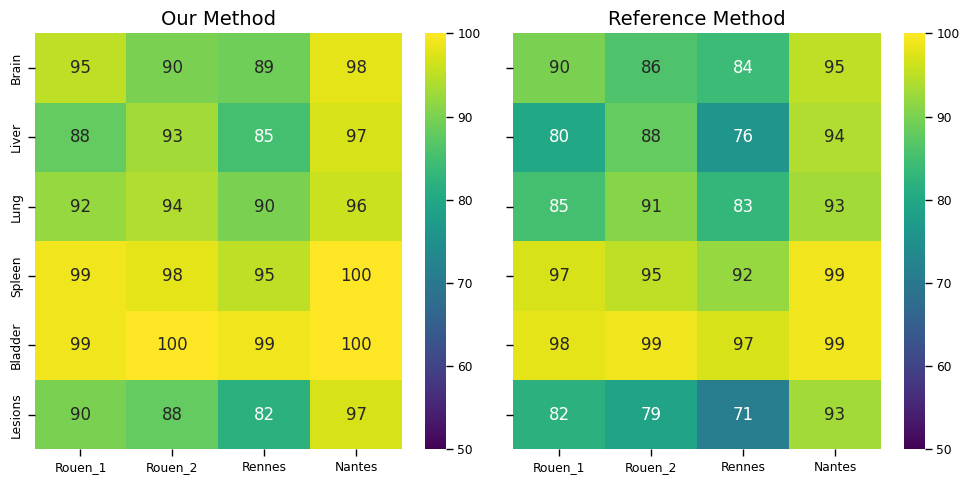

In [ ]:
# percentage_features_ccc90 = (
#     df
#     .groupby(["Method","VOI","Center"])
#     ["CCC"]
#     .apply(lambda x: (x > 0.90).mean()*100)
# )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example
data_A = pd.DataFrame({
    "Rouen_1":[95,88,92,99,99,90],
    "Rouen_2":[90,93,94,98,100,88],
    "Rennes":[89,85,90,95,99,82],
    "Nantes":[98,97,96,100,100,97]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

data_B = pd.DataFrame({
    "Rouen_1":[90,80,85,97,98,82],
    "Rouen_2":[86,88,91,95,99,79],
    "Rennes":[84,76,83,92,97,71],
    "Nantes":[95,94,93,99,99,93]
},
index=data_A.index)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10,5),
    sharey=True
)

sns.heatmap(
    data_A,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=50,
    vmax=100,
    ax=axes[0]
)

axes[0].set_title("Our Method")

sns.heatmap(
    data_B,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=50,
    vmax=100,
    ax=axes[1]
)

axes[1].set_title("Reference Method")

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# 1. Données hardcodées extraites des tableaux fournis
data = [
    # === GROUPE EARL1 (a100, chb, Rennes) ===
    # a100 (Rouen 1) - EARL1
    {"centre": "a100", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.67, "PSNR": 48.12},
    {"centre": "a100", "standard": "EARL1", "voi": "LIVER", "aRE": 0.42, "PSNR": 46.48},
    {"centre": "a100", "standard": "EARL1", "voi": "LUNG", "aRE": 0.83, "PSNR": 44.92},
    {"centre": "a100", "standard": "EARL1", "voi": "SPLEEN", "aRE": 0.57, "PSNR": 47.86},
    {"centre": "a100", "standard": "EARL1", "voi": "BLADDER", "aRE": 1.11, "PSNR": 48.25},
    {"centre": "a100", "standard": "EARL1", "voi": "LESIONS", "aRE": 1.02, "PSNR": 42.88},
    
    # chb (Rouen 2) - EARL1
    {"centre": "chb", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.88, "PSNR": 45.31},
    {"centre": "chb", "standard": "EARL1", "voi": "LIVER", "aRE": 0.27, "PSNR": 51.78},
    {"centre": "chb", "standard": "EARL1", "voi": "LUNG", "aRE": 0.39, "PSNR": 51.45},
    {"centre": "chb", "standard": "EARL1", "voi": "SPLEEN", "aRE": 0.28, "PSNR": 55.39},
    {"centre": "chb", "standard": "EARL1", "voi": "BLADDER", "aRE": 0.55, "PSNR": 56.46},
    {"centre": "chb", "standard": "EARL1", "voi": "LESIONS", "aRE": 0.34, "PSNR": 54.16},
    
    # Rennes - EARL1
    {"centre": "Rennes", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.87, "PSNR": 45.76},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LIVER", "aRE": 1.41, "PSNR": 37.91},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LUNG", "aRE": 2.21, "PSNR": 37.17},
    {"centre": "Rennes", "standard": "EARL1", "voi": "SPLEEN", "aRE": 1.88, "PSNR": 38.22},
    {"centre": "Rennes", "standard": "EARL1", "voi": "BLADDER", "aRE": 2.07, "PSNR": 41.66},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LESIONS", "aRE": 2.57, "PSNR": 36.09},

    # === GROUPE EARL2 (a100, Nantes) ===
    # a100 (Rouen 1) - EARL2
    {"centre": "a100", "standard": "EARL2", "voi": "BRAIN", "aRE": 1.13, "PSNR": 45.13},
    {"centre": "a100", "standard": "EARL2", "voi": "LIVER", "aRE": 0.99, "PSNR": 40.69},
    {"centre": "a100", "standard": "EARL2", "voi": "LUNG", "aRE": 1.80, "PSNR": 39.77},
    {"centre": "a100", "standard": "EARL2", "voi": "SPLEEN", "aRE": 1.31, "PSNR": 41.91},
    {"centre": "a100", "standard": "EARL2", "voi": "BLADDER", "aRE": 1.55, "PSNR": 47.08},
    {"centre": "a100", "standard": "EARL2", "voi": "LESIONS", "aRE": 1.71, "PSNR": 39.98},
    
    # Nantes - EARL2
    {"centre": "Nantes", "standard": "EARL2", "voi": "BRAIN", "aRE": 0.30, "PSNR": 53.78},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LIVER", "aRE": 0.23, "PSNR": 50.94},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LUNG", "aRE": 0.47, "PSNR": 49.78},
    {"centre": "Nantes", "standard": "EARL2", "voi": "SPLEEN", "aRE": 0.27, "PSNR": 52.84},
    {"centre": "Nantes", "standard": "EARL2", "voi": "BLADDER", "aRE": 0.46, "PSNR": 56.30},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LESIONS", "aRE": 0.45, "PSNR": 50.05}
]

# 2. Création du DataFrame
df = pd.DataFrame(data)

# 3. Calcul de la moyenne par Standard et par Organe (VOI)
df_mean = df.groupby(['standard', 'voi'])[['aRE', 'PSNR']].mean().reset_index()

# 4. Pivot du tableau pour mettre les standards en colonnes
df_pivot = df_mean.pivot(index='voi', columns='standard', values=['aRE', 'PSNR'])

# 5. Aplatir le MultiIndex des colonnes
df_pivot.columns = [f"{std}_{metric}" for metric, std in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# 6. Réorganisation des colonnes et des lignes selon l'ordre demandé
ordered_columns = ['voi', 'EARL1_aRE', 'EARL1_PSNR', 'EARL2_aRE', 'EARL2_PSNR']
df_final = df_pivot[ordered_columns]

# Définition de l'ordre spécifique des lignes (organes)
row_order = ['BRAIN', 'LIVER', 'LUNG', 'SPLEEN', 'BLADDER', 'LESIONS']
df_final['voi'] = pd.Categorical(df_final['voi'], categories=row_order, ordered=True)
df_final = df_final.sort_values('voi').reset_index(drop=True)

# 7. Affichage des résultats
print("==================================================================")
print("  MOYENNES PAR STANDARD (EARL1 vs EARL2) ET PAR ORGANE REORDONNÉ  ")
print("==================================================================")
pd.options.display.float_format = '{:,.2f}'.format
print(df_final.to_string(index=False, header=[
    'VOIs', 'Moyenne EARL1 aRE (%)', 'Moyenne EARL1 PSNR (dB)', 
    'Moyenne EARL2 aRE (%)', 'Moyenne EARL2 PSNR (dB)'
]))

  MOYENNES PAR STANDARD (EARL1 vs EARL2) ET PAR ORGANE REORDONNÉ  
   VOIs Moyenne EARL1 aRE (%) Moyenne EARL1 PSNR (dB) Moyenne EARL2 aRE (%) Moyenne EARL2 PSNR (dB)
  BRAIN                  0.81                   46.40                  0.71                   49.45
  LIVER                  0.70                   45.39                  0.61                   45.81
   LUNG                  1.14                   44.51                  1.14                   44.78
 SPLEEN                  0.91                   47.16                  0.79                   47.38
BLADDER                  1.24                   48.79                  1.01                   51.69
LESIONS                  1.31                   44.38                  1.08                   45.02


# ==============================================================================
# CHARTE GRAPHIQUE SCIENTIFIQUE - PROJET RADIOMIQUES / IA MULTICENTRIQUE
# ==============================================================================
# Objectif : Garantir une uniformité visuelle stricte (style 'Science' épuré) 
# pour les publications académiques (IEEE, MICCAI, etc.).
# ==============================================================================

global_settings:
  matplotlib_style: "default"
  seaborn_context: "paper"
  base_font_scale: 1.2  # Modulable jusqu'à 1.3 selon la densité du graphique
  latex_rendering: "off" # Désactivé pour éviter les crashs OS, mais utilisation de math-text matplotlib ($...$)

color_palette:
  # --- Modalités (Valeurs d'intensité) ---
  standard_pet: "#a1a1aa"      # Gris neutre
  earl: "#1e3a8a"              # Bleu profond (Vérité de terrain / Référence)
  gaussian_earl: "#059669"     # Vert émeraude
  pseudo_earl: "#ea580c"       # Orange vif (Prédiction / Cible)
  
  # --- Éléments structurels ---
  text_primary: "#222222"      # Noir adouci (Moyennes, OVL, texte important)
  text_secondary: "#555555"    # Gris foncé (Ticks, légendes secondaires)
  spines_and_ticks: "#cccccc"  # Gris clair (Bordures des axes)
  grid_lines: "#e0e0e0"        # Gris très clair (Quadrillage)

typography:
  titles:
    fontweight: "bold"
    pad: 12
    size: "base_fontsize + 1"
  axis_labels:
    fontweight: "bold"
    labelpad: 10
  annotations:
    fontweight: "bold"
    size: 11
  mathematics:
    suv_max: r"$\text{SUV}_{\text{MAX}}$"
    rouen_1: r"Rouen$_\mathbf{1}$"
    rouen_2: r"Rouen$_\mathbf{2}$"
    p_value: "*** $p < 0.001$"

axes_and_spines:
  despine:
    top: true
    right: true
    left: false  # Maintenu si l'axe Y est affiché
    bottom: false
  spines_style:
    linewidth: 1.5
    color: "#cccccc"
  ticks:
    locator: "MaxNLocator(5, steps=[1, 2, 5, 10])" # Force des graduations "rondes" et esthétiques
    x_pad: 12  # Éloigne légèrement les labels de l'axe X pour respirer
    color: "#555555"

grid:
  display: true
  axis: "both" # Ou 'x' / 'y' selon le plot
  linestyle: "-"
  alpha: 0.3
  color: "#e0e0e0"
  zorder: "below" # La grille doit TOUJOURS passer derrière les données (ax.set_axisbelow(True))

legend:
  location: "upper center"
  bbox_to_anchor: [0.5, 1.05] # Centré en haut, au-dessus du graphique
  layout: "horizontal"
  ncol: "dynamique (souvent 3 ou 4)"
  frameon: false
  style_recommandation:
    - "Pour les densités/barres : Utiliser des matplotlib.patches.Patch (rectangles) avec edgecolor='black', linewidth=1.2"
    - "Pour les nuages de points : Utiliser des Line2D (cercles) avec marker='o', color='w', markerfacecolor=couleur"

plot_specific_rules:
  kde_density_plots:
    fill: true
    alpha: 0.3
    linewidth: 1.5
    bw_adjust: 0.4  # Lissage strict
    common_norm: false
  
  scatter_swarm_plots:
    marker_size: 15 # (30 pour Bland-Altman)
    edgecolor: "none"
    alpha: 0.6
  
  bar_plots:
    alpha: 0.85
    edgecolor: "white" # Séparateur visuel
    linewidth: 0.5
    text_inside: true # Texte des stats à l'intérieur de la barre en blanc et gras
  
  bland_altman:
    mean_bias_line: {color: "#ea580c", linestyle: "-", linewidth: 2}
    loa_lines: {color: "#a1a1aa", linestyle: "--", linewidth: 1.5}
    zero_line: {color: "black", linestyle: ":", linewidth: 1, alpha: 0.7}
    y_limits: "Centré sur 0 avec marge intelligente robuste aux outliers"
  
  statistical_errorbars:
    marker: "D" # Losange (Diamond)
    color: "#222222"
    capsize: 3
    elinewidth: 1.5
    markersize: 5